PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS INTENSITAS - 4 KELAS MAWAR

1. PROSES GAMBAR DARI 4 FOLDER MAWAR

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/pink_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/pink_rose (label: pink)
✅ Berhasil memproses 1100 gambar dengan label: pink

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/red_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/red_rose (label: red)
✅ Berhasil memproses 1100 gambar dengan label: red

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/white_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/white_rose (label: white)
✅ Berhasil memproses 1100 gambar dengan label: white

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/yellow_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/yellow_rose (label: yellow)
✅ Berhasil memproses 1100 gambar dengan label: yellow

📊 Total gambar diproses: 4400
  - Mawar pink: 1100
  - Mawar merah: 1100
  - Mawar putih: 1100
  - Ma

c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\subprocess.py", line 951, in __init__
 

✅ K-means clustering dengan centroid berhasil!
🔀 Mapping cluster: {0: 'pink', 1: 'red', 2: 'white', 3: 'yellow'}

13. ANALISIS HASIL CLUSTERING

HASIL K-MEANS CLUSTERING

🎯 INFORMASI CENTROID:
   Cluster 0: pink
   Cluster 1: red
   Cluster 2: white
   Cluster 3: yellow

📈 AKURASI CLUSTERING: 93.91%
   Benar: 4132/4400

📊 CONFUSION MATRIX:
label_prediksi  pink  red  white  yellow
label_aktual                            
pink            1015   85      0       0
red              138  962      0       0
white              0    0   1100       0
yellow             0    0     45    1055

14. VISUALISASI HASIL CLUSTERING

VISUALISASI HASIL CLUSTERING
🎯 Menampilkan 4 centroid di plot...
   ✅ Centroid 0: pink di posisi [1.38282115 1.20132734]
   ✅ Centroid 1: red di posisi [-2.00094996  1.46932353]
   ✅ Centroid 2: white di posisi [ 2.26767214 -0.94588802]
   ✅ Centroid 3: yellow di posisi [-1.98661874 -1.74452169]


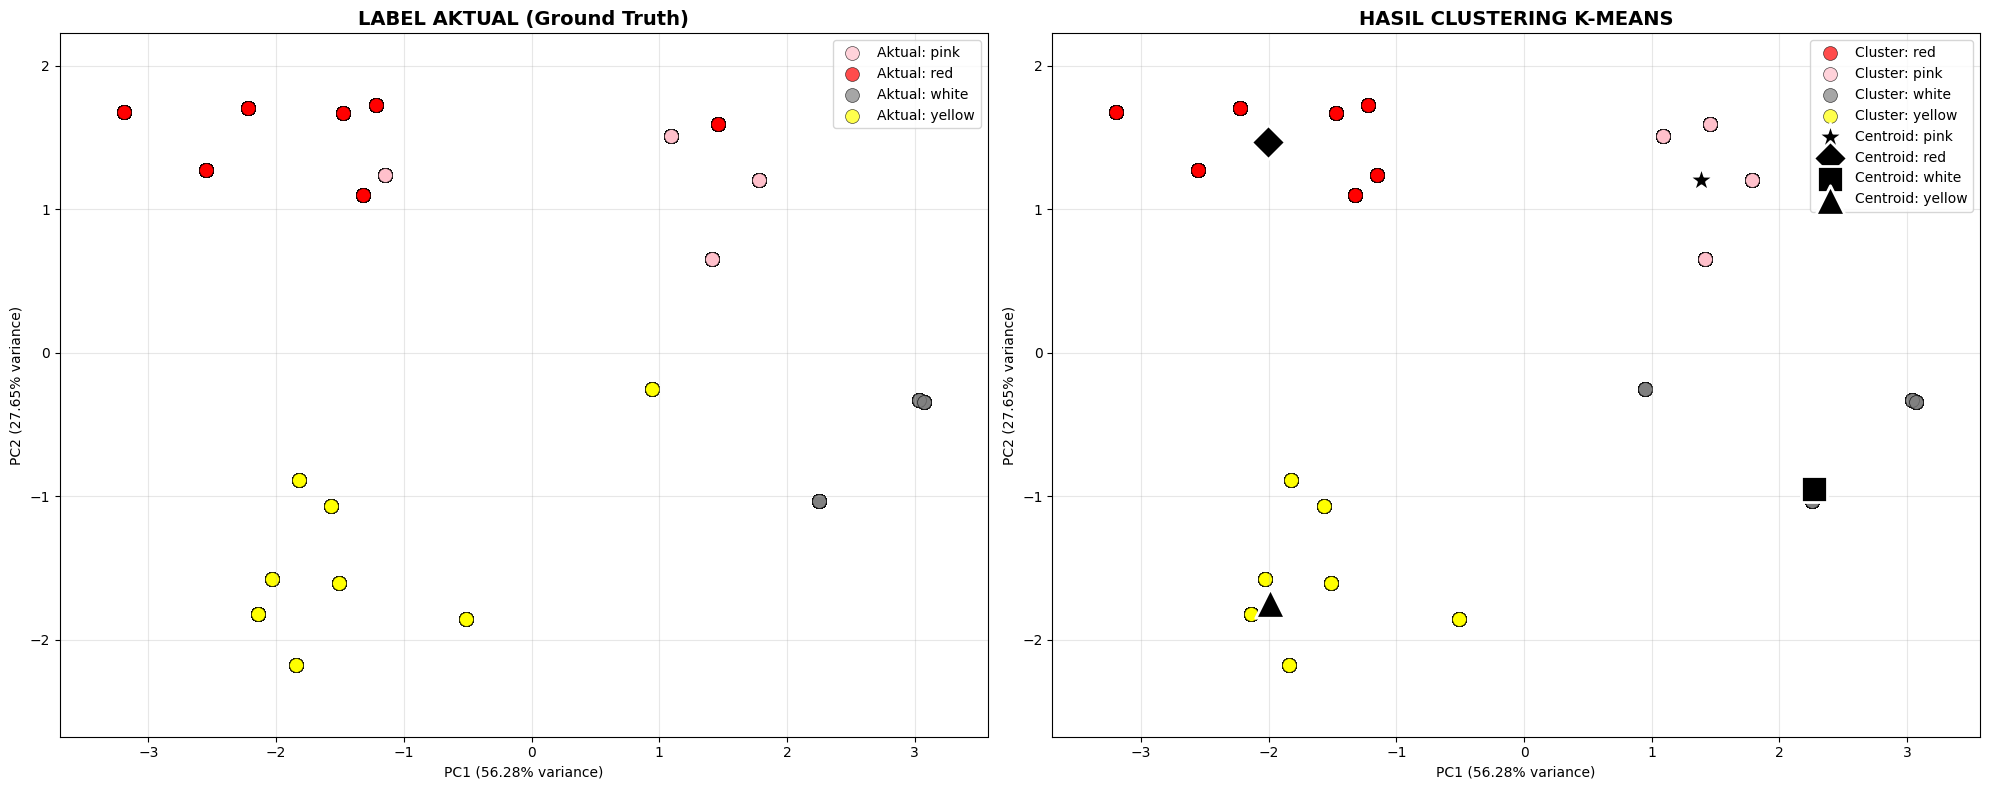


📊 Variance yang dijelaskan oleh PCA:
   PC1: 0.5628 (56.28%)
   PC2: 0.2765 (27.65%)
   Total: 0.8393 (83.93%)

15. MENYIMPAN HASIL CLUSTERING: C:/Users/Ahsan/Downloads/hasil_clustering_4kelas.xlsx
💾 Hasil clustering disimpan ke: C:/Users/Ahsan/Downloads/hasil_clustering_4kelas.xlsx

🎉 PROSES SELESAI UNTUK 4 KELAS MAWAR!

📊 RINGKASAN HASIL:
   - Total gambar diproses: 4400
   - Akurasi clustering: 93.91%
   - File output:
     * Data RGB: C:/Users/Ahsan/Downloads/data_ekstraksi_rgb_4kelas.xlsx
     * Data ECDF (CSV): C:/Users/Ahsan/Downloads/data_ecdf_rgb_4kelas.csv
     * Data ECDF Intensitas: C:/Users/Ahsan/Downloads/data_ecdf_intensitas_4kelas.xlsx
     * Data Konversi CDF: C:/Users/Ahsan/Downloads/data_ecdf_cdf_konversi_4kelas.xlsx
     * Hasil Clustering: C:/Users/Ahsan/Downloads/hasil_clustering_4kelas.xlsx


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =============================================
# KONFIGURASI - 4 FOLDER MAWAR
# =============================================
pink_rose_folder = "C:/Users/Ahsan/Downloads/data/pink_rose"
red_rose_folder = "C:/Users/Ahsan/Downloads/data/red_rose"  
white_rose_folder = "C:/Users/Ahsan/Downloads/data/white_rose"
yellow_rose_folder = "C:/Users/Ahsan/Downloads/data/yellow_rose"

output_excel = "C:/Users/Ahsan/Downloads/data_ekstraksi_rgb_4kelas.xlsx"
ecdf_output_csv = "C:/Users/Ahsan/Downloads/data_ecdf_rgb_4kelas.csv"  # Ganti ke CSV
ecdf_intensity_output_excel = "C:/Users/Ahsan/Downloads/data_ecdf_intensitas_4kelas.xlsx"
conversion_output_excel = "C:/Users/Ahsan/Downloads/data_ecdf_cdf_konversi_4kelas.xlsx"
clustering_output_excel = "C:/Users/Ahsan/Downloads/hasil_clustering_4kelas.xlsx"

p = 32  # Ukuran resize gambar: p x p

# =============================================
# FUNGSI UTAMA UNTUK MEMPROSES GAMBAR
# =============================================

def process_image(image_path, label, gambar_ke):
    """
    Memproses satu gambar: resize ke p x p, ekstrak RGB, dan simpan ke Excel
    """
    # Baca gambar
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Tidak bisa membaca gambar: {image_path}")
        return None
    
    # Resize gambar menjadi p x p
    img_resized = cv2.resize(img, (p, p))
    
    # Konversi BGR ke RGB
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
    # Ekstrak channel R, G, B
    R = img_rgb[:, :, 0].flatten()
    G = img_rgb[:, :, 1].flatten()
    B = img_rgb[:, :, 2].flatten()
    
    # Hitung statistik
    hasil = {
        'filename': os.path.basename(image_path),
        'gambar_ke': gambar_ke,
        'label': label,
        'p': p,
        'total_pixels': p * p,
        'R_values': R,
        'G_values': G,
        'B_values': B,
        'avg_R': np.mean(R),
        'avg_G': np.mean(G),
        'avg_B': np.mean(B),
        'min_R': np.min(R),
        'max_R': np.max(R),
        'min_G': np.min(G),
        'max_G': np.max(G),
        'min_B': np.min(B),
        'max_B': np.max(B)
    }
    
    return hasil

def process_all_images(folder_path, label):
    """
    Memproses semua gambar dalam folder
    """
    results = []
    
    if not os.path.exists(folder_path):
        print(f"❌ Folder tidak ditemukan: {folder_path}")
        return pd.DataFrame()
    
    image_files = [f for f in os.listdir(folder_path) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not image_files:
        print(f"❌ Tidak ada gambar ditemukan di: {folder_path}")
        return pd.DataFrame()
    
    print(f"📁 Memproses {len(image_files)} gambar dari {folder_path} (label: {label})")
    
    for i, image_file in enumerate(image_files):
        image_path = os.path.join(folder_path, image_file)
        
        result = process_image(image_path, label, i+1)
        if result is not None:
            results.append(result)
    
    # Konversi ke DataFrame
    if results:
        df = pd.DataFrame(results)
        print(f"✅ Berhasil memproses {len(df)} gambar dengan label: {label}")
        return df
    else:
        print(f"❌ Tidak ada hasil yang berhasil diproses dari {folder_path}")
        return pd.DataFrame()

def save_rgb_to_excel(df_rgb, output_path):
    """
    Menyimpan data RGB ke file Excel
    """
    # Buat DataFrame yang lebih sederhana untuk disimpan
    save_data = []
    for _, row in df_rgb.iterrows():
        save_data.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label': row['label'],
            'p': row['p'],
            'total_pixels': row['total_pixels'],
            'R_values': str(row['R_values'].tolist()),
            'G_values': str(row['G_values'].tolist()),
            'B_values': str(row['B_values'].tolist()),
            'avg_R': row['avg_R'],
            'avg_G': row['avg_G'],
            'avg_B': row['avg_B'],
            'min_R': row['min_R'],
            'max_R': row['max_R'],
            'min_G': row['min_G'],
            'max_G': row['max_G'],
            'min_B': row['min_B'],
            'max_B': row['max_B']
        })
    
    df_save = pd.DataFrame(save_data)
    df_save.to_excel(output_path, index=False)
    print(f"💾 Data RGB disimpan ke: {output_path}")

# =============================================
# FUNGSI ECDF - DIPERBAIKI
# =============================================

def calculate_ecdf(values):
    """
    Menghitung ECDF untuk suatu set nilai
    """
    if len(values) == 0:
        return np.array([]), np.array([])
    
    # Urutkan nilai
    sorted_values = np.sort(values)
    
    # Hitung ECDF
    n = len(sorted_values)
    ecdf = np.arange(1, n + 1) / n
    
    return sorted_values, ecdf

def calculate_ecdf_for_image(image_data):
    """
    Menghitung ECDF untuk sebuah gambar
    """
    filename = image_data['filename']
    j = image_data['gambar_ke']
    label = image_data['label']
    p_j = image_data['p']
    
    ecdf_data = {
        'filename': filename,
        'gambar_ke': j,
        'label': label,
        'p_j': p_j,
        'R': {'intensity': [], 'ecdf': []},
        'G': {'intensity': [], 'ecdf': []},
        'B': {'intensity': [], 'ecdf': []}
    }
    
    # Untuk setiap channel R, G, B
    for channel in ['R', 'G', 'B']:
        values = image_data[f'{channel}_values']
        
        if len(values) > 0:
            intensity, ecdf = calculate_ecdf(values)
            ecdf_data[channel]['intensity'] = intensity
            ecdf_data[channel]['ecdf'] = ecdf
    
    return ecdf_data

def calculate_all_ecdf(df_rgb):
    """
    Menghitung ECDF untuk semua gambar
    """
    ecdf_results = {}
    
    for _, row in df_rgb.iterrows():
        ecdf_data = calculate_ecdf_for_image(row)
        ecdf_results[row['filename']] = ecdf_data
    
    return ecdf_results

def save_ecdf_to_csv(ecdf_data, output_path):
    """
    Menyimpan data ECDF ke file CSV (bukan Excel) untuk handle data besar
    """
    save_data = []
    
    for filename, data in ecdf_data.items():
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            if len(channel_data['intensity']) > 0:
                for intensity, ecdf_val in zip(channel_data['intensity'], channel_data['ecdf']):
                    save_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'intensity': intensity,
                        'ecdf': ecdf_val,
                        'p_j': data['p_j']
                    })
    
    df_save = pd.DataFrame(save_data)
    
    # Simpan ke CSV bukan Excel
    df_save.to_csv(output_path, index=False)
    print(f"💾 Data ECDF disimpan ke: {output_path}")
    print(f"📊 Jumlah baris data ECDF: {len(df_save)}")

# =============================================
# FUNGSI MODEL MATEMATIS V DAN KONVERSI CDF
# =============================================

def create_mathematical_model_V(df_cdf):
    """
    Membuat model matematis V dari data CDF intensitas
    """
    model_V = {}
    
    # Channel R: intensitas 100, 150, 200
    for intensity in [100, 150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'R') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            model_V[f'R_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Channel G: intensitas 150, 200
    for intensity in [150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'G') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            model_V[f'G_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Channel B: intensitas 150, 200
    for intensity in [150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'B') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            model_V[f'B_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    print("✅ Model matematis V berhasil dibuat")
    print(f"🔧 Komponen model V: {list(model_V.keys())}")
    
    return model_V

def convert_ecdf_to_cdf_with_model_V(ecdf_value, model_key, model_V):
    """
    Mengkonversi nilai ECDF ke CDF menggunakan model matematis V
    """
    if model_key not in model_V:
        return None
    
    model_data = model_V[model_key]
    ecdf_values = model_data['ecdf_values']
    cdf_values = model_data['cdf_values']
    
    # Jika ECDF value di luar range model, return None
    if ecdf_value < ecdf_values[0] or ecdf_value > ecdf_values[-1]:
        return None
    
    # Cari posisi ECDF value dalam model
    idx = np.searchsorted(ecdf_values, ecdf_value, side='right') - 1
    
    # Return CDF value yang sesuai
    return cdf_values[idx]

def extract_and_convert_ecdf_data(ecdf_data, model_V):
    """
    Mengekstrak ECDF dari gambar pada intensitas tertentu dan mengkonversinya ke CDF menggunakan model V
    """
    conversion_results = []
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        # Ekstrak ECDF pada intensitas tertentu untuk semua channel
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Untuk setiap intensitas target
                for intensity in [100, 150, 200]:
                    # Tentukan model_key berdasarkan channel dan intensitas
                    model_key = f'{channel}_{intensity}'
                    
                    # Skip jika model_key tidak ada di model_V
                    if model_key not in model_V:
                        continue
                    
                    # Cari nilai ECDF pada intensitas target
                    ecdf_val = 0.0
                    for m in range(len(intensity_values)):
                        if intensity < intensity_values[0]:
                            ecdf_val = 0.0
                            break
                        elif intensity >= intensity_values[m]:
                            if m == len(intensity_values) - 1 or intensity < intensity_values[m + 1]:
                                ecdf_val = ecdf_values[m]
                                break
                        elif intensity >= intensity_values[-1]:
                            ecdf_val = 1.0
                            break
                    
                    # Konversi ECDF ke CDF menggunakan model V
                    cdf_val = convert_ecdf_to_cdf_with_model_V(ecdf_val, model_key, model_V)
                    
                    conversion_results.append({
                        'filename': filename,
                        'gambar_ke': j,
                        'label': label,
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val,
                        'cdf_value': cdf_val,
                        'model_key': model_key
                    })
    
    df_conversion = pd.DataFrame(conversion_results)
    return df_conversion

def save_conversion_data(ecdf_data, df_conversion, output_path):
    """
    Menyimpan data ECDF gambar dan CDF hasil konversi ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data konversi ECDF ke CDF (data kecil)
        df_conversion.to_excel(writer, sheet_name='Konversi_ECDF_ke_CDF', index=False)
        
        # Sheet 2: Ringkasan ECDF per gambar (data lebih kecil)
        summary_data = []
        for filename, data in ecdf_data.items():
            for channel in ['R', 'G', 'B']:
                channel_data = data[channel]
                if len(channel_data['intensity']) > 0:
                    summary_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'num_points': len(channel_data['intensity']),
                        'min_intensity': min(channel_data['intensity']),
                        'max_intensity': max(channel_data['intensity']),
                        'min_ecdf': min(channel_data['ecdf']),
                        'max_ecdf': max(channel_data['ecdf'])
                    })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Ringkasan_ECDF', index=False)
    
    print(f"💾 Data konversi CDF disimpan ke: {output_path}")

# =============================================
# FUNGSI EKSTRAKSI ECDF PADA INTENSITAS TERTENTU
# =============================================

def extract_ecdf_at_intensities(ecdf_data, intensities=[100, 150, 200]):
    """
    Mengekstrak nilai ECDF pada intensitas tertentu untuk setiap gambar dan channel
    """
    ecdf_intensity_data = []
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Untuk setiap intensitas target, cari nilai ECDF-nya
                for intensity in intensities:
                    ecdf_val = 0.0
                    
                    if intensity < intensity_values[0]:
                        ecdf_val = 0.0
                    elif intensity >= intensity_values[-1]:
                        ecdf_val = 1.0
                    else:
                        # Cari di segmen mana intensitas berada
                        for m in range(len(intensity_values) - 1):
                            if intensity_values[m] <= intensity < intensity_values[m + 1]:
                                ecdf_val = ecdf_values[m]
                                break
                        else:
                            # Jika tidak ditemukan dalam loop, gunakan nilai terakhir
                            ecdf_val = ecdf_values[-1] if intensity >= intensity_values[-1] else 0.0
                    
                    ecdf_intensity_data.append({
                        'filename': filename,
                        'gambar_ke': j,
                        'label': label,
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val
                    })
    
    df_ecdf_intensities = pd.DataFrame(ecdf_intensity_data)
    return df_ecdf_intensities

def calculate_cdf_for_ecdf_intensities(df_ecdf_intensities):
    """
    Menghitung CDF untuk nilai ECDF pada intensitas tertentu per channel
    """
    cdf_data = []
    
    for channel in ['R', 'G', 'B']:
        for intensity in [100, 150, 200]:
            # Ambil nilai ECDF untuk channel dan intensitas tertentu
            ecdf_values = df_ecdf_intensities[
                (df_ecdf_intensities['channel'] == channel) & 
                (df_ecdf_intensities['intensity_target'] == intensity)
            ]['ecdf_value'].values
            
            if len(ecdf_values) > 0:
                # Urutkan nilai ECDF
                sorted_ecdf = np.sort(ecdf_values)
                
                # Hitung CDF
                cdf_values = np.arange(1, len(sorted_ecdf) + 1) / len(sorted_ecdf)
                
                # Simpan data
                for ecdf_val, cdf_val in zip(sorted_ecdf, cdf_values):
                    cdf_data.append({
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val,
                        'cdf_value': cdf_val
                    })
    
    df_cdf = pd.DataFrame(cdf_data)
    return df_cdf

def save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, output_path):
    """
    Menyimpan data ECDF pada intensitas tertentu dan CDF-nya ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data ECDF pada intensitas tertentu
        df_ecdf_intensities.to_excel(writer, sheet_name='ECDF_Intensitas', index=False)
        
        # Sheet 2: Data CDF dari ECDF intensitas
        df_cdf.to_excel(writer, sheet_name='CDF_ECDF_Intensitas', index=False)
    
    print(f"💾 Data ECDF intensitas dan CDF disimpan ke: {output_path}")

# =============================================
# FUNGSI K-MEANS CLUSTERING DENGAN 4 CENTROID - DIPERBAIKI
# =============================================

def prepare_features_for_clustering(df_conversion):
    """
    Menyiapkan fitur untuk clustering dari data CDF hasil konversi
    """
    # Group by filename untuk mendapatkan semua fitur CDF per gambar
    features_data = []
    
    for filename in df_conversion['filename'].unique():
        file_data = df_conversion[df_conversion['filename'] == filename]
        
        # Ekstrak semua nilai CDF untuk gambar ini
        feature_vector = {}
        feature_vector['filename'] = filename
        feature_vector['gambar_ke'] = file_data['gambar_ke'].iloc[0]
        feature_vector['label'] = file_data['label'].iloc[0]
        
        # Untuk setiap kombinasi channel dan intensitas
        for _, row in file_data.iterrows():
            key = f"{row['channel']}_{row['intensity_target']}"
            feature_vector[key] = row['cdf_value']
        
        features_data.append(feature_vector)
    
    df_features = pd.DataFrame(features_data)
    
    # DEBUG: Tampilkan label yang unik dan jumlahnya
    print("\n🔍 DEBUG - Label unik di df_features:")
    print(df_features['label'].value_counts())
    
    # Fill NaN values dengan 0
    df_features = df_features.fillna(0)
    
    return df_features

def calculate_class_centroids(df_features):
    """
    Menghitung centroid untuk setiap kelas dengan mengambil rata-rata dari semua gambar dalam kelas tersebut
    """
    centroids = {}
    
    # DEBUG: Tampilkan semua label yang ada
    print(f"\n🔍 DEBUG - Semua label unik yang ada: {df_features['label'].unique()}")
    
    # Filter hanya kolom fitur (exclude metadata)
    feature_columns = [col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']]
    
    # Dapatkan label unik yang sebenarnya ada di data
    actual_labels = df_features['label'].unique()
    
    for label in actual_labels:
        class_data = df_features[df_features['label'] == label]
        if len(class_data) > 0:
            # Hitung rata-rata untuk setiap fitur
            centroid_values = class_data[feature_columns].mean(axis=0).values
            centroids[label] = centroid_values
            print(f"✅ Centroid untuk kelas '{label}': {len(class_data)} gambar")
        else:
            print(f"❌ Tidak ada gambar untuk kelas '{label}'")
    
    return centroids, feature_columns

def perform_kmeans_clustering_4centroids(df_features):
    """
    Melakukan K-means clustering dengan 4 centroid berdasarkan CDF hasil konversi
    Centroid diinisialisasi dengan rata-rata setiap kelas
    """
    print(f"\n🔍 Menyiapkan centroid dari rata-rata masing-masing kelas")
    
    # Filter hanya kolom fitur (exclude metadata)
    feature_columns = [col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']]
    
    # Pastikan semua fitur columns ada
    if len(feature_columns) == 0:
        print("❌ Tidak ada fitur yang ditemukan untuk clustering!")
        return None, None, None, []
    
    # Ekstrak matriks fitur
    X = df_features[feature_columns].values
    
    # Hitung centroid untuk setiap kelas
    centroids_dict, feature_columns = calculate_class_centroids(df_features)
    
    if len(centroids_dict) < 4:
        print(f"⚠️  Hanya {len(centroids_dict)} kelas yang memiliki centroid! Menggunakan centroid acak...")
        # Fallback: gunakan K-means dengan inisialisasi random
        kmeans = KMeans(n_clusters=4, random_state=42)
        labels = kmeans.fit_predict(X)
        centroids = kmeans.cluster_centers_
    else:
        # Siapkan initial centroids dari rata-rata kelas
        initial_centroids = np.array(list(centroids_dict.values()))
        
        print(f"📍 Shape initial centroids: {initial_centroids.shape}")
        print(f"🎯 Kelas yang digunakan: {list(centroids_dict.keys())}")
        
        # Lakukan K-means dengan inisialisasi centroid spesifik
        kmeans = KMeans(
            n_clusters=4,
            init=initial_centroids,
            n_init=1,  # Hanya gunakan inisialisasi yang diberikan
            max_iter=300,
            random_state=42
        )
        
        labels = kmeans.fit_predict(X)
        centroids = kmeans.cluster_centers_
        
        print("✅ K-means clustering dengan centroid berhasil!")
    
    # Tambahkan hasil clustering ke DataFrame
    df_features = df_features.copy()
    df_features['cluster'] = labels
    df_features['distance_to_centroid'] = kmeans.transform(X).min(axis=1)
    
    # Mapping cluster ke label berdasarkan centroid terdekat
    cluster_mapping = {}
    
    # Untuk setiap cluster, cari centroid kelas mana yang paling dekat
    for cluster_idx in range(len(centroids_dict)):
        if cluster_idx < len(centroids):  # Pastikan cluster_idx valid
            cluster_center = centroids[cluster_idx]
            
            # Hitung jarak ke setiap centroid kelas
            distances = {}
            for label, class_centroid in centroids_dict.items():
                distance = np.linalg.norm(cluster_center - class_centroid)
                distances[label] = distance
            
            # Pilih label dengan jarak terdekat
            if distances:  # Pastikan distances tidak kosong
                closest_label = min(distances, key=distances.get)
                cluster_mapping[cluster_idx] = closest_label
    
    print(f"🔀 Mapping cluster: {cluster_mapping}")
    
    df_features['cluster_label'] = df_features['cluster'].map(cluster_mapping)
    
    # Simpan informasi centroid yang digunakan
    centroid_info = []
    for cluster_idx, label in cluster_mapping.items():
        centroid_info.append({
            'cluster': cluster_idx,
            'cluster_label': label,
            'centroid_values': centroids[cluster_idx] if cluster_idx < len(centroids) else None
        })
    
    return df_features, kmeans, feature_columns, centroid_info

def analyze_clustering_results_4classes(df_features, df_conversion, centroid_info):
    """
    Menganalisis dan menampilkan hasil clustering untuk 4 kelas
    """
    print("\n" + "="*80)
    print("HASIL K-MEANS CLUSTERING")
    print("="*80)
    
    # Tampilkan informasi centroid
    print("\n🎯 INFORMASI CENTROID:")
    for i, centroid in enumerate(centroid_info):
        print(f"   Cluster {centroid['cluster']}: {centroid['cluster_label']}")
    
    # Hitung akurasi clustering
    correct_predictions = 0
    total_predictions = len(df_features)
    
    clustering_results = []
    
    for _, row in df_features.iterrows():
        actual_label = row['label']
        predicted_label = row['cluster_label']
        is_correct = (actual_label == predicted_label)
        
        if is_correct:
            correct_predictions += 1
        
        clustering_results.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label_aktual': actual_label,
            'cluster_prediksi': row['cluster'],
            'label_prediksi': predicted_label,
            'benar': is_correct,
            'jarak_ke_centroid': row['distance_to_centroid']
        })
    
    accuracy = correct_predictions / total_predictions * 100 if total_predictions > 0 else 0
    
    print(f"\n📈 AKURASI CLUSTERING: {accuracy:.2f}%")
    print(f"   Benar: {correct_predictions}/{total_predictions}")
    
    # Tampilkan confusion matrix sederhana
    print("\n📊 CONFUSION MATRIX:")
    df_results = pd.DataFrame(clustering_results)
    if not df_results.empty:
        confusion_matrix = pd.crosstab(df_results['label_aktual'], df_results['label_prediksi'])
        print(confusion_matrix)
    
    return df_results, accuracy

def plot_clustering_results_4classes(df_features, feature_columns, centroid_info):
    """
    Membuat visualisasi hasil clustering untuk 4 kelas
    """
    print("\n" + "="*80)
    print("VISUALISASI HASIL CLUSTERING")
    print("="*80)
    
    # Standardisasi fitur
    X = df_features[feature_columns].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Reduksi dimensi dengan PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Hitung batas yang sama untuk kedua plot
    x_min = min(X_pca[:, 0]) - 0.5
    x_max = max(X_pca[:, 0]) + 0.5
    y_min = min(X_pca[:, 1]) - 0.5
    y_max = max(X_pca[:, 1]) + 0.5
    
    # Buat plot dengan ukuran yang lebih besar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Warna untuk plot
    colors = {'pink': 'pink', 'red': 'red', 'white': 'gray', 'yellow': 'yellow'}
    
    # Plot 1: Label aktual
    actual_labels = df_features['label'].unique()
    for label in actual_labels:
        mask = df_features['label'] == label
        color = colors.get(label, 'blue')  # Default blue jika label tidak dikenali
        if mask.any():
            ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Aktual: {label}', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    ax1.set_title('LABEL AKTUAL (Ground Truth)', fontsize=14, fontweight='bold')
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    
    # Plot 2: Hasil clustering
    cluster_labels = df_features['cluster_label'].unique()
    for cluster_label in cluster_labels:
        mask = df_features['cluster_label'] == cluster_label
        color = colors.get(cluster_label, 'blue')  # Default blue jika label tidak dikenali
        if mask.any():
            ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Cluster: {cluster_label}', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Tandai centroid dengan spesial marker
    print(f"🎯 Menampilkan {len(centroid_info)} centroid di plot...")
    centroid_markers = ['*', 'D', 's', '^']  # Multiple marker types
    centroid_sizes = [400, 300, 350, 450]  # Different sizes
    
    # Plot centroid (gunakan PCA transform dari centroid asli)
    for idx, centroid in enumerate(centroid_info):
        if centroid['centroid_values'] is not None:
            # Transform centroid ke ruang PCA
            centroid_scaled = scaler.transform([centroid['centroid_values']])
            centroid_pca = pca.transform(centroid_scaled)[0]
            
            marker = centroid_markers[idx % len(centroid_markers)]
            size = centroid_sizes[idx % len(centroid_sizes)]
            
            ax2.scatter(centroid_pca[0], centroid_pca[1], 
                       c='black', marker=marker, s=size,
                       label=f"Centroid: {centroid['cluster_label']}",
                       edgecolors='white', linewidth=2, zorder=5)
            
            print(f"   ✅ Centroid {idx}: {centroid['cluster_label']} di posisi {centroid_pca}")
    
    ax2.set_title('HASIL CLUSTERING K-MEANS', fontsize=14, fontweight='bold')
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()
    
    # Print variance explained oleh PCA
    print(f"\n📊 Variance yang dijelaskan oleh PCA:")
    print(f"   PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]:.2%})")
    print(f"   PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]:.2%})")
    print(f"   Total: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_):.2%})")

def save_clustering_results(df_features, df_results, accuracy, output_path):
    """
    Menyimpan hasil clustering ke file Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Fitur dan hasil clustering
        df_features.to_excel(writer, sheet_name='Fitur_dan_Clustering', index=False)
        
        # Sheet 2: Ringkasan hasil
        df_results.to_excel(writer, sheet_name='Hasil_Clustering', index=False)
        
        # Sheet 3: Statistik clustering
        accuracy_data = [{
            'total_gambar': len(df_features),
            'benar': len(df_results[df_results['benar'] == True]),
            'salah': len(df_results[df_results['benar'] == False]),
            'akurasi': accuracy
        }]
        df_accuracy = pd.DataFrame(accuracy_data)
        df_accuracy.to_excel(writer, sheet_name='Statistik', index=False)
    
    print(f"💾 Hasil clustering disimpan ke: {output_path}")

# =============================================
# FUNGSI UTAMA UNTUK 4 KELAS - DIPERBAIKI
# =============================================

def main_4_classes():
    """
    Fungsi utama untuk memproses 4 kelas mawar (pink, red, white, yellow)
    """
    print("PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS INTENSITAS - 4 KELAS MAWAR")
    print("=" * 80)
    
    # 1. Proses gambar dari 4 folder
    print("\n1. PROSES GAMBAR DARI 4 FOLDER MAWAR")
    
    print(f"\n📁 Memproses folder: {pink_rose_folder}")
    df_pink = process_all_images(pink_rose_folder, "pink")
    
    print(f"\n📁 Memproses folder: {red_rose_folder}")
    df_red = process_all_images(red_rose_folder, "red")
    
    print(f"\n📁 Memproses folder: {white_rose_folder}")
    df_white = process_all_images(white_rose_folder, "white")
    
    print(f"\n📁 Memproses folder: {yellow_rose_folder}")
    df_yellow = process_all_images(yellow_rose_folder, "yellow")
    
    # 2. Gabungkan semua hasil
    all_dfs = [df_pink, df_red, df_white, df_yellow]
    all_dfs = [df for df in all_dfs if not df.empty]
    
    if not all_dfs:
        print("❌ Tidak ada data yang diproses. Periksa path folder dan file gambar.")
        return
    
    all_df_rgb = pd.concat(all_dfs, ignore_index=True)
    
    print(f"\n📊 Total gambar diproses: {len(all_df_rgb)}")
    print(f"  - Mawar pink: {len(df_pink)}")
    print(f"  - Mawar merah: {len(df_red)}")
    print(f"  - Mawar putih: {len(df_white)}")
    print(f"  - Mawar kuning: {len(df_yellow)}")
    
    # 3. Simpan data RGB ke Excel
    print(f"\n2. MENYIMPAN DATA RGB KE EXCEL: {output_excel}")
    save_rgb_to_excel(all_df_rgb, output_excel)
    
    # 4. Hitung ECDF untuk semua gambar
    print("\n3. MENGHITUNG ECDF UNTUK SEMUA GAMBAR")
    all_ecdf_results = calculate_all_ecdf(all_df_rgb)
    
    # 5. Simpan data ECDF ke CSV (bukan Excel karena data terlalu besar)
    print(f"\n4. MENYIMPAN DATA ECDF KE CSV: {ecdf_output_csv}")
    save_ecdf_to_csv(all_ecdf_results, ecdf_output_csv)
    
    # 6. Ekstrak nilai ECDF pada intensitas tertentu
    print("\n5. EKSTRAKSI NILAI ECDF PADA INTENSITAS 100, 150, 200")
    df_ecdf_intensities = extract_ecdf_at_intensities(all_ecdf_results)
    
    # 7. Hitung CDF untuk nilai ECDF pada intensitas tertentu
    print("\n6. MENGHITUNG CDF UNTUK NILAI ECDF PADA INTENSITAS TERTENTU")
    df_cdf = calculate_cdf_for_ecdf_intensities(df_ecdf_intensities)
    
    # 8. Simpan data ECDF intensitas dan CDF
    print(f"\n7. MENYIMPAN DATA ECDF INTENSITAS DAN CDF: {ecdf_intensity_output_excel}")
    save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, ecdf_intensity_output_excel)
    
    # =============================================
    # BAGIAN MODEL MATEMATIS V DAN KONVERSI CDF
    # =============================================
    
    # 9. Membuat model matematis V dari data CDF
    print("\n8. MEMBUAT MODEL MATEMATIS V DARI DATA CDF INTENSITAS")
    model_V = create_mathematical_model_V(df_cdf)
    
    # 10. Ekstrak ECDF dari gambar dan konversi ke CDF menggunakan model V
    print("\n9. EKSTRAKSI ECDF DARI GAMBAR DAN KONVERSI KE CDF MENGGUNAKAN MODEL V")
    df_conversion = extract_and_convert_ecdf_data(all_ecdf_results, model_V)
    
    # 11. Simpan data konversi CDF
    print(f"\n10. MENYIMPAN DATA KONVERSI CDF: {conversion_output_excel}")
    save_conversion_data(all_ecdf_results, df_conversion, conversion_output_excel)
    
    # =============================================
    # BAGIAN K-MEANS CLUSTERING DENGAN CENTROID
    # =============================================
    
    # 12. Persiapan fitur untuk clustering dari CDF hasil konversi
    print("\n11. PERSIAPAN FITUR UNTUK CLUSTERING DARI CDF HASIL KONVERSI")
    df_features = prepare_features_for_clustering(df_conversion)
    
    if df_features.empty:
        print("❌ Tidak ada fitur yang dapat dipersiapkan untuk clustering!")
        return
    
    print(f"   Jumlah gambar untuk clustering: {len(df_features)}")
    print(f"   Jumlah fitur per gambar: {len([col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']])}")
    
    # 13. Melakukan K-means clustering dengan centroid (rata-rata masing-masing kelas)
    print("\n12. MELAKUKAN K-MEANS CLUSTERING DENGAN CENTROID")
    df_features, kmeans, feature_columns, centroid_info = perform_kmeans_clustering_4centroids(df_features)
    
    if df_features is None:
        print("❌ Clustering gagal!")
        return
    
    # 14. Analisis hasil clustering
    print("\n13. ANALISIS HASIL CLUSTERING")
    df_results, accuracy = analyze_clustering_results_4classes(df_features, df_conversion, centroid_info)
    
    # 15. Visualisasi hasil clustering
    print("\n14. VISUALISASI HASIL CLUSTERING")
    plot_clustering_results_4classes(df_features, feature_columns, centroid_info)
    
    # 16. Simpan hasil clustering
    print(f"\n15. MENYIMPAN HASIL CLUSTERING: {clustering_output_excel}")
    save_clustering_results(df_features, df_results, accuracy, clustering_output_excel)
    
    print("\n" + "="*80)
    print("🎉 PROSES SELESAI UNTUK 4 KELAS MAWAR!")
    print("="*80)
    
    # Ringkasan akhir
    print("\n📊 RINGKASAN HASIL:")
    print(f"   - Total gambar diproses: {len(all_df_rgb)}")
    print(f"   - Akurasi clustering: {accuracy:.2f}%")
    print(f"   - File output:")
    print(f"     * Data RGB: {output_excel}")
    print(f"     * Data ECDF (CSV): {ecdf_output_csv}")
    print(f"     * Data ECDF Intensitas: {ecdf_intensity_output_excel}")
    print(f"     * Data Konversi CDF: {conversion_output_excel}")
    print(f"     * Hasil Clustering: {clustering_output_excel}")

if __name__ == "__main__":
    # Jalankan proses utama untuk 4 kelas
    main_4_classes()

ANALISIS ECDF DENGAN GARIS VERTIKAL INTENSITAS - 4 KELAS MAWAR

1. PROSES GAMBAR DARI 4 FOLDER MAWAR

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/pink_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/pink_rose (label: pink)
✅ Berhasil memproses 1100 gambar dengan label: pink

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/red_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/red_rose (label: red)
✅ Berhasil memproses 1100 gambar dengan label: red

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/white_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/white_rose (label: white)
✅ Berhasil memproses 1100 gambar dengan label: white

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/yellow_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/yellow_rose (label: yellow)
✅ Berhasil memproses 1100 gambar dengan label: yellow

📊 Total gambar diproses: 4400
  - Mawar pink: 1100
  - Mawar merah: 1100
  - Mawar putih: 1100
  - Mawar k

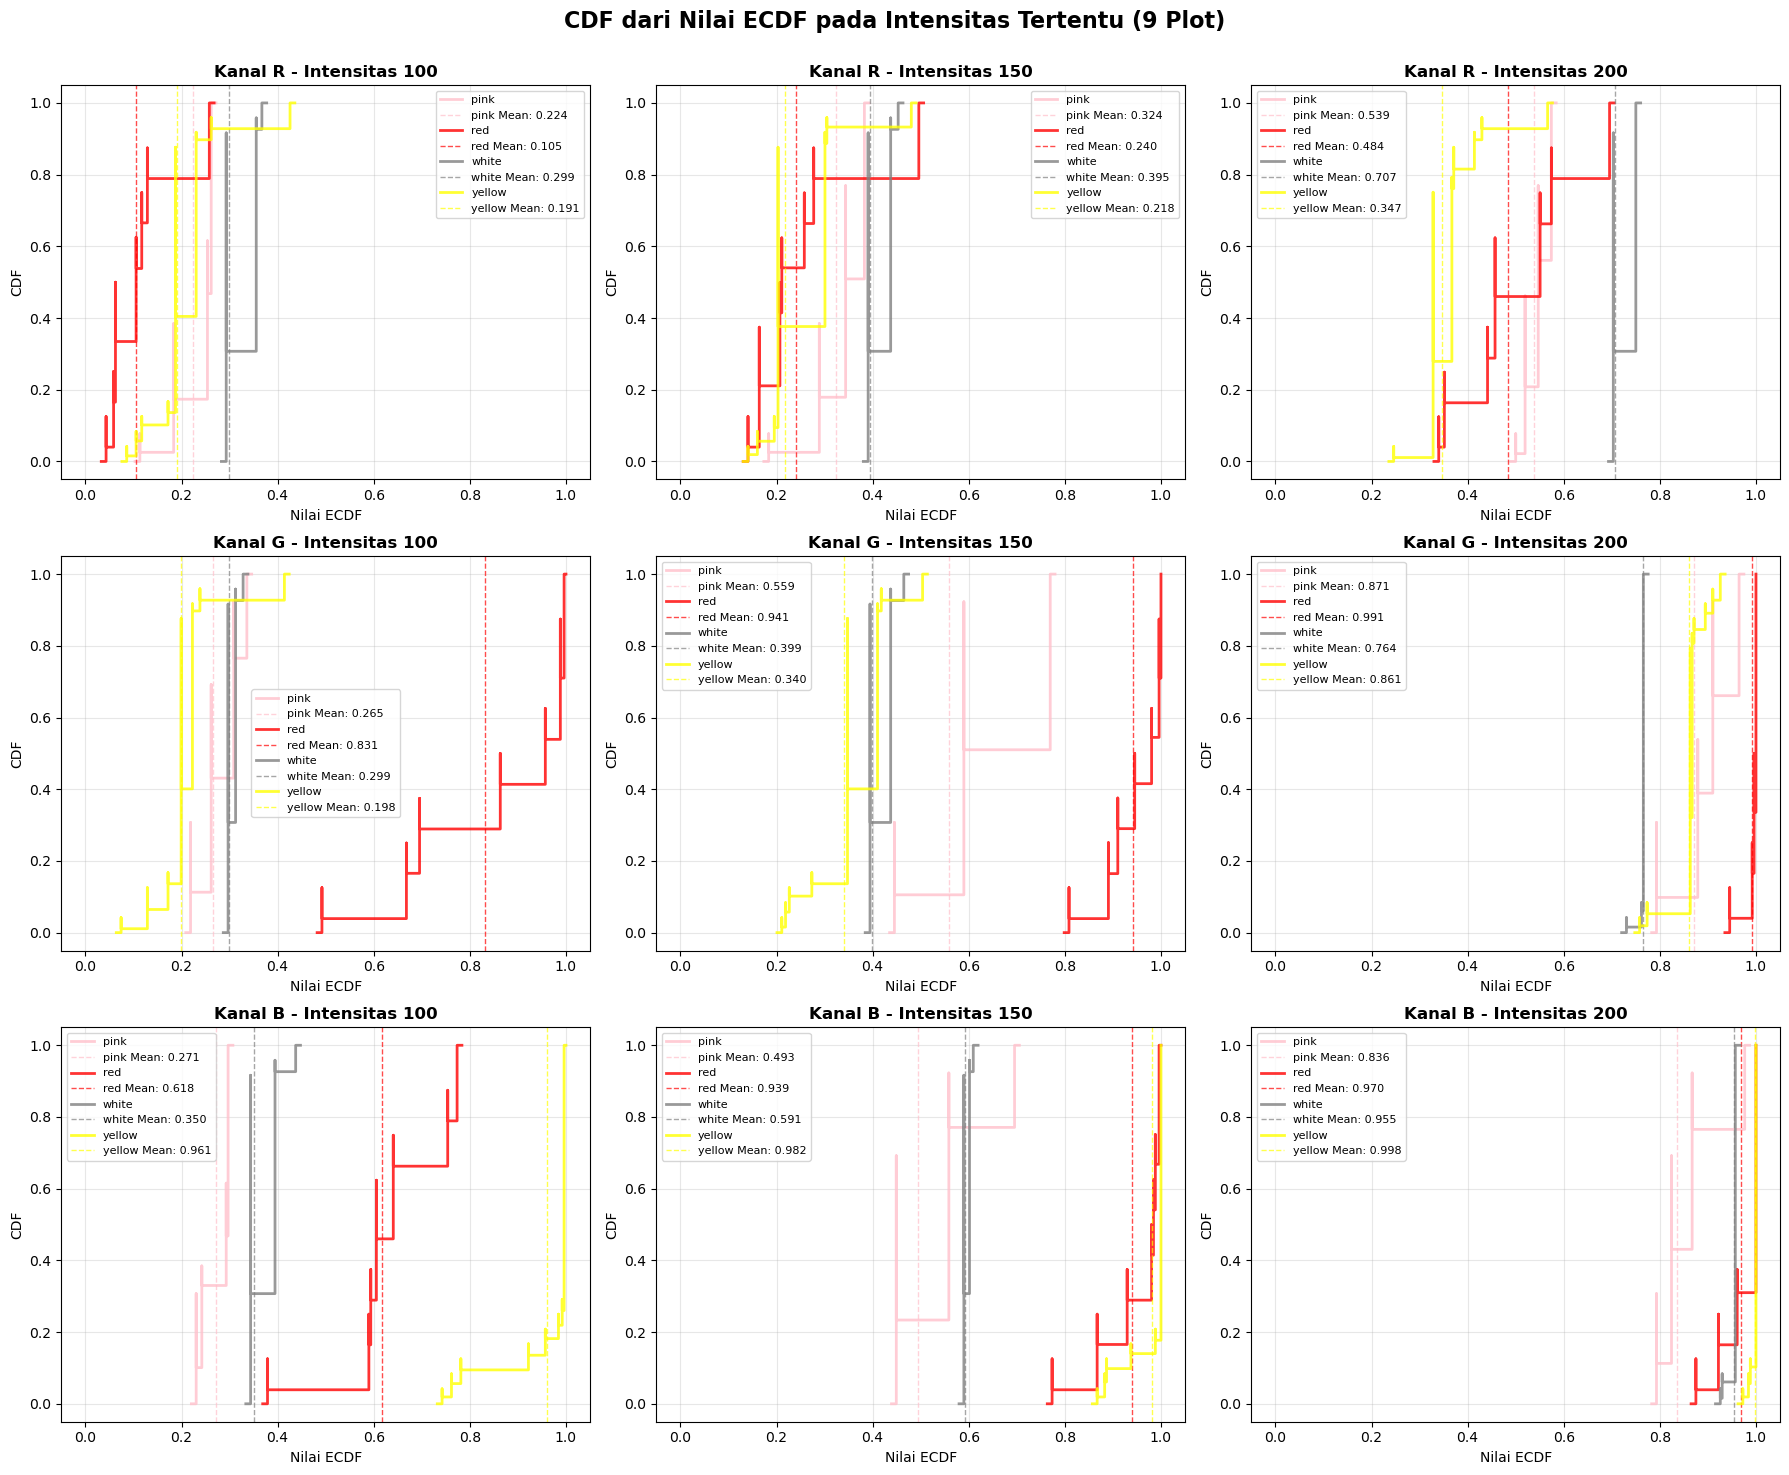

📊 Jumlah plot yang dibuat: 9
   - 3 channel: R, G, B
   - 3 intensitas: 100, 150, 200
   - Total: 3 × 3 = 9 plot

9. MEMBUAT PLOT PERBANDINGAN ECDF INTENSITAS - 9 PLOT

PLOT PERBANDINGAN ECDF PADA INTENSITAS TERTENTU - 9 PLOT


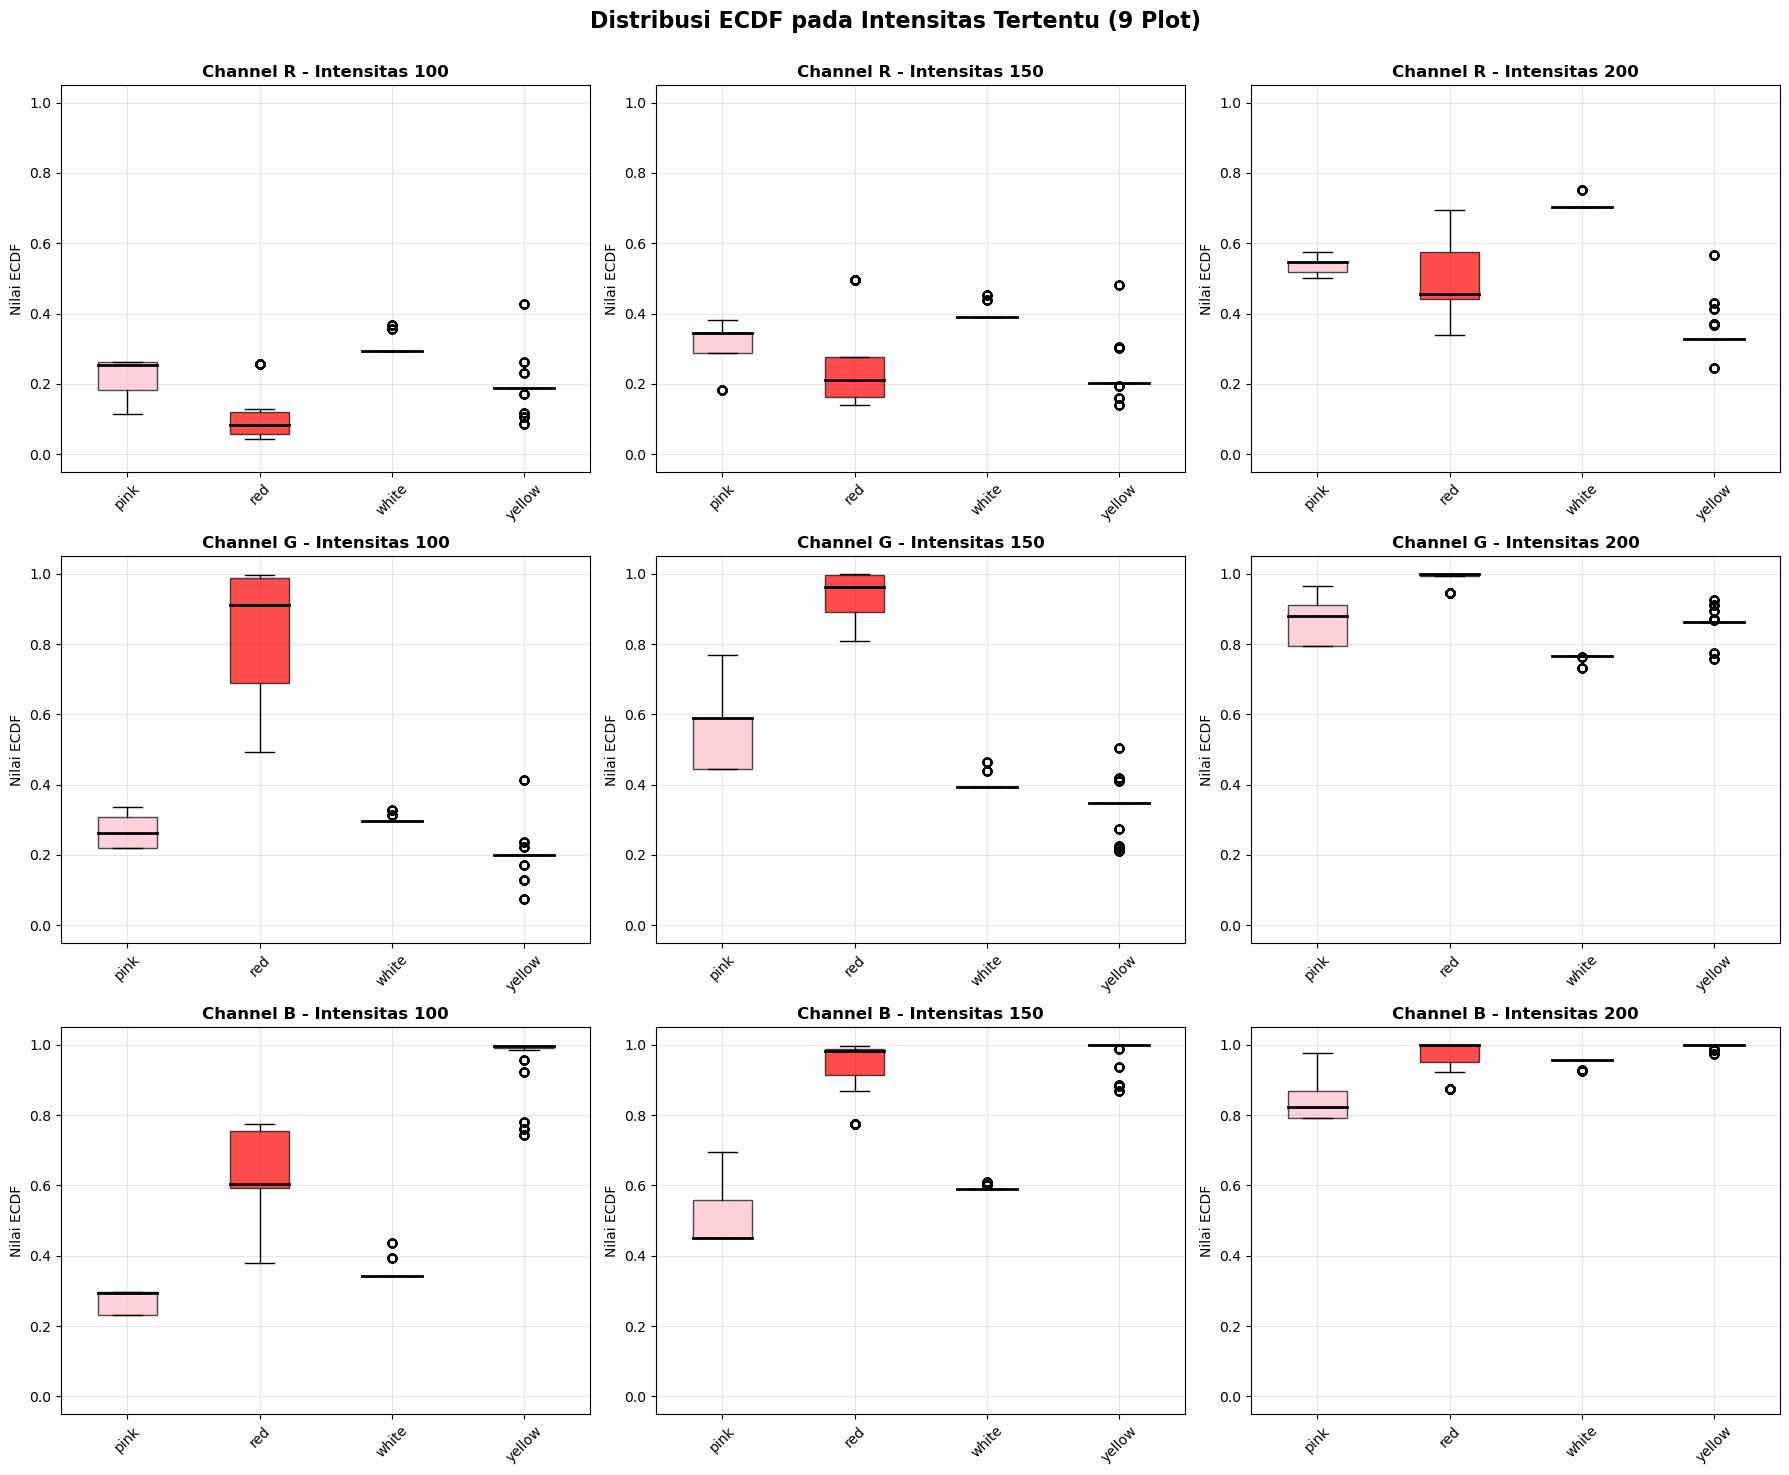


10. MEMBUAT PLOT STATISTIK RINGKASAN CDF INTENSITAS - 9 PLOT

PLOT STATISTIK RINGKASAN CDF INTENSITAS - 9 PLOT


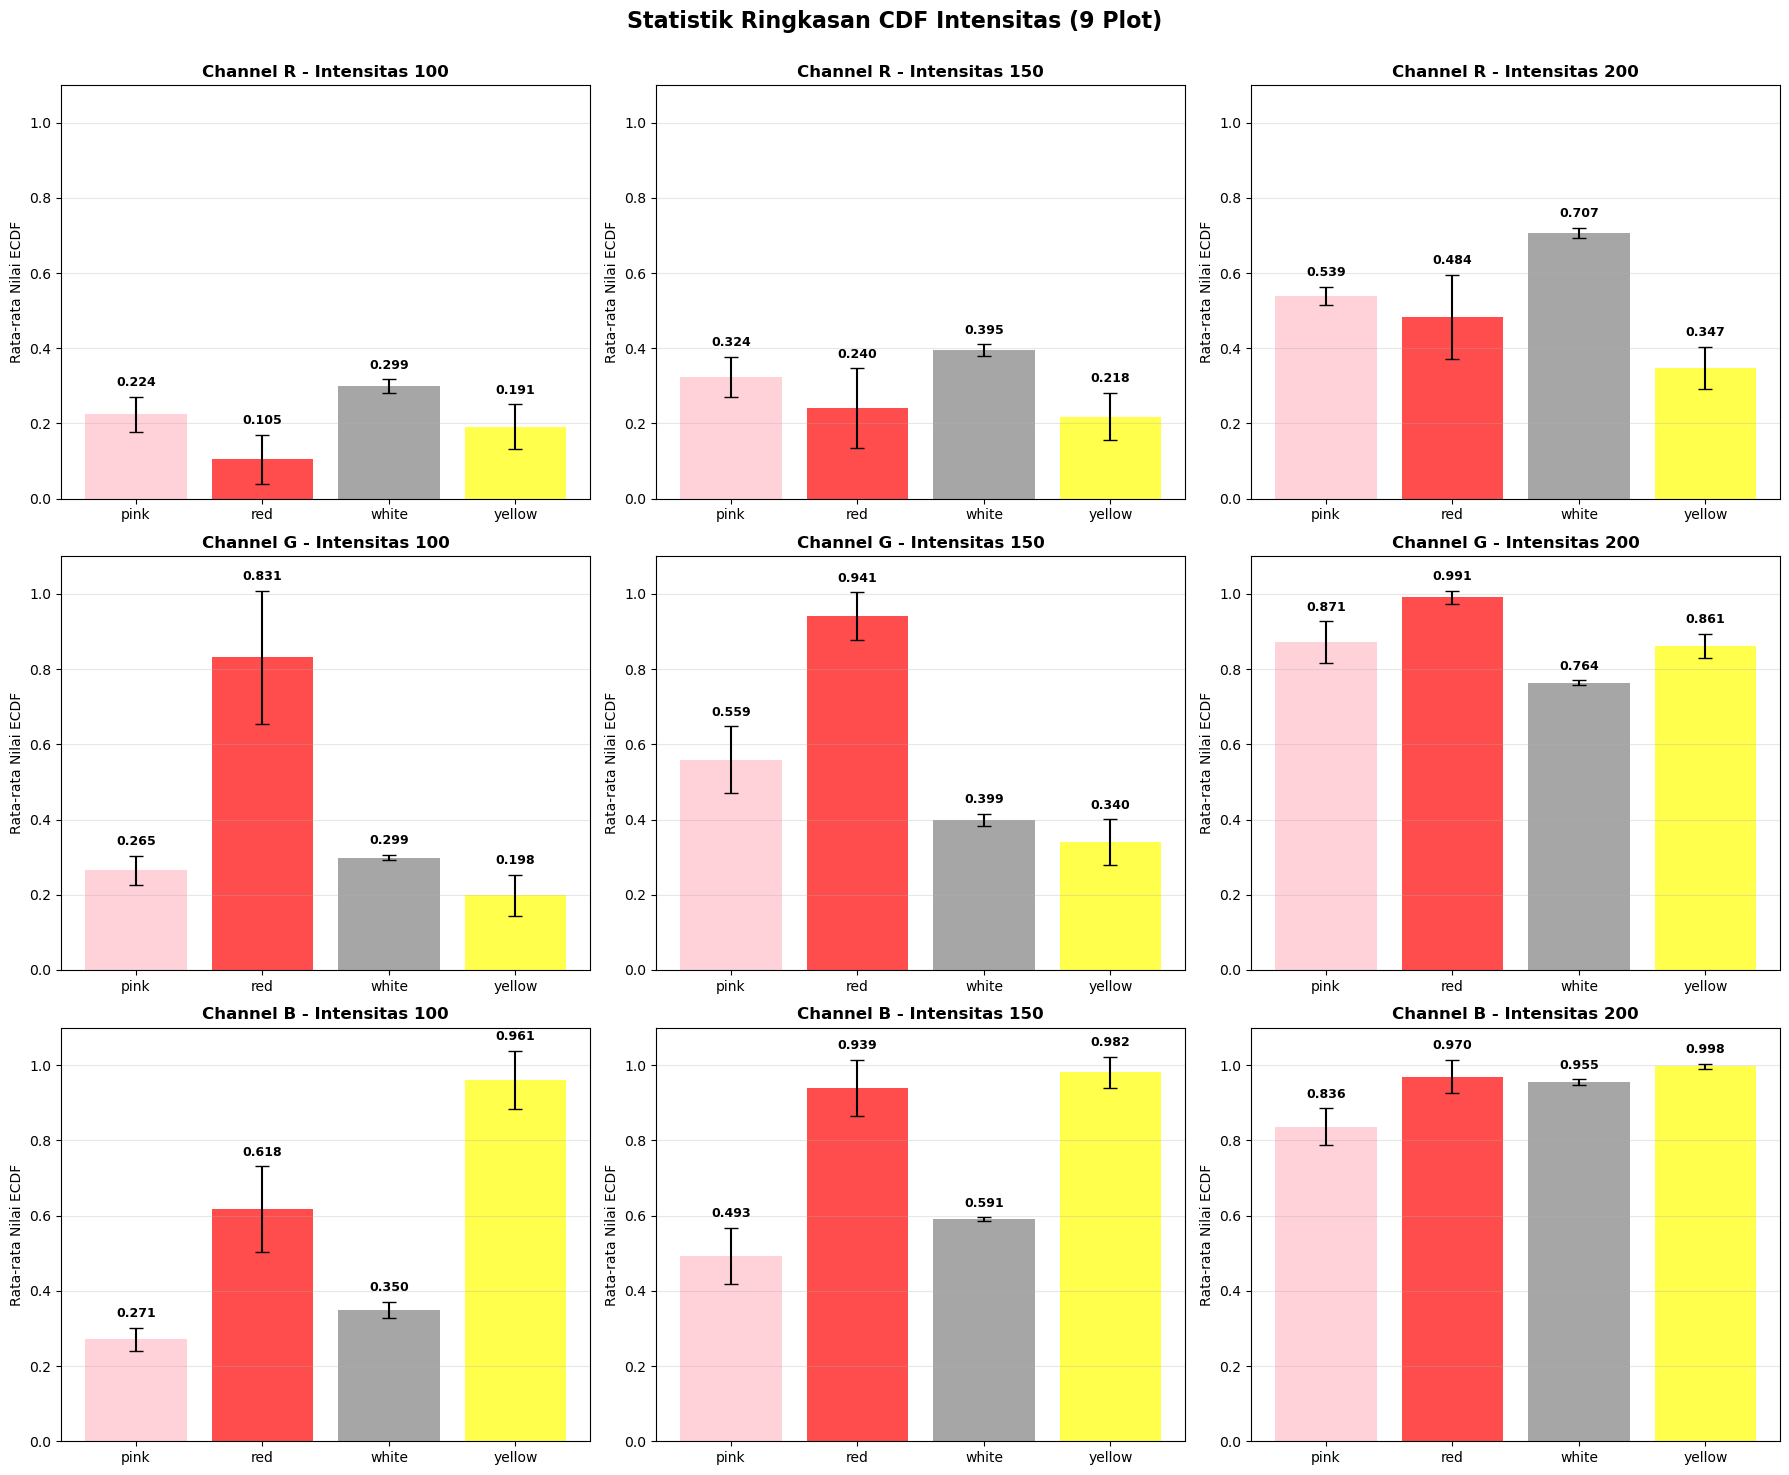


11. MEMBUAT PLOT ECDF STEP FUNCTION DENGAN GARIS VERTIKAL

PLOT ECDF STEP FUNCTION DENGAN GARIS VERTIKAL INTENSITAS


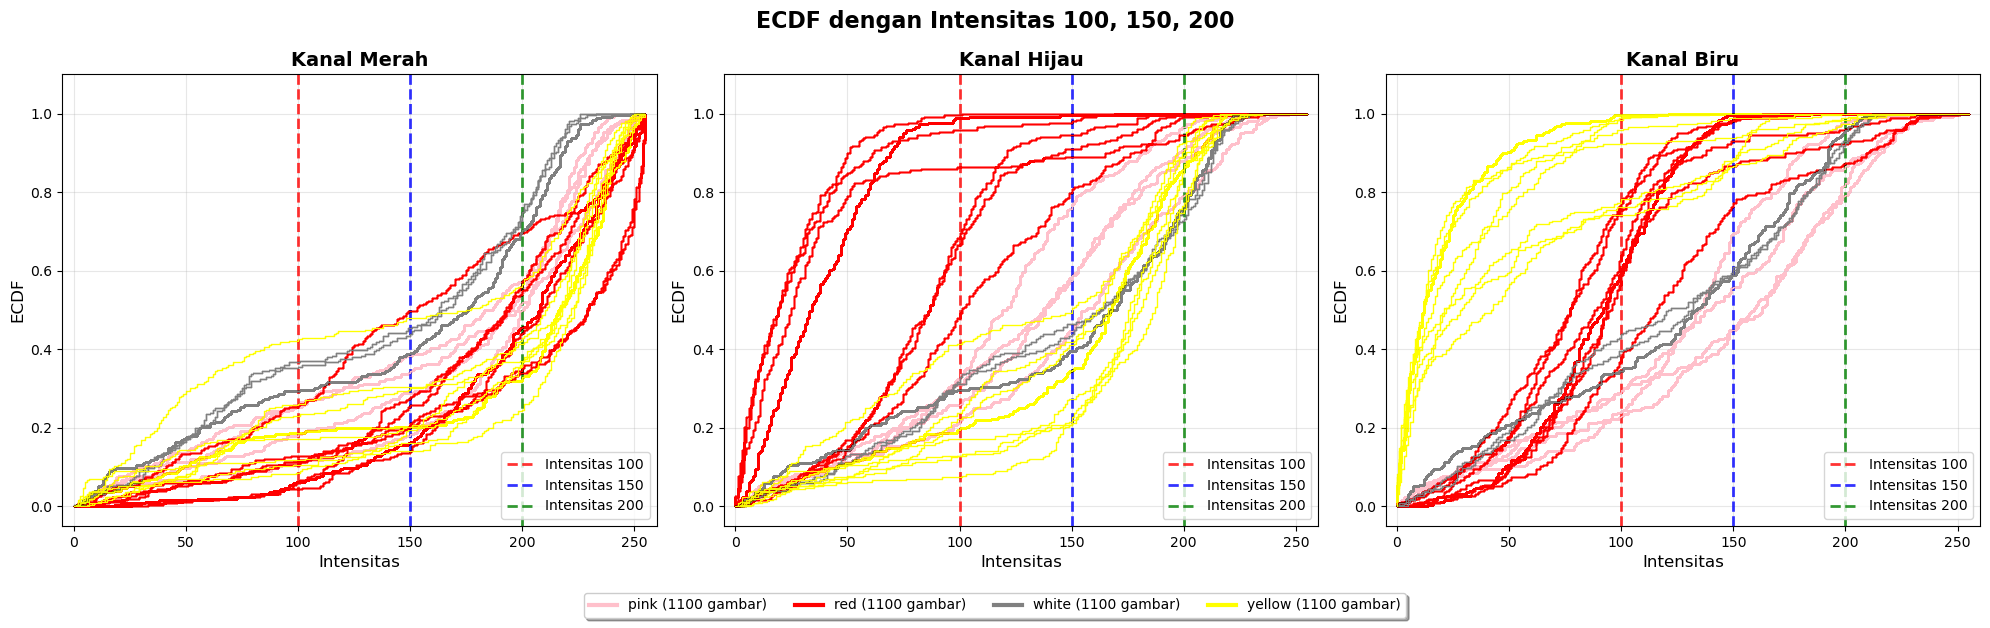

📊 Jumlah gambar yang diplot: 4400
   - pink: 1100 gambar
   - red: 1100 gambar
   - white: 1100 gambar
   - yellow: 1100 gambar
🎯 Garis vertikal pada intensitas: [100, 150, 200]

🎉 ANALISIS ECDF DENGAN GARIS VERTIKAL SELESAI!

📊 RINGKASAN HASIL:
   - Total gambar diproses: 4400
   - File output:
     * Data RGB: C:/Users/Ahsan/Downloads/data/data_ekstraksi_rgb_4kelas.xlsx
     * Data ECDF (CSV): C:/Users/Ahsan/Downloads/data/data_ecdf_rgb_4kelas.csv
     * Data ECDF Intensitas: C:/Users/Ahsan/Downloads/data/data_ecdf_intensitas_4kelas.xlsx
   - Plot yang dihasilkan:
     * CDF Intensitas Step Function (9 plot)
     * Perbandingan ECDF Intensitas (9 plot)
     * Statistik Ringkasan CDF Intensitas (9 plot)
     * ECDF Step Function dengan garis vertikal


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =============================================
# KONFIGURASI - 4 FOLDER MAWAR
# =============================================
pink_rose_folder = "C:/Users/Ahsan/Downloads/data/pink_rose"
red_rose_folder = "C:/Users/Ahsan/Downloads/data/red_rose"  
white_rose_folder = "C:/Users/Ahsan/Downloads/data/white_rose"
yellow_rose_folder = "C:/Users/Ahsan/Downloads/data/yellow_rose"

output_excel = "C:/Users/Ahsan/Downloads/data/data_ekstraksi_rgb_4kelas.xlsx"
ecdf_output_csv = "C:/Users/Ahsan/Downloads/data/data_ecdf_rgb_4kelas.csv"
ecdf_intensity_output_excel = "C:/Users/Ahsan/Downloads/data/data_ecdf_intensitas_4kelas.xlsx"

p = 16  # Ukuran resize gambar: p x p

# =============================================
# FUNGSI UTAMA UNTUK MEMPROSES GAMBAR
# =============================================

def process_image(image_path, label, gambar_ke):
    """
    Memproses satu gambar: resize ke p x p, ekstrak RGB, dan simpan ke Excel
    """
    # Baca gambar
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Tidak bisa membaca gambar: {image_path}")
        return None
    
    # Resize gambar menjadi p x p
    img_resized = cv2.resize(img, (p, p))
    
    # Konversi BGR ke RGB
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
    # Ekstrak channel R, G, B
    R = img_rgb[:, :, 0].flatten()
    G = img_rgb[:, :, 1].flatten()
    B = img_rgb[:, :, 2].flatten()
    
    # Hitung statistik
    hasil = {
        'filename': os.path.basename(image_path),
        'gambar_ke': gambar_ke,
        'label': label,
        'p': p,
        'total_pixels': p * p,
        'R_values': R,
        'G_values': G,
        'B_values': B,
        'avg_R': np.mean(R),
        'avg_G': np.mean(G),
        'avg_B': np.mean(B),
        'min_R': np.min(R),
        'max_R': np.max(R),
        'min_G': np.min(G),
        'max_G': np.max(G),
        'min_B': np.min(B),
        'max_B': np.max(B)
    }
    
    return hasil

def process_all_images(folder_path, label):
    """
    Memproses semua gambar dalam folder
    """
    results = []
    
    if not os.path.exists(folder_path):
        print(f"❌ Folder tidak ditemukan: {folder_path}")
        return pd.DataFrame()
    
    image_files = [f for f in os.listdir(folder_path) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not image_files:
        print(f"❌ Tidak ada gambar ditemukan di: {folder_path}")
        return pd.DataFrame()
    
    print(f"📁 Memproses {len(image_files)} gambar dari {folder_path} (label: {label})")
    
    for i, image_file in enumerate(image_files):
        image_path = os.path.join(folder_path, image_file)
        
        result = process_image(image_path, label, i+1)
        if result is not None:
            results.append(result)
    
    # Konversi ke DataFrame
    if results:
        df = pd.DataFrame(results)
        print(f"✅ Berhasil memproses {len(df)} gambar dengan label: {label}")
        return df
    else:
        print(f"❌ Tidak ada hasil yang berhasil diproses dari {folder_path}")
        return pd.DataFrame()

def save_rgb_to_excel(df_rgb, output_path):
    """
    Menyimpan data RGB ke file Excel
    """
    # Buat DataFrame yang lebih sederhana untuk disimpan
    save_data = []
    for _, row in df_rgb.iterrows():
        save_data.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label': row['label'],
            'p': row['p'],
            'total_pixels': row['total_pixels'],
            'R_values': str(row['R_values'].tolist()),
            'G_values': str(row['G_values'].tolist()),
            'B_values': str(row['B_values'].tolist()),
            'avg_R': row['avg_R'],
            'avg_G': row['avg_G'],
            'avg_B': row['avg_B'],
            'min_R': row['min_R'],
            'max_R': row['max_R'],
            'min_G': row['min_G'],
            'max_G': row['max_G'],
            'min_B': row['min_B'],
            'max_B': row['max_B']
        })
    
    df_save = pd.DataFrame(save_data)
    df_save.to_excel(output_path, index=False)
    print(f"💾 Data RGB disimpan ke: {output_path}")

# =============================================
# FUNGSI ECDF
# =============================================

def calculate_ecdf(values):
    """
    Menghitung ECDF untuk suatu set nilai
    """
    if len(values) == 0:
        return np.array([]), np.array([])
    
    # Urutkan nilai
    sorted_values = np.sort(values)
    
    # Hitung ECDF
    n = len(sorted_values)
    ecdf = np.arange(1, n + 1) / n
    
    return sorted_values, ecdf

def calculate_ecdf_for_image(image_data):
    """
    Menghitung ECDF untuk sebuah gambar
    """
    filename = image_data['filename']
    j = image_data['gambar_ke']
    label = image_data['label']
    p_j = image_data['p']
    
    ecdf_data = {
        'filename': filename,
        'gambar_ke': j,
        'label': label,
        'p_j': p_j,
        'R': {'intensity': [], 'ecdf': []},
        'G': {'intensity': [], 'ecdf': []},
        'B': {'intensity': [], 'ecdf': []}
    }
    
    # Untuk setiap channel R, G, B
    for channel in ['R', 'G', 'B']:
        values = image_data[f'{channel}_values']
        
        if len(values) > 0:
            intensity, ecdf = calculate_ecdf(values)
            ecdf_data[channel]['intensity'] = intensity
            ecdf_data[channel]['ecdf'] = ecdf
    
    return ecdf_data

def calculate_all_ecdf(df_rgb):
    """
    Menghitung ECDF untuk semua gambar
    """
    ecdf_results = {}
    
    for _, row in df_rgb.iterrows():
        ecdf_data = calculate_ecdf_for_image(row)
        ecdf_results[row['filename']] = ecdf_data
    
    return ecdf_results

def save_ecdf_to_csv(ecdf_data, output_path):
    """
    Menyimpan data ECDF ke file CSV (bukan Excel) untuk handle data besar
    """
    save_data = []
    
    for filename, data in ecdf_data.items():
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            if len(channel_data['intensity']) > 0:
                for intensity, ecdf_val in zip(channel_data['intensity'], channel_data['ecdf']):
                    save_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'intensity': intensity,
                        'ecdf': ecdf_val,
                        'p_j': data['p_j']
                    })
    
    df_save = pd.DataFrame(save_data)
    
    # Simpan ke CSV bukan Excel
    df_save.to_csv(output_path, index=False)
    print(f"💾 Data ECDF disimpan ke: {output_path}")
    print(f"📊 Jumlah baris data ECDF: {len(df_save)}")

# =============================================
# FUNGSI EKSTRAKSI ECDF PADA INTENSITAS TERTENTU - DIPERBAIKI
# =============================================

def extract_ecdf_at_intensities(ecdf_data, intensities=[100, 150, 200]):
    """
    Mengekstrak nilai ECDF pada intensitas tertentu untuk setiap gambar dan channel
    """
    ecdf_intensity_data = []
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Untuk setiap intensitas target, cari nilai ECDF-nya
                for intensity in intensities:
                    ecdf_val = 0.0
                    
                    if intensity < intensity_values[0]:
                        ecdf_val = 0.0
                    elif intensity >= intensity_values[-1]:
                        ecdf_val = 1.0
                    else:
                        # Cari di segmen mana intensitas berada
                        for m in range(len(intensity_values) - 1):
                            if intensity_values[m] <= intensity < intensity_values[m + 1]:
                                ecdf_val = ecdf_values[m]
                                break
                        else:
                            # Jika tidak ditemukan dalam loop, gunakan nilai terakhir
                            ecdf_val = ecdf_values[-1] if intensity >= intensity_values[-1] else 0.0
                    
                    ecdf_intensity_data.append({
                        'filename': filename,
                        'gambar_ke': j,
                        'label': label,
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val
                    })
    
    df_ecdf_intensities = pd.DataFrame(ecdf_intensity_data)
    return df_ecdf_intensities

def calculate_cdf_for_ecdf_intensities(df_ecdf_intensities):
    """
    Menghitung CDF untuk nilai ECDF pada intensitas tertentu per channel DAN LABEL
    """
    cdf_data = []
    
    # Dapatkan semua kombinasi unik dari channel, intensity_target, dan label
    unique_combinations = df_ecdf_intensities[['channel', 'intensity_target', 'label']].drop_duplicates()
    
    for _, combo in unique_combinations.iterrows():
        channel = combo['channel']
        intensity = combo['intensity_target']
        label = combo['label']
        
        # Ambil nilai ECDF untuk channel, intensitas, dan label tertentu
        ecdf_values = df_ecdf_intensities[
            (df_ecdf_intensities['channel'] == channel) & 
            (df_ecdf_intensities['intensity_target'] == intensity) &
            (df_ecdf_intensities['label'] == label)
        ]['ecdf_value'].values
        
        if len(ecdf_values) > 0:
            # Urutkan nilai ECDF
            sorted_ecdf = np.sort(ecdf_values)
            
            # Hitung CDF
            cdf_values = np.arange(1, len(sorted_ecdf) + 1) / len(sorted_ecdf)
            
            # Simpan data
            for ecdf_val, cdf_val in zip(sorted_ecdf, cdf_values):
                cdf_data.append({
                    'channel': channel,
                    'intensity_target': intensity,
                    'label': label,
                    'ecdf_value': ecdf_val,
                    'cdf_value': cdf_val
                })
    
    df_cdf = pd.DataFrame(cdf_data)
    return df_cdf

def save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, output_path):
    """
    Menyimpan data ECDF pada intensitas tertentu dan CDF-nya ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data ECDF pada intensitas tertentu
        df_ecdf_intensities.to_excel(writer, sheet_name='ECDF_Intensitas', index=False)
        
        # Sheet 2: Data CDF dari ECDF intensitas
        df_cdf.to_excel(writer, sheet_name='CDF_ECDF_Intensitas', index=False)
    
    print(f"💾 Data ECDF intensitas dan CDF disimpan ke: {output_path}")

# =============================================
# FUNGSI PLOT CDF INTENSITAS YANG DIPERBAIKI - 9 PLOT
# =============================================

def plot_cdf_intensities_step_function_9plots(df_cdf):
    """
    Plot CDF dari nilai ECDF intensitas dalam bentuk step function - 9 PLOT
    Membuat 9 plot untuk semua kombinasi channel (R, G, B) dan intensitas (100, 150, 200)
    """
    print("\n" + "="*80)
    print("PLOT CDF INTENSITAS (STEP FUNCTION) - 9 PLOT")
    print("="*80)
    
    # Warna untuk setiap label
    colors = {'pink': 'pink', 'red': 'red', 'white': 'gray', 'yellow': 'yellow'}
    
    # Buat 9 plot (3x3 grid)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('CDF dari Nilai ECDF pada Intensitas Tertentu (9 Plot)', 
                fontsize=16, fontweight='bold')
    
    # Konfigurasi plot: semua kombinasi channel dan intensitas
    channels = ['R', 'G', 'B']
    intensities = [100, 150, 200]
    
    for i, channel in enumerate(channels):
        for j, intensity in enumerate(intensities):
            ax = axes[i, j]
            
            # Filter data untuk channel dan intensitas tertentu
            channel_data = df_cdf[
                (df_cdf['channel'] == channel) & 
                (df_cdf['intensity_target'] == intensity)
            ]
            
            # Untuk setiap label dalam data ini
            labels_in_data = channel_data['label'].unique()
            
            for label in labels_in_data:
                label_data = channel_data[channel_data['label'] == label]
                
                if not label_data.empty:
                    # Urutkan data berdasarkan ecdf_value
                    sorted_data = label_data.sort_values('ecdf_value')
                    ecdf_values = sorted_data['ecdf_value'].values
                    cdf_values = sorted_data['cdf_value'].values
                    
                    # Buat step function untuk CDF
                    x_step = []
                    y_step = []
                    
                    # Titik awal: (min(ecdf_values) atau 0, 0)
                    x_step.append(max(0, ecdf_values[0] - 0.01))
                    y_step.append(0)
                    
                    # Untuk setiap titik data, buat step
                    for k in range(len(cdf_values)):
                        # Sebelum lompatan
                        x_step.append(ecdf_values[k])
                        y_step.append(cdf_values[k-1] if k > 0 else 0)
                        
                        # Setelah lompatan
                        x_step.append(ecdf_values[k])
                        y_step.append(cdf_values[k])
                    
                    # Titik akhir: (max(ecdf_values) atau 1.0, 1.0)
                    x_step.append(min(1.0, ecdf_values[-1] + 0.01))
                    y_step.append(1.0)
                    
                    # Plot step function
                    ax.plot(x_step, y_step, color=colors[label], linewidth=2, alpha=0.8, label=label)
                    
                    # Hitung dan tampilkan statistik
                    mean_ecdf = np.mean(ecdf_values)
                    std_ecdf = np.std(ecdf_values)
                    
                    # Tambahkan garis vertikal di mean
                    ax.axvline(mean_ecdf, color=colors[label], linestyle='--', alpha=0.7, 
                              linewidth=1, label=f'{label} Mean: {mean_ecdf:.3f}')
            
            ax.set_title(f'Kanal {channel} - Intensitas {intensity}', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Nilai ECDF', fontsize=10)
            ax.set_ylabel('CDF', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)
            ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()
    
    print(f"📊 Jumlah plot yang dibuat: 9")
    print(f"   - 3 channel: R, G, B")
    print(f"   - 3 intensitas: 100, 150, 200")
    print(f"   - Total: 3 × 3 = 9 plot")

def plot_ecdf_intensities_comparison_9plots(df_ecdf_intensities):
    """
    Plot perbandingan ECDF pada intensitas tertentu untuk semua label - 9 PLOT
    """
    print("\n" + "="*80)
    print("PLOT PERBANDINGAN ECDF PADA INTENSITAS TERTENTU - 9 PLOT")
    print("="*80)
    
    # Warna untuk setiap label
    colors = {'pink': 'pink', 'red': 'red', 'white': 'gray', 'yellow': 'yellow'}
    
    # Buat 9 plot (3x3 grid)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('Distribusi ECDF pada Intensitas Tertentu (9 Plot)', 
                fontsize=16, fontweight='bold')
    
    channels = ['R', 'G', 'B']
    intensities = [100, 150, 200]
    
    for i, channel in enumerate(channels):
        for j, intensity in enumerate(intensities):
            ax = axes[i, j]
            
            # Filter data untuk channel dan intensitas tertentu
            channel_data = df_ecdf_intensities[
                (df_ecdf_intensities['channel'] == channel) & 
                (df_ecdf_intensities['intensity_target'] == intensity)
            ]
            
            # Buat boxplot untuk setiap label
            boxplot_data = []
            boxplot_labels = []
            
            for label in colors.keys():
                label_data = channel_data[channel_data['label'] == label]['ecdf_value']
                if len(label_data) > 0:
                    boxplot_data.append(label_data.values)
                    boxplot_labels.append(label)
            
            if boxplot_data:
                boxplots = ax.boxplot(boxplot_data, labels=boxplot_labels, patch_artist=True)
                
                # Beri warna pada boxplot
                for patch, label in zip(boxplots['boxes'], boxplot_labels):
                    patch.set_facecolor(colors[label])
                    patch.set_alpha(0.7)
                
                # Atur warna median line
                for median in boxplots['medians']:
                    median.set_color('black')
                    median.set_linewidth(2)
            
            ax.set_title(f'Channel {channel} - Intensitas {intensity}', 
                        fontsize=12, fontweight='bold')
            ax.set_ylabel('Nilai ECDF', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)
            
            # Rotasi label x-axis jika perlu
            plt.setp(ax.get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

def plot_cdf_intensities_statistical_summary(df_cdf):
    """
    Plot statistik ringkasan CDF intensitas - 9 PLOT
    """
    print("\n" + "="*80)
    print("PLOT STATISTIK RINGKASAN CDF INTENSITAS - 9 PLOT")
    print("="*80)
    
    # Warna untuk setiap label
    colors = {'pink': 'pink', 'red': 'red', 'white': 'gray', 'yellow': 'yellow'}
    
    # Buat 9 plot (3x3 grid)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('Statistik Ringkasan CDF Intensitas (9 Plot)', 
                fontsize=16, fontweight='bold')
    
    channels = ['R', 'G', 'B']
    intensities = [100, 150, 200]
    
    for i, channel in enumerate(channels):
        for j, intensity in enumerate(intensities):
            ax = axes[i, j]
            
            # Filter data untuk channel dan intensitas tertentu
            channel_data = df_cdf[
                (df_cdf['channel'] == channel) & 
                (df_cdf['intensity_target'] == intensity)
            ]
            
            # Untuk setiap label, hitung mean dan std dari ecdf_value
            stats_data = []
            
            for label in colors.keys():
                label_data = channel_data[channel_data['label'] == label]
                if not label_data.empty:
                    ecdf_values = label_data['ecdf_value'].values
                    mean_val = np.mean(ecdf_values)
                    std_val = np.std(ecdf_values)
                    stats_data.append({
                        'label': label,
                        'mean': mean_val,
                        'std': std_val
                    })
            
            # Buat bar plot untuk mean dengan error bars
            if stats_data:
                labels = [item['label'] for item in stats_data]
                means = [item['mean'] for item in stats_data]
                stds = [item['std'] for item in stats_data]
                
                x_pos = np.arange(len(labels))
                bars = ax.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, 
                             color=[colors[label] for label in labels])
                
                ax.set_xticks(x_pos)
                ax.set_xticklabels(labels)
                ax.set_ylabel('Rata-rata Nilai ECDF', fontsize=10)
                ax.grid(True, alpha=0.3, axis='y')
                
                # Tambahkan nilai di atas bar
                for idx, (mean, std) in enumerate(zip(means, stds)):
                    ax.text(idx, mean + std + 0.02, f'{mean:.3f}', 
                           ha='center', va='bottom', fontsize=9, fontweight='bold')
            
            ax.set_title(f'Channel {channel} - Intensitas {intensity}', 
                        fontsize=12, fontweight='bold')
            ax.set_ylim(0, 1.1)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

# =============================================
# FUNGSI PLOT ECDF STEP FUNCTION DENGAN GARIS VERTIKAL
# =============================================

def plot_ecdf_step_function_with_vertical_lines(ecdf_data, intensities=[100, 150, 200]):
    """
    Plot ECDF step function dengan garis vertikal penanda intensitas
    """
    print("\n" + "="*80)
    print("PLOT ECDF STEP FUNCTION DENGAN GARIS VERTIKAL INTENSITAS")
    print("="*80)
    
    # Warna untuk setiap label
    colors = {'pink': 'pink', 'red': 'red', 'white': 'gray', 'yellow': 'yellow'}
    
    # Warna untuk garis vertikal intensitas
    intensity_colors = {100: 'red', 150: 'blue', 200: 'green'}
    
    # Buat plot untuk setiap channel
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('ECDF dengan Intensitas 100, 150, 200', 
                fontsize=16, fontweight='bold')
    
    channel_names = {'R': 'Merah', 'G': 'Hijau', 'B': 'Biru'}
    
    # Hitung jumlah gambar per label untuk legend
    label_counts = {}
    for data in ecdf_data.values():
        label = data['label']
        label_counts[label] = label_counts.get(label, 0) + 1
    
    for idx, channel in enumerate(['R', 'G', 'B']):
        ax = axes[idx]
        
        # Tambahkan garis vertikal untuk intensitas tertentu
        for intensity in intensities:
            ax.axvline(x=intensity, color=intensity_colors[intensity], 
                      linestyle='--', alpha=0.8, linewidth=2,
                      label=f'Intensitas {intensity}')
        
        # Plot setiap gambar sebagai step function ringan
        for filename, data in ecdf_data.items():
            label = data['label']
            color = colors.get(label, 'blue')
            channel_data = data[channel]
            
            if len(channel_data['intensity']) > 0:
                intensity = channel_data['intensity']
                ecdf = channel_data['ecdf']
                
                # Buat arrays untuk step function
                x_step = []
                y_step = []
                
                # Titik awal: (0, 0)
                x_step.append(0)
                y_step.append(0)
                
                # Untuk setiap titik data, buat step
                for k in range(len(intensity)):
                    # Sebelum lompatan
                    x_step.append(intensity[k])
                    y_step.append(ecdf[k-1] if k > 0 else 0)
                    
                    # Setelah lompatan
                    x_step.append(intensity[k])
                    y_step.append(ecdf[k])
                
                # Titik akhir: (255, 1.0)
                if len(intensity) > 0:
                    x_step.append(255)
                    y_step.append(1.0)
                
                # Plot step function tanpa titik, hanya garis
                ax.plot(x_step, y_step, color=color, alpha=0.1, linewidth=0.8)
        
        ax.set_title(f'Kanal {channel_names[channel]}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Intensitas', fontsize=12)
        ax.set_ylabel('ECDF', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-5, 260)
        ax.set_ylim(-0.05, 1.1)
        
        # Tambahkan legend untuk garis vertikal
        ax.legend(loc='lower right')
    
    # Buat legend untuk label dengan informasi jumlah gambar
    legend_elements = []
    for label, color in colors.items():
        count = label_counts.get(label, 0)
        legend_elements.append(plt.Line2D([0], [0], color=color, lw=3, 
                                         label=f'{label} ({count} gambar)'))
    
    fig.legend(handles=legend_elements, 
              loc='upper center', 
              bbox_to_anchor=(0.5, 0.02),
              ncol=4, 
              fontsize=10,
              frameon=True,
              fancybox=True,
              shadow=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    plt.show()
    
    print(f"📊 Jumlah gambar yang diplot: {len(ecdf_data)}")
    for label, count in label_counts.items():
        print(f"   - {label}: {count} gambar")
    print(f"🎯 Garis vertikal pada intensitas: {intensities}")

# =============================================
# FUNGSI UTAMA YANG DIPERBAIKI - 9 PLOT
# =============================================

def main_ecdf_with_vertical_lines():
    """
    Fungsi utama untuk analisis ECDF dengan garis vertikal intensitas
    """
    print("ANALISIS ECDF DENGAN GARIS VERTIKAL INTENSITAS - 4 KELAS MAWAR")
    print("=" * 80)
    
    # 1. Proses gambar dari 4 folder
    print("\n1. PROSES GAMBAR DARI 4 FOLDER MAWAR")
    
    print(f"\n📁 Memproses folder: {pink_rose_folder}")
    df_pink = process_all_images(pink_rose_folder, "pink")
    
    print(f"\n📁 Memproses folder: {red_rose_folder}")
    df_red = process_all_images(red_rose_folder, "red")
    
    print(f"\n📁 Memproses folder: {white_rose_folder}")
    df_white = process_all_images(white_rose_folder, "white")
    
    print(f"\n📁 Memproses folder: {yellow_rose_folder}")
    df_yellow = process_all_images(yellow_rose_folder, "yellow")
    
    # 2. Gabungkan semua hasil
    all_dfs = [df_pink, df_red, df_white, df_yellow]
    all_dfs = [df for df in all_dfs if not df.empty]
    
    if not all_dfs:
        print("❌ Tidak ada data yang diproses. Periksa path folder dan file gambar.")
        return
    
    all_df_rgb = pd.concat(all_dfs, ignore_index=True)
    
    print(f"\n📊 Total gambar diproses: {len(all_df_rgb)}")
    print(f"  - Mawar pink: {len(df_pink)}")
    print(f"  - Mawar merah: {len(df_red)}")
    print(f"  - Mawar putih: {len(df_white)}")
    print(f"  - Mawar kuning: {len(df_yellow)}")
    
    # 3. Simpan data RGB ke Excel
    print(f"\n2. MENYIMPAN DATA RGB KE EXCEL: {output_excel}")
    save_rgb_to_excel(all_df_rgb, output_excel)
    
    # 4. Hitung ECDF untuk semua gambar
    print("\n3. MENGHITUNG ECDF UNTUK SEMUA GAMBAR")
    all_ecdf_results = calculate_all_ecdf(all_df_rgb)
    
    # 5. Simpan data ECDF ke CSV
    print(f"\n4. MENYIMPAN DATA ECDF KE CSV: {ecdf_output_csv}")
    save_ecdf_to_csv(all_ecdf_results, ecdf_output_csv)
    
    # 6. Ekstrak nilai ECDF pada intensitas tertentu
    print("\n5. EKSTRAKSI NILAI ECDF PADA INTENSITAS 100, 150, 200")
    df_ecdf_intensities = extract_ecdf_at_intensities(all_ecdf_results)
    
    # 7. Hitung CDF untuk nilai ECDF pada intensitas tertentu - DIPERBAIKI
    print("\n6. MENGHITUNG CDF UNTUK NILAI ECDF PADA INTENSITAS TERTENTU (DIPERBAIKI)")
    df_cdf = calculate_cdf_for_ecdf_intensities(df_ecdf_intensities)
    
    # 8. Simpan data ECDF intensitas dan CDF
    print(f"\n7. MENYIMPAN DATA ECDF INTENSITAS DAN CDF: {ecdf_intensity_output_excel}")
    save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, ecdf_intensity_output_excel)
    
    # =============================================
    # PLOT YANG DIPERBAIKI - 9 PLOT
    # =============================================
    
    # 9. Plot CDF intensitas step function - 9 PLOT
    print("\n8. MEMBUAT PLOT CDF INTENSITAS STEP FUNCTION - 9 PLOT")
    plot_cdf_intensities_step_function_9plots(df_cdf)
    
    # 10. Plot perbandingan ECDF intensitas - 9 PLOT
    print("\n9. MEMBUAT PLOT PERBANDINGAN ECDF INTENSITAS - 9 PLOT")
    plot_ecdf_intensities_comparison_9plots(df_ecdf_intensities)
    
    # 11. Plot statistik ringkasan CDF intensitas - 9 PLOT
    print("\n10. MEMBUAT PLOT STATISTIK RINGKASAN CDF INTENSITAS - 9 PLOT")
    plot_cdf_intensities_statistical_summary(df_cdf)
    
    # 12. Plot ECDF step function dengan garis vertikal
    print("\n11. MEMBUAT PLOT ECDF STEP FUNCTION DENGAN GARIS VERTIKAL")
    plot_ecdf_step_function_with_vertical_lines(all_ecdf_results)
    
    print("\n" + "="*80)
    print("🎉 ANALISIS ECDF DENGAN GARIS VERTIKAL SELESAI!")
    print("="*80)
    
    # Ringkasan akhir
    print("\n📊 RINGKASAN HASIL:")
    print(f"   - Total gambar diproses: {len(all_df_rgb)}")
    print(f"   - File output:")
    print(f"     * Data RGB: {output_excel}")
    print(f"     * Data ECDF (CSV): {ecdf_output_csv}")
    print(f"     * Data ECDF Intensitas: {ecdf_intensity_output_excel}")
    print(f"   - Plot yang dihasilkan:")
    print(f"     * CDF Intensitas Step Function (9 plot)")
    print(f"     * Perbandingan ECDF Intensitas (9 plot)")
    print(f"     * Statistik Ringkasan CDF Intensitas (9 plot)")
    print(f"     * ECDF Step Function dengan garis vertikal")

if __name__ == "__main__":
    # Jalankan analisis ECDF dengan garis vertikal
    main_ecdf_with_vertical_lines()

ANALISIS ECDF DENGAN GARIS VERTIKAL INTENSITAS - 4 KELAS MAWAR

1. PROSES GAMBAR DARI 4 FOLDER MAWAR

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/pink_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/pink_rose (label: pink)
✅ Berhasil memproses 1100 gambar dengan label: pink

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/red_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/red_rose (label: red)
✅ Berhasil memproses 1100 gambar dengan label: red

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/white_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/white_rose (label: white)
✅ Berhasil memproses 1100 gambar dengan label: white

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/yellow_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/yellow_rose (label: yellow)
✅ Berhasil memproses 1100 gambar dengan label: yellow

📊 Total gambar diproses: 4400
  - Mawar pink: 1100
  - Mawar merah: 1100
  - Mawar putih: 1100
  - Mawar k

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

💾 Data ECDF intensitas dan CDF disimpan ke: C:/Users/Ahsan/Downloads/data/data_ecdf_intensitas_4kelas.xlsx

8. MEMBUAT PLOT CDF INTENSITAS STEP FUNCTION - 9 PLOT (DIPERBAIKI)

PLOT CDF INTENSITAS


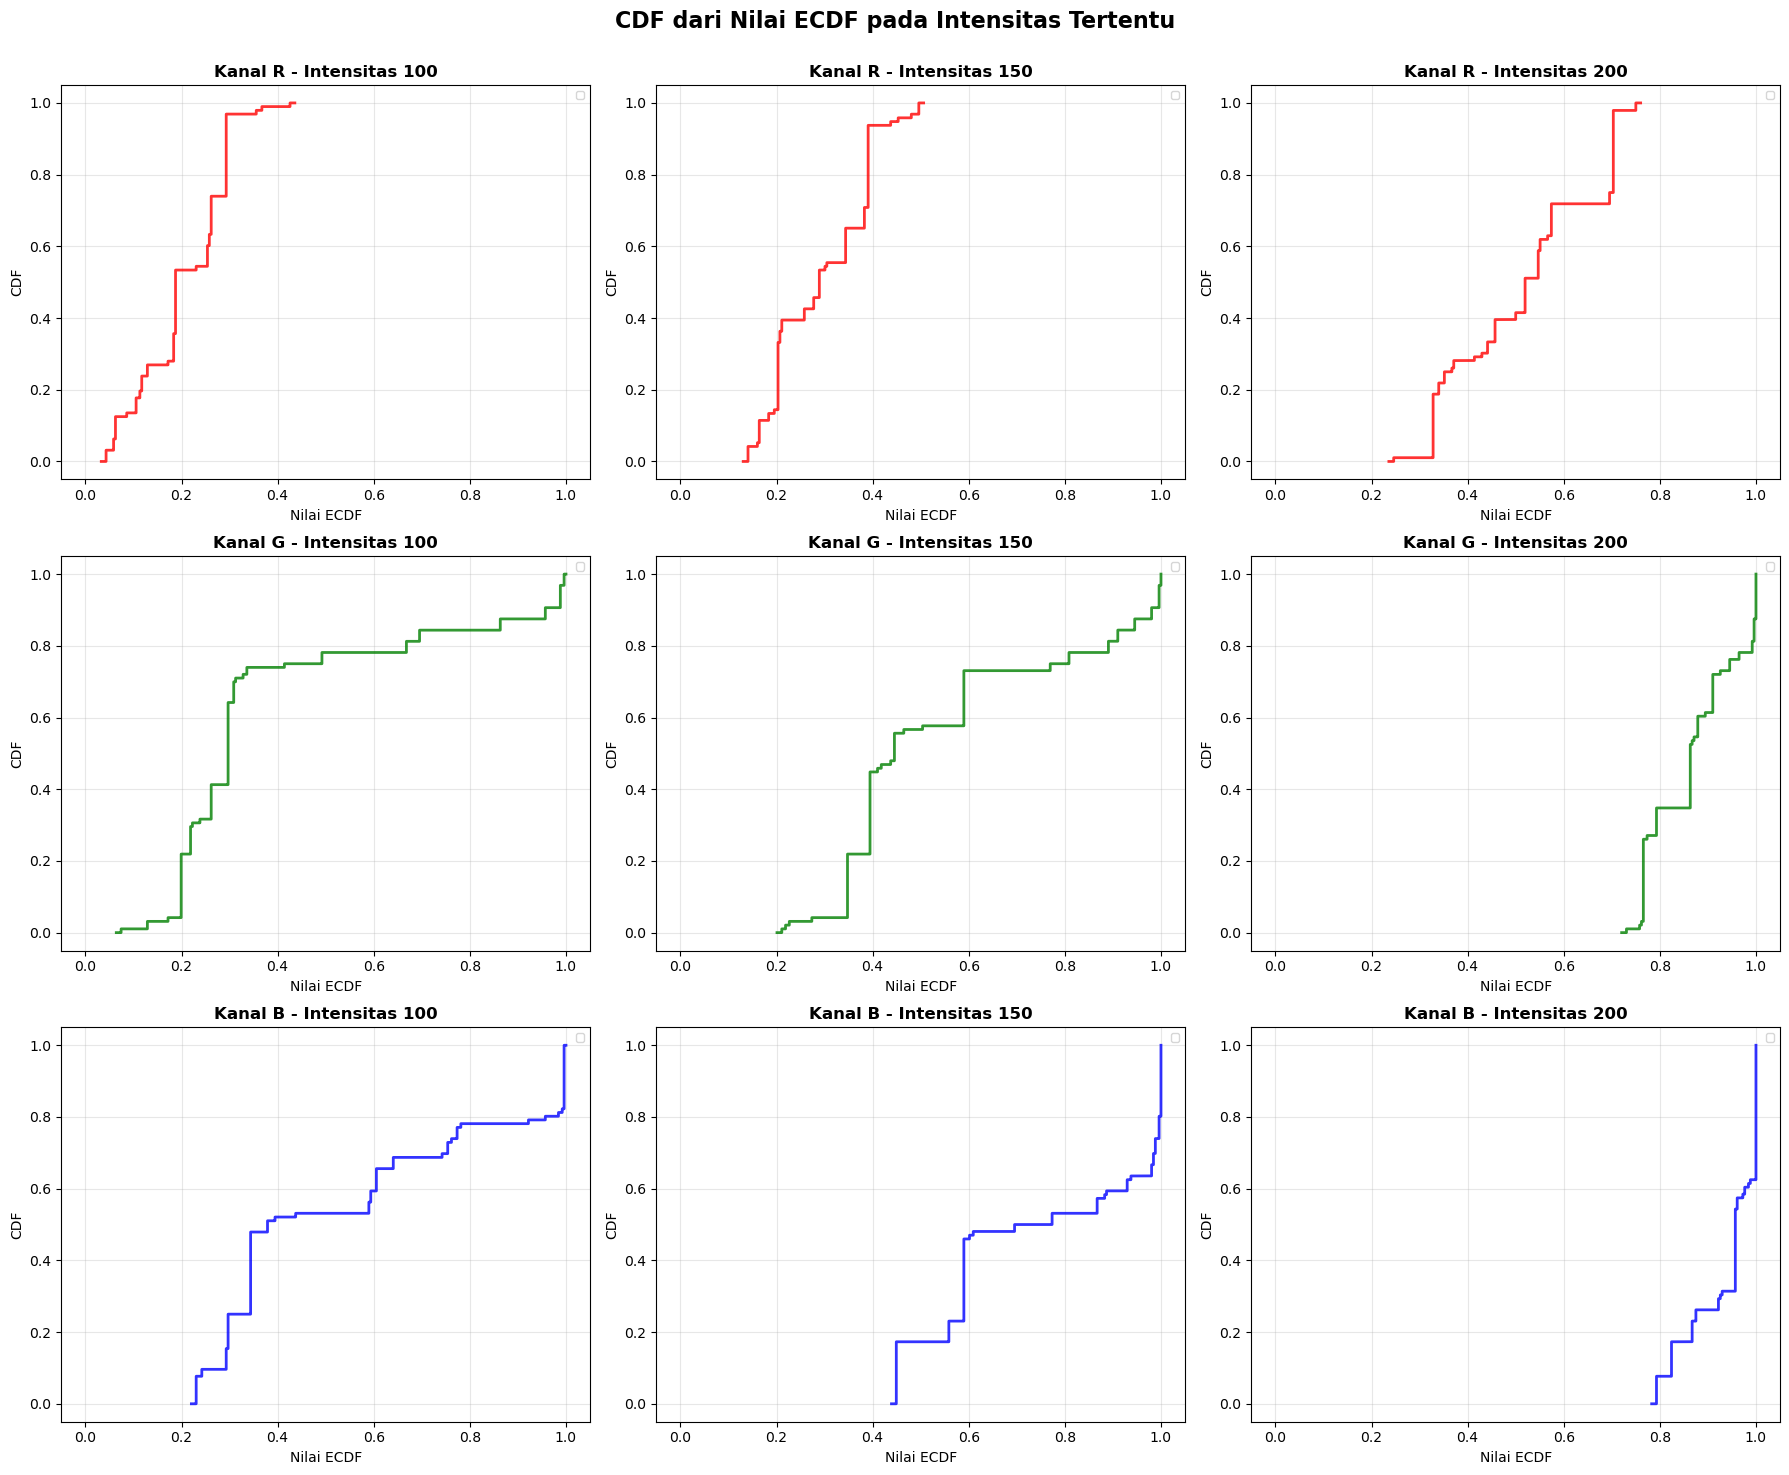

📊 Jumlah plot yang dibuat: 9
   - 3 channel: R, G, B
   - 3 intensitas: 100, 150, 200

9. MEMBUAT PLOT DISTRIBUSI ECDF INTENSITAS - 9 PLOT (DIPERBAIKI)

PLOT DISTRIBUSI ECDF PADA INTENSITAS TERTENTU - DIPERBAIKI


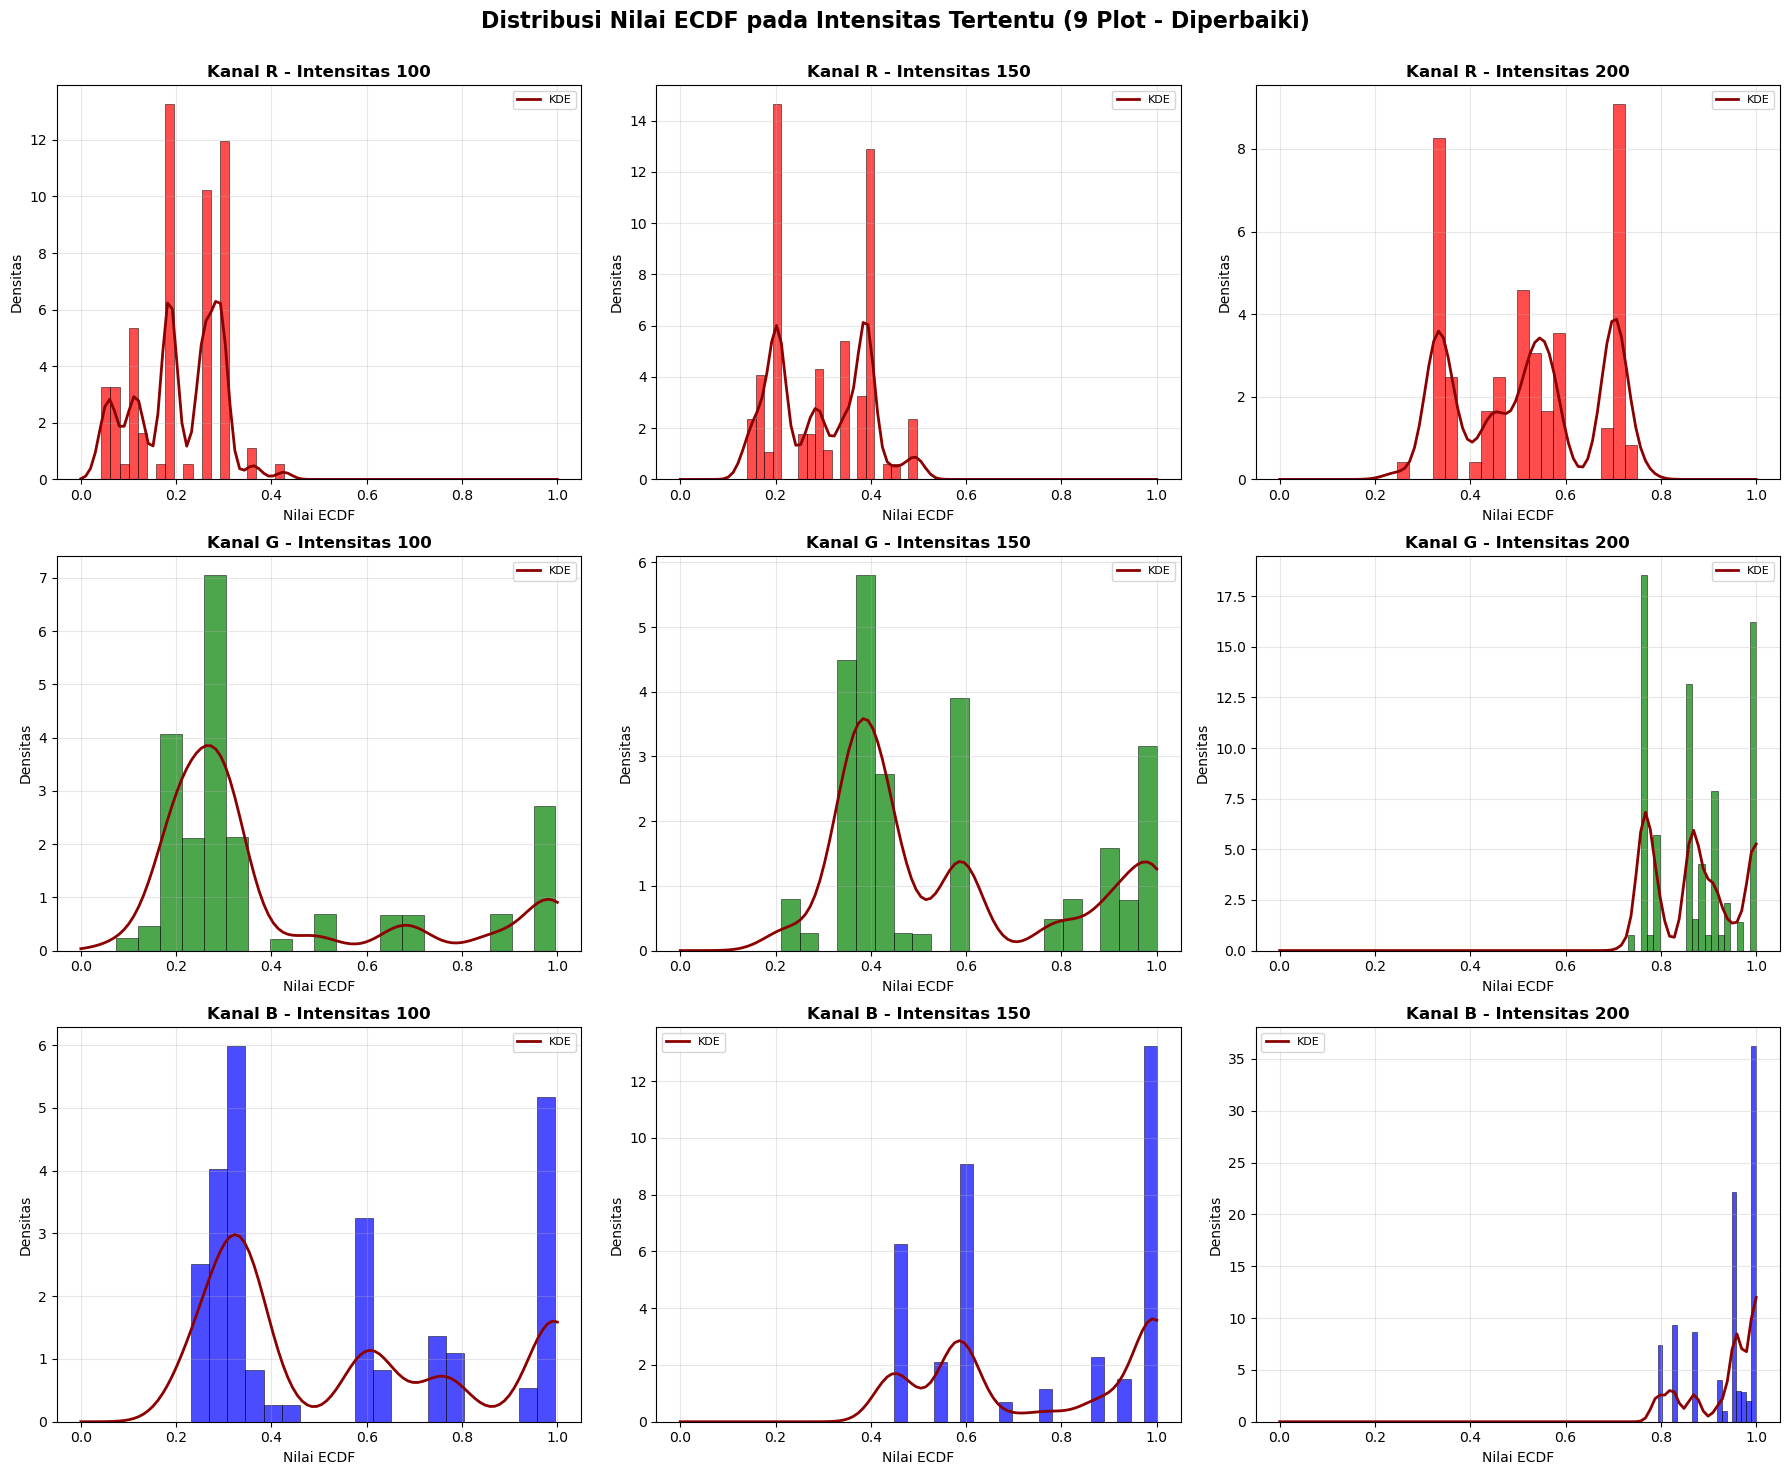


10. MEMBUAT PLOT PERBANDINGAN ECDF VS CDF - 9 PLOT (DIPERBAIKI)

PLOT PERBANDINGAN DISTRIBUSI ECDF VS CDF - DIPERBAIKI


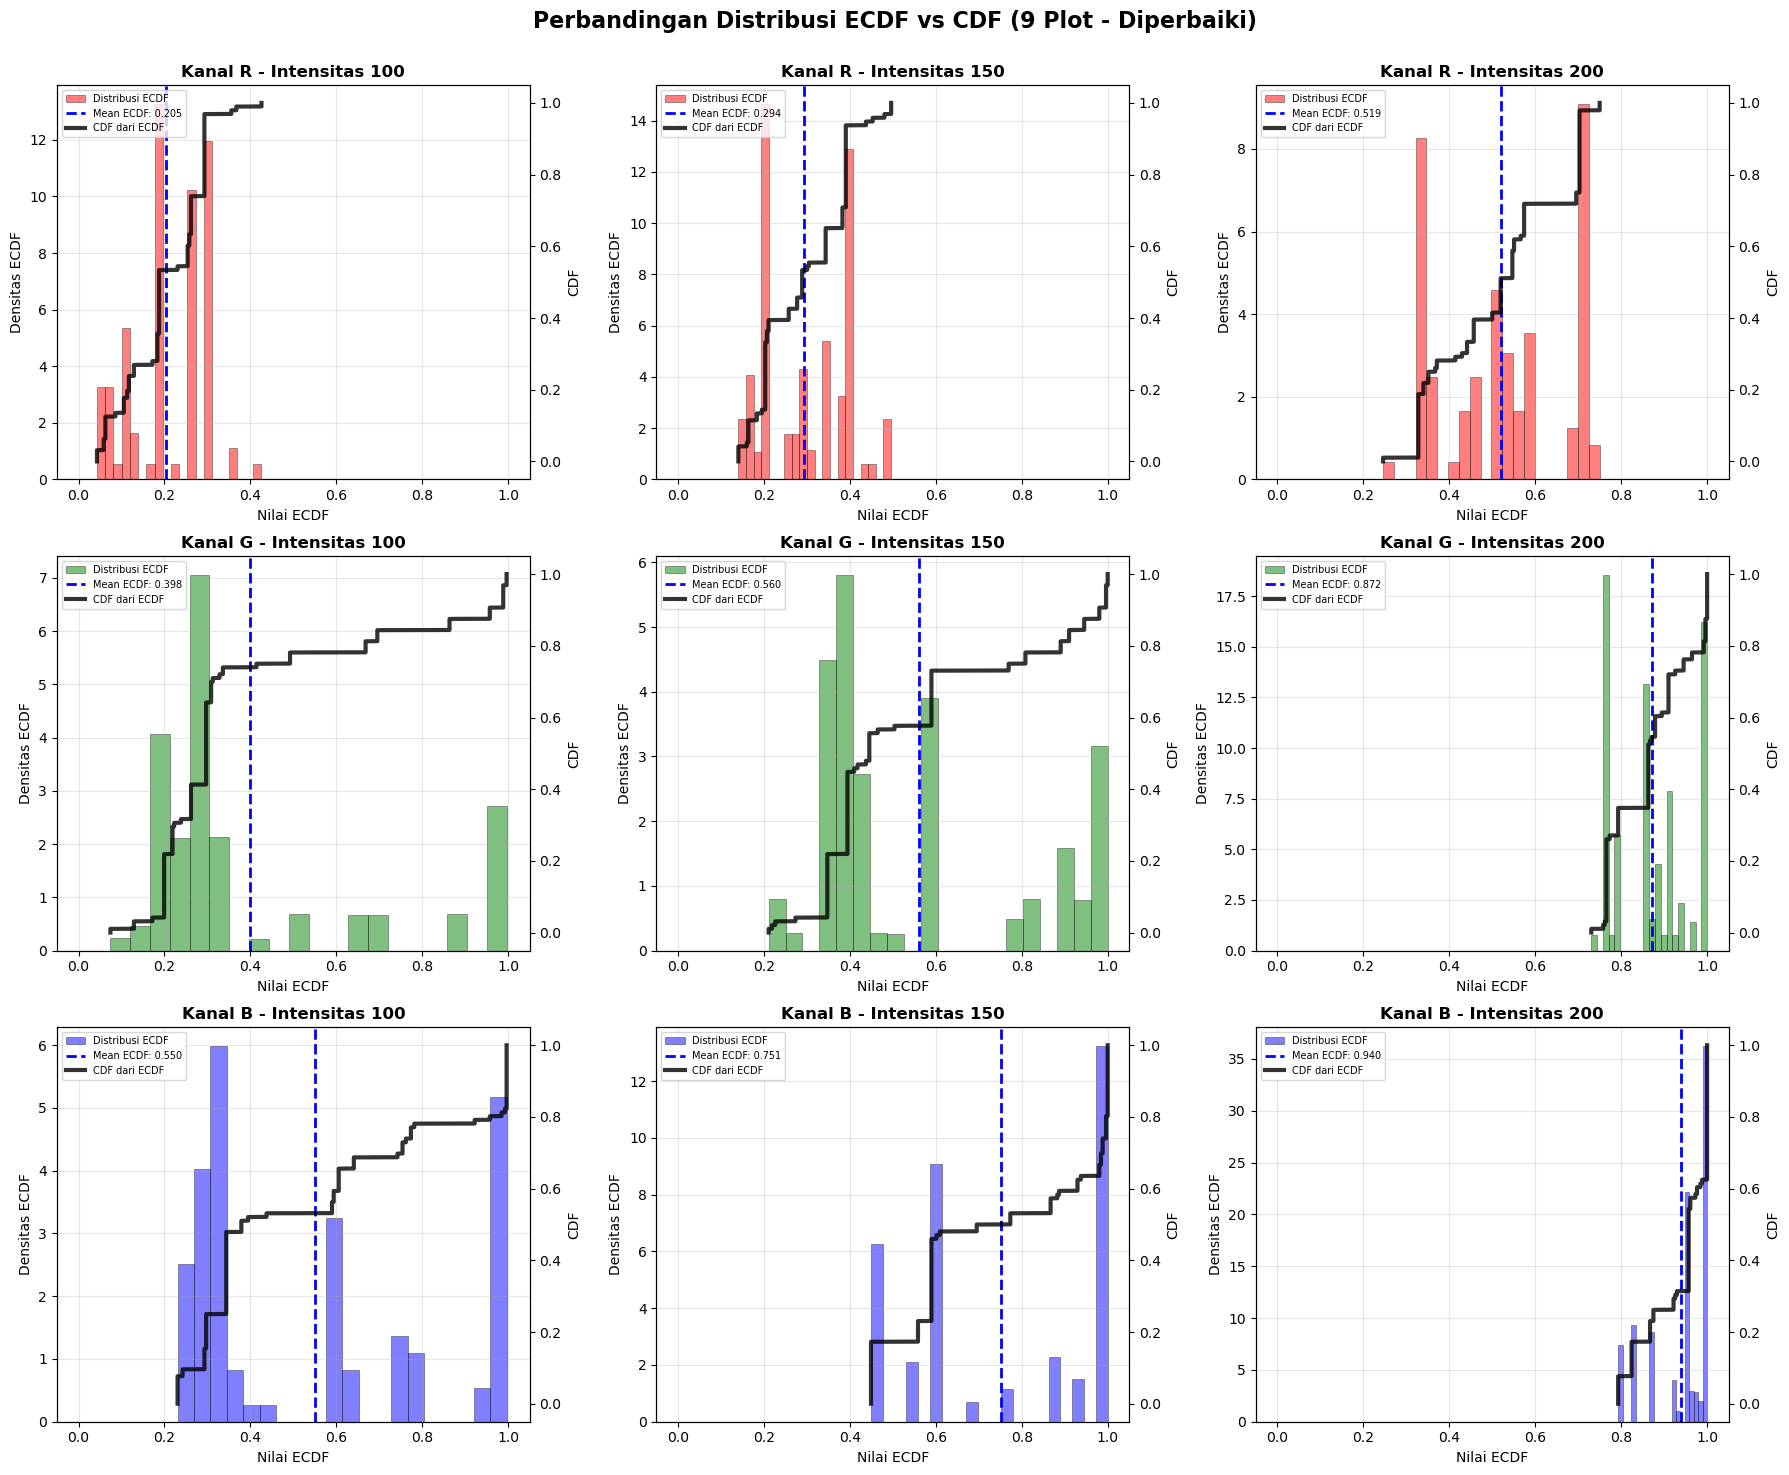


🎉 ANALISIS ECDF DENGAN GARIS VERTIKAL SELESAI!

📊 RINGKASAN HASIL:
   - Total gambar diproses: 4400
   - File output:
     * Data RGB: C:/Users/Ahsan/Downloads/data/data_ekstraksi_rgb_4kelas.xlsx
     * Data ECDF (CSV): C:/Users/Ahsan/Downloads/data/data_ecdf_rgb_4kelas.csv
     * Data ECDF Intensitas: C:/Users/Ahsan/Downloads/data/data_ecdf_intensitas_4kelas.xlsx
   - Plot yang dihasilkan:
     * CDF Intensitas Step Function (9 plot - Diperbaiki)
     * Distribusi ECDF Intensitas (9 plot - Diperbaiki)
     * Perbandingan ECDF vs CDF (9 plot - Diperbaiki)


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =============================================
# KONFIGURASI - 4 FOLDER MAWAR
# =============================================
pink_rose_folder = "C:/Users/Ahsan/Downloads/data/pink_rose"
red_rose_folder = "C:/Users/Ahsan/Downloads/data/red_rose"  
white_rose_folder = "C:/Users/Ahsan/Downloads/data/white_rose"
yellow_rose_folder = "C:/Users/Ahsan/Downloads/data/yellow_rose"

output_excel = "C:/Users/Ahsan/Downloads/data/data_ekstraksi_rgb_4kelas.xlsx"
ecdf_output_csv = "C:/Users/Ahsan/Downloads/data/data_ecdf_rgb_4kelas.csv"
ecdf_intensity_output_excel = "C:/Users/Ahsan/Downloads/data/data_ecdf_intensitas_4kelas.xlsx"

p = 16  # Ukuran resize gambar: p x p

# =============================================
# FUNGSI UTAMA UNTUK MEMPROSES GAMBAR
# =============================================

def process_image(image_path, label, gambar_ke):
    """
    Memproses satu gambar: resize ke p x p, ekstrak RGB, dan simpan ke Excel
    """
    # Baca gambar
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Tidak bisa membaca gambar: {image_path}")
        return None
    
    # Resize gambar menjadi p x p
    img_resized = cv2.resize(img, (p, p))
    
    # Konversi BGR ke RGB
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
    # Ekstrak channel R, G, B
    R = img_rgb[:, :, 0].flatten()
    G = img_rgb[:, :, 1].flatten()
    B = img_rgb[:, :, 2].flatten()
    
    # Hitung statistik
    hasil = {
        'filename': os.path.basename(image_path),
        'gambar_ke': gambar_ke,
        'label': label,
        'p': p,
        'total_pixels': p * p,
        'R_values': R,
        'G_values': G,
        'B_values': B,
        'avg_R': np.mean(R),
        'avg_G': np.mean(G),
        'avg_B': np.mean(B),
        'min_R': np.min(R),
        'max_R': np.max(R),
        'min_G': np.min(G),
        'max_G': np.max(G),
        'min_B': np.min(B),
        'max_B': np.max(B)
    }
    
    return hasil

def process_all_images(folder_path, label):
    """
    Memproses semua gambar dalam folder
    """
    results = []
    
    if not os.path.exists(folder_path):
        print(f"❌ Folder tidak ditemukan: {folder_path}")
        return pd.DataFrame()
    
    image_files = [f for f in os.listdir(folder_path) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not image_files:
        print(f"❌ Tidak ada gambar ditemukan di: {folder_path}")
        return pd.DataFrame()
    
    print(f"📁 Memproses {len(image_files)} gambar dari {folder_path} (label: {label})")
    
    for i, image_file in enumerate(image_files):
        image_path = os.path.join(folder_path, image_file)
        
        result = process_image(image_path, label, i+1)
        if result is not None:
            results.append(result)
    
    # Konversi ke DataFrame
    if results:
        df = pd.DataFrame(results)
        print(f"✅ Berhasil memproses {len(df)} gambar dengan label: {label}")
        return df
    else:
        print(f"❌ Tidak ada hasil yang berhasil diproses dari {folder_path}")
        return pd.DataFrame()

def save_rgb_to_excel(df_rgb, output_path):
    """
    Menyimpan data RGB ke file Excel
    """
    # Buat DataFrame yang lebih sederhana untuk disimpan
    save_data = []
    for _, row in df_rgb.iterrows():
        save_data.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label': row['label'],
            'p': row['p'],
            'total_pixels': row['total_pixels'],
            'R_values': str(row['R_values'].tolist()),
            'G_values': str(row['G_values'].tolist()),
            'B_values': str(row['B_values'].tolist()),
            'avg_R': row['avg_R'],
            'avg_G': row['avg_G'],
            'avg_B': row['avg_B'],
            'min_R': row['min_R'],
            'max_R': row['max_R'],
            'min_G': row['min_G'],
            'max_G': row['max_G'],
            'min_B': row['min_B'],
            'max_B': row['max_B']
        })
    
    df_save = pd.DataFrame(save_data)
    df_save.to_excel(output_path, index=False)
    print(f"💾 Data RGB disimpan ke: {output_path}")

# =============================================
# FUNGSI ECDF
# =============================================

def calculate_ecdf(values):
    """
    Menghitung ECDF untuk suatu set nilai
    """
    if len(values) == 0:
        return np.array([]), np.array([])
    
    # Urutkan nilai
    sorted_values = np.sort(values)
    
    # Hitung ECDF
    n = len(sorted_values)
    ecdf = np.arange(1, n + 1) / n
    
    return sorted_values, ecdf

def calculate_ecdf_for_image(image_data):
    """
    Menghitung ECDF untuk sebuah gambar
    """
    filename = image_data['filename']
    j = image_data['gambar_ke']
    label = image_data['label']
    p_j = image_data['p']
    
    ecdf_data = {
        'filename': filename,
        'gambar_ke': j,
        'label': label,
        'p_j': p_j,
        'R': {'intensity': [], 'ecdf': []},
        'G': {'intensity': [], 'ecdf': []},
        'B': {'intensity': [], 'ecdf': []}
    }
    
    # Untuk setiap channel R, G, B
    for channel in ['R', 'G', 'B']:
        values = image_data[f'{channel}_values']
        
        if len(values) > 0:
            intensity, ecdf = calculate_ecdf(values)
            ecdf_data[channel]['intensity'] = intensity
            ecdf_data[channel]['ecdf'] = ecdf
    
    return ecdf_data

def calculate_all_ecdf(df_rgb):
    """
    Menghitung ECDF untuk semua gambar
    """
    ecdf_results = {}
    
    for _, row in df_rgb.iterrows():
        ecdf_data = calculate_ecdf_for_image(row)
        ecdf_results[row['filename']] = ecdf_data
    
    return ecdf_results

def save_ecdf_to_csv(ecdf_data, output_path):
    """
    Menyimpan data ECDF ke file CSV (bukan Excel) untuk handle data besar
    """
    save_data = []
    
    for filename, data in ecdf_data.items():
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            if len(channel_data['intensity']) > 0:
                for intensity, ecdf_val in zip(channel_data['intensity'], channel_data['ecdf']):
                    save_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'intensity': intensity,
                        'ecdf': ecdf_val,
                        'p_j': data['p_j']
                    })
    
    df_save = pd.DataFrame(save_data)
    
    # Simpan ke CSV bukan Excel
    df_save.to_csv(output_path, index=False)
    print(f"💾 Data ECDF disimpan ke: {output_path}")
    print(f"📊 Jumlah baris data ECDF: {len(df_save)}")

# =============================================
# FUNGSI EKSTRAKSI ECDF PADA INTENSITAS TERTENTU
# =============================================

def extract_ecdf_at_intensities(ecdf_data, intensities=[100, 150, 200]):
    """
    Mengekstrak nilai ECDF pada intensitas tertentu untuk setiap gambar dan channel
    """
    ecdf_intensity_data = []
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Untuk setiap intensitas target, cari nilai ECDF-nya
                for intensity in intensities:
                    ecdf_val = 0.0
                    
                    if intensity < intensity_values[0]:
                        ecdf_val = 0.0
                    elif intensity >= intensity_values[-1]:
                        ecdf_val = 1.0
                    else:
                        # Cari di segmen mana intensitas berada
                        for m in range(len(intensity_values) - 1):
                            if intensity_values[m] <= intensity < intensity_values[m + 1]:
                                ecdf_val = ecdf_values[m]
                                break
                        else:
                            # Jika tidak ditemukan dalam loop, gunakan nilai terakhir
                            ecdf_val = ecdf_values[-1] if intensity >= intensity_values[-1] else 0.0
                    
                    ecdf_intensity_data.append({
                        'filename': filename,
                        'gambar_ke': j,
                        'label': label,
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val
                    })
    
    df_ecdf_intensities = pd.DataFrame(ecdf_intensity_data)
    return df_ecdf_intensities

# =============================================
# FUNGSI CDF INTENSITAS YANG DIPERBAIKI
# =============================================

def calculate_cdf_for_ecdf_intensities_fixed(df_ecdf_intensities):
    """
    MENGHITUNG CDF DENGAN CARA YANG BENAR:
    1. Urutkan nilai ECDF per intensitas dan per channel untuk SEMUA GAMBAR
    2. Buat CDF dari nilai ECDF yang sudah diurutkan tersebut
    """
    cdf_data = []
    
    # Dapatkan semua kombinasi unik dari channel dan intensity_target
    unique_combinations = df_ecdf_intensities[['channel', 'intensity_target']].drop_duplicates()
    
    print("📊 Menghitung CDF untuk ECDF intensitas:")
    
    for _, combo in unique_combinations.iterrows():
        channel = combo['channel']
        intensity = combo['intensity_target']
        
        # Ambil semua nilai ECDF untuk channel dan intensitas tertentu (SEMUA GAMBAR, SEMUA LABEL)
        ecdf_values = df_ecdf_intensities[
            (df_ecdf_intensities['channel'] == channel) & 
            (df_ecdf_intensities['intensity_target'] == intensity)
        ]['ecdf_value'].values
        
        print(f"   - Channel {channel}, Intensitas {intensity}: {len(ecdf_values)} nilai ECDF")
        
        if len(ecdf_values) > 0:
            # 1. URUTKAN nilai ECDF untuk semua gambar
            sorted_ecdf = np.sort(ecdf_values)
            
            # 2. HITUNG CDF dari nilai ECDF yang sudah diurutkan
            n = len(sorted_ecdf)
            cdf_values = np.arange(1, n + 1) / n
            
            # Simpan data CDF
            for ecdf_val, cdf_val in zip(sorted_ecdf, cdf_values):
                cdf_data.append({
                    'channel': channel,
                    'intensity_target': intensity,
                    'ecdf_value': ecdf_val,
                    'cdf_value': cdf_val
                })
    
    df_cdf = pd.DataFrame(cdf_data)
    print(f"✅ CDF berhasil dihitung untuk {len(unique_combinations)} kombinasi channel-intensitas")
    return df_cdf

def save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, output_path):
    """
    Menyimpan data ECDF pada intensitas tertentu dan CDF-nya ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data ECDF pada intensitas tertentu
        df_ecdf_intensities.to_excel(writer, sheet_name='ECDF_Intensitas', index=False)
        
        # Sheet 2: Data CDF dari ECDF intensitas
        df_cdf.to_excel(writer, sheet_name='CDF_ECDF_Intensitas', index=False)
    
    print(f"💾 Data ECDF intensitas dan CDF disimpan ke: {output_path}")

# =============================================
# FUNGSI PLOT CDF INTENSITAS YANG DIPERBAIKI - 9 PLOT
# =============================================

def plot_cdf_intensities_step_function_9plots_fixed(df_cdf):
    """
    Plot CDF dari nilai ECDF intensitas dalam bentuk step function - 9 PLOT
    DIPERBAIKI: CDF dihitung dari nilai ECDF yang diurutkan untuk semua gambar
    """
    print("\n" + "="*80)
    print("PLOT CDF INTENSITAS")
    print("="*80)
    
    # Warna untuk setiap channel
    channel_colors = {'R': 'red', 'G': 'green', 'B': 'blue'}
    
    # Buat 9 plot (3x3 grid)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('CDF dari Nilai ECDF pada Intensitas Tertentu', 
                fontsize=16, fontweight='bold')
    
    channels = ['R', 'G', 'B']
    intensities = [100, 150, 200]
    
    for i, channel in enumerate(channels):
        for j, intensity in enumerate(intensities):
            ax = axes[i, j]
            
            # Filter data untuk channel dan intensitas tertentu
            channel_data = df_cdf[
                (df_cdf['channel'] == channel) & 
                (df_cdf['intensity_target'] == intensity)
            ]
            
            if not channel_data.empty:
                # Data sudah diurutkan dari perhitungan CDF
                ecdf_values = channel_data['ecdf_value'].values
                cdf_values = channel_data['cdf_value'].values
                
                # Buat step function untuk CDF
                x_step = []
                y_step = []
                
                # Titik awal
                x_step.append(max(0, ecdf_values[0] - 0.01))
                y_step.append(0)
                
                # Untuk setiap titik data, buat step
                for k in range(len(cdf_values)):
                    # Sebelum lompatan
                    x_step.append(ecdf_values[k])
                    y_step.append(cdf_values[k-1] if k > 0 else 0)
                    
                    # Setelah lompatan
                    x_step.append(ecdf_values[k])
                    y_step.append(cdf_values[k])
                
                # Titik akhir
                x_step.append(min(1.0, ecdf_values[-1] + 0.01))
                y_step.append(1.0)
                
                # Plot step function
                ax.plot(x_step, y_step, color=channel_colors[channel], linewidth=2, alpha=0.8)
                
                # Hitung dan tampilkan statistik
                #mean_ecdf = np.mean(ecdf_values)
                #std_ecdf = np.std(ecdf_values)
                
                # Tambahkan garis vertikal di mean
                #ax.axvline(mean_ecdf, color=channel_colors[channel], linestyle='--', alpha=0.7, 
                          #linewidth=1, label=f'Mean: {mean_ecdf:.3f}')
                
                # Tambahkan informasi statistik
                #ax.text(0.02, 0.98, f'N: {len(ecdf_values)}\nMean: {mean_ecdf:.3f}\nStd: {std_ecdf:.3f}', 
                       #transform=ax.transAxes, verticalalignment='top',
                       #bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                       #fontsize=9)
            
            ax.set_title(f'Kanal {channel} - Intensitas {intensity}', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Nilai ECDF', fontsize=10)
            ax.set_ylabel('CDF', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)
            ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()
    
    print(f"📊 Jumlah plot yang dibuat: 9")
    print(f"   - 3 channel: R, G, B")
    print(f"   - 3 intensitas: 100, 150, 200")

def plot_ecdf_intensities_distribution_fixed(df_ecdf_intensities):
    """
    Plot distribusi nilai ECDF pada intensitas tertentu - DIPERBAIKI
    """
    print("\n" + "="*80)
    print("PLOT DISTRIBUSI ECDF PADA INTENSITAS TERTENTU - DIPERBAIKI")
    print("="*80)
    
    # Buat 9 plot (3x3 grid)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('Distribusi Nilai ECDF pada Intensitas Tertentu (9 Plot - Diperbaiki)', 
                fontsize=16, fontweight='bold')
    
    channels = ['R', 'G', 'B']
    intensities = [100, 150, 200]
    channel_colors = {'R': 'red', 'G': 'green', 'B': 'blue'}
    
    for i, channel in enumerate(channels):
        for j, intensity in enumerate(intensities):
            ax = axes[i, j]
            
            # Filter data untuk channel dan intensitas tertentu
            channel_data = df_ecdf_intensities[
                (df_ecdf_intensities['channel'] == channel) & 
                (df_ecdf_intensities['intensity_target'] == intensity)
            ]
            
            if not channel_data.empty:
                ecdf_values = channel_data['ecdf_value'].values
                
                # Plot histogram
                n, bins, patches = ax.hist(ecdf_values, bins=20, alpha=0.7, color=channel_colors[channel],
                                          density=True, edgecolor='black', linewidth=0.5)
                
                # Tambahkan KDE
                from scipy.stats import gaussian_kde
                if len(ecdf_values) > 1:
                    kde = gaussian_kde(ecdf_values)
                    x_range = np.linspace(0, 1, 100)
                    ax.plot(x_range, kde(x_range), color='darkred', linewidth=2, label='KDE')
                
                # Hitung statistik
                mean_val = np.mean(ecdf_values)
                std_val = np.std(ecdf_values)
                median_val = np.median(ecdf_values)
                
                # Tambahkan garis statistik
                #ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.3f}')
                #ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.3f}')
                #ax.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='gray', label=f'Std: {std_val:.3f}')
            
            ax.set_title(f'Kanal {channel} - Intensitas {intensity}', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Nilai ECDF', fontsize=10)
            ax.set_ylabel('Densitas', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(-0.05, 1.05)
            ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

def plot_comparison_ecdf_vs_cdf(df_ecdf_intensities, df_cdf):
    """
    Plot perbandingan antara distribusi ECDF dan CDF yang dihasilkan
    """
    print("\n" + "="*80)
    print("PLOT PERBANDINGAN DISTRIBUSI ECDF VS CDF - DIPERBAIKI")
    print("="*80)
    
    # Buat 9 plot (3x3 grid)
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('Perbandingan Distribusi ECDF vs CDF (9 Plot - Diperbaiki)', 
                fontsize=16, fontweight='bold')
    
    channels = ['R', 'G', 'B']
    intensities = [100, 150, 200]
    channel_colors = {'R': 'red', 'G': 'green', 'B': 'blue'}
    
    for i, channel in enumerate(channels):
        for j, intensity in enumerate(intensities):
            ax = axes[i, j]
            
            # Data ECDF asli
            ecdf_data = df_ecdf_intensities[
                (df_ecdf_intensities['channel'] == channel) & 
                (df_ecdf_intensities['intensity_target'] == intensity)
            ]['ecdf_value'].values
            
            # Data CDF
            cdf_data = df_cdf[
                (df_cdf['channel'] == channel) & 
                (df_cdf['intensity_target'] == intensity)
            ]
            
            if len(ecdf_data) > 0 and not cdf_data.empty:
                # Plot histogram ECDF
                ax.hist(ecdf_data, bins=20, alpha=0.5, color=channel_colors[channel],
                       density=True, edgecolor='black', linewidth=0.5, label='Distribusi ECDF')
                
                # Plot CDF sebagai line plot
                ax2 = ax.twinx()
                ecdf_sorted = cdf_data['ecdf_value'].values
                cdf_values = cdf_data['cdf_value'].values
                ax2.plot(ecdf_sorted, cdf_values, color='black', linewidth=3, 
                        label='CDF dari ECDF', alpha=0.8)
                ax2.set_ylabel('CDF', fontsize=10)
                ax2.set_ylim(-0.05, 1.05)
                
                # Statistik
                mean_ecdf = np.mean(ecdf_data)
                ax.axvline(mean_ecdf, color='blue', linestyle='--', linewidth=2, 
                          label=f'Mean ECDF: {mean_ecdf:.3f}')
            
            ax.set_title(f'Kanal {channel} - Intensitas {intensity}', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Nilai ECDF', fontsize=10)
            ax.set_ylabel('Densitas ECDF', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(-0.05, 1.05)
            
            # Gabungkan legend
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper left')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

# =============================================
# FUNGSI UTAMA YANG DIPERBAIKI
# =============================================

def main_ecdf_with_vertical_lines():
    """
    Fungsi utama untuk analisis ECDF dengan garis vertikal intensitas
    """
    print("ANALISIS ECDF DENGAN GARIS VERTIKAL INTENSITAS - 4 KELAS MAWAR")
    print("=" * 80)
    
    # 1. Proses gambar dari 4 folder
    print("\n1. PROSES GAMBAR DARI 4 FOLDER MAWAR")
    
    print(f"\n📁 Memproses folder: {pink_rose_folder}")
    df_pink = process_all_images(pink_rose_folder, "pink")
    
    print(f"\n📁 Memproses folder: {red_rose_folder}")
    df_red = process_all_images(red_rose_folder, "red")
    
    print(f"\n📁 Memproses folder: {white_rose_folder}")
    df_white = process_all_images(white_rose_folder, "white")
    
    print(f"\n📁 Memproses folder: {yellow_rose_folder}")
    df_yellow = process_all_images(yellow_rose_folder, "yellow")
    
    # 2. Gabungkan semua hasil
    all_dfs = [df_pink, df_red, df_white, df_yellow]
    all_dfs = [df for df in all_dfs if not df.empty]
    
    if not all_dfs:
        print("❌ Tidak ada data yang diproses. Periksa path folder dan file gambar.")
        return
    
    all_df_rgb = pd.concat(all_dfs, ignore_index=True)
    
    print(f"\n📊 Total gambar diproses: {len(all_df_rgb)}")
    print(f"  - Mawar pink: {len(df_pink)}")
    print(f"  - Mawar merah: {len(df_red)}")
    print(f"  - Mawar putih: {len(df_white)}")
    print(f"  - Mawar kuning: {len(df_yellow)}")
    
    # 3. Simpan data RGB ke Excel
    print(f"\n2. MENYIMPAN DATA RGB KE EXCEL: {output_excel}")
    save_rgb_to_excel(all_df_rgb, output_excel)
    
    # 4. Hitung ECDF untuk semua gambar
    print("\n3. MENGHITUNG ECDF UNTUK SEMUA GAMBAR")
    all_ecdf_results = calculate_all_ecdf(all_df_rgb)
    
    # 5. Simpan data ECDF ke CSV
    print(f"\n4. MENYIMPAN DATA ECDF KE CSV: {ecdf_output_csv}")
    save_ecdf_to_csv(all_ecdf_results, ecdf_output_csv)
    
    # 6. Ekstrak nilai ECDF pada intensitas tertentu
    print("\n5. EKSTRAKSI NILAI ECDF PADA INTENSITAS 100, 150, 200")
    df_ecdf_intensities = extract_ecdf_at_intensities(all_ecdf_results)
    
    # 7. Hitung CDF untuk nilai ECDF pada intensitas tertentu - DIPERBAIKI
    print("\n6. MENGHITUNG CDF UNTUK NILAI ECDF PADA INTENSITAS TERTENTU (DIPERBAIKI)")
    df_cdf = calculate_cdf_for_ecdf_intensities_fixed(df_ecdf_intensities)
    
    # 8. Simpan data ECDF intensitas dan CDF
    print(f"\n7. MENYIMPAN DATA ECDF INTENSITAS DAN CDF: {ecdf_intensity_output_excel}")
    save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, ecdf_intensity_output_excel)
    
    # =============================================
    # PLOT YANG DIPERBAIKI
    # =============================================
    
    # 9. Plot CDF intensitas step function - 9 PLOT (DIPERBAIKI)
    print("\n8. MEMBUAT PLOT CDF INTENSITAS STEP FUNCTION - 9 PLOT (DIPERBAIKI)")
    plot_cdf_intensities_step_function_9plots_fixed(df_cdf)
    
    # 10. Plot distribusi ECDF intensitas - 9 PLOT (DIPERBAIKI)
    print("\n9. MEMBUAT PLOT DISTRIBUSI ECDF INTENSITAS - 9 PLOT (DIPERBAIKI)")
    plot_ecdf_intensities_distribution_fixed(df_ecdf_intensities)
    
    # 11. Plot perbandingan ECDF vs CDF - 9 PLOT (DIPERBAIKI)
    print("\n10. MEMBUAT PLOT PERBANDINGAN ECDF VS CDF - 9 PLOT (DIPERBAIKI)")
    plot_comparison_ecdf_vs_cdf(df_ecdf_intensities, df_cdf)
    
    print("\n" + "="*80)
    print("🎉 ANALISIS ECDF DENGAN GARIS VERTIKAL SELESAI!")
    print("="*80)
    
    # Ringkasan akhir
    print("\n📊 RINGKASAN HASIL:")
    print(f"   - Total gambar diproses: {len(all_df_rgb)}")
    print(f"   - File output:")
    print(f"     * Data RGB: {output_excel}")
    print(f"     * Data ECDF (CSV): {ecdf_output_csv}")
    print(f"     * Data ECDF Intensitas: {ecdf_intensity_output_excel}")
    print(f"   - Plot yang dihasilkan:")
    print(f"     * CDF Intensitas Step Function (9 plot - Diperbaiki)")
    print(f"     * Distribusi ECDF Intensitas (9 plot - Diperbaiki)")
    print(f"     * Perbandingan ECDF vs CDF (9 plot - Diperbaiki)")

if __name__ == "__main__":
    # Jalankan analisis ECDF dengan garis vertikal
    main_ecdf_with_vertical_lines()

MENAMPILKAN GAMBAR SAMPEL DARI 4 KELAS MAWAR

1. 📊 STATISTIK JUMLAH GAMBAR

STATISTIK JUMLAH GAMBAR PER FOLDER
📊 Pink Rose: 1100 gambar
📊 Red Rose: 1100 gambar
📊 White Rose: 1100 gambar
📊 Yellow Rose: 1100 gambar


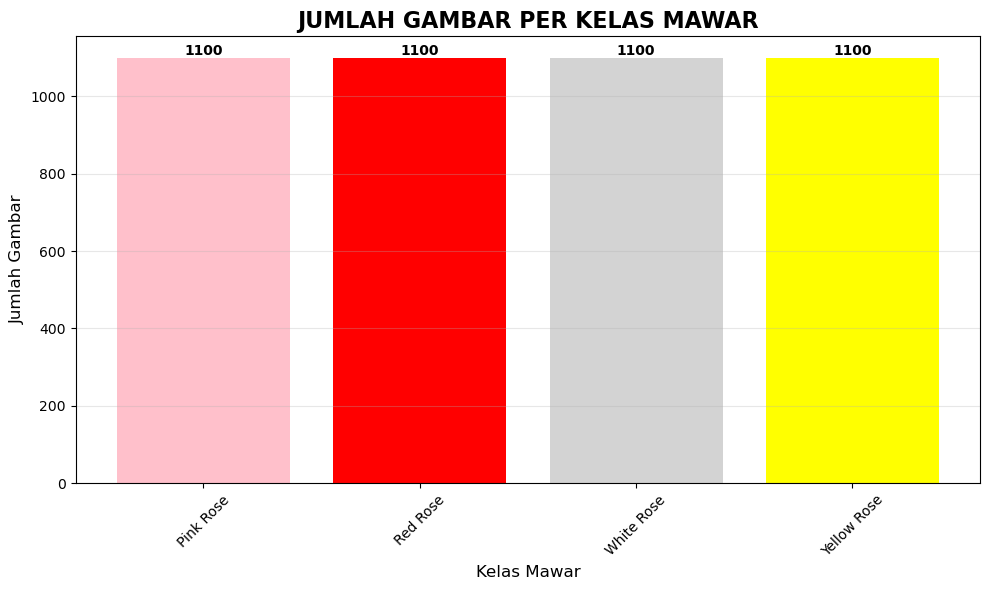


2. 🖼️ MENAMPILKAN SAMPEL GAMBAR
📁 Memproses folder: Pink Rose -> C:/Users/Ahsan/Downloads/data/pink_rose
   Ditemukan 1100 gambar
📁 Memproses folder: Red Rose -> C:/Users/Ahsan/Downloads/data/red_rose
   Ditemukan 1100 gambar
📁 Memproses folder: White Rose -> C:/Users/Ahsan/Downloads/data/white_rose
   Ditemukan 1100 gambar
📁 Memproses folder: Yellow Rose -> C:/Users/Ahsan/Downloads/data/yellow_rose
   Ditemukan 1100 gambar


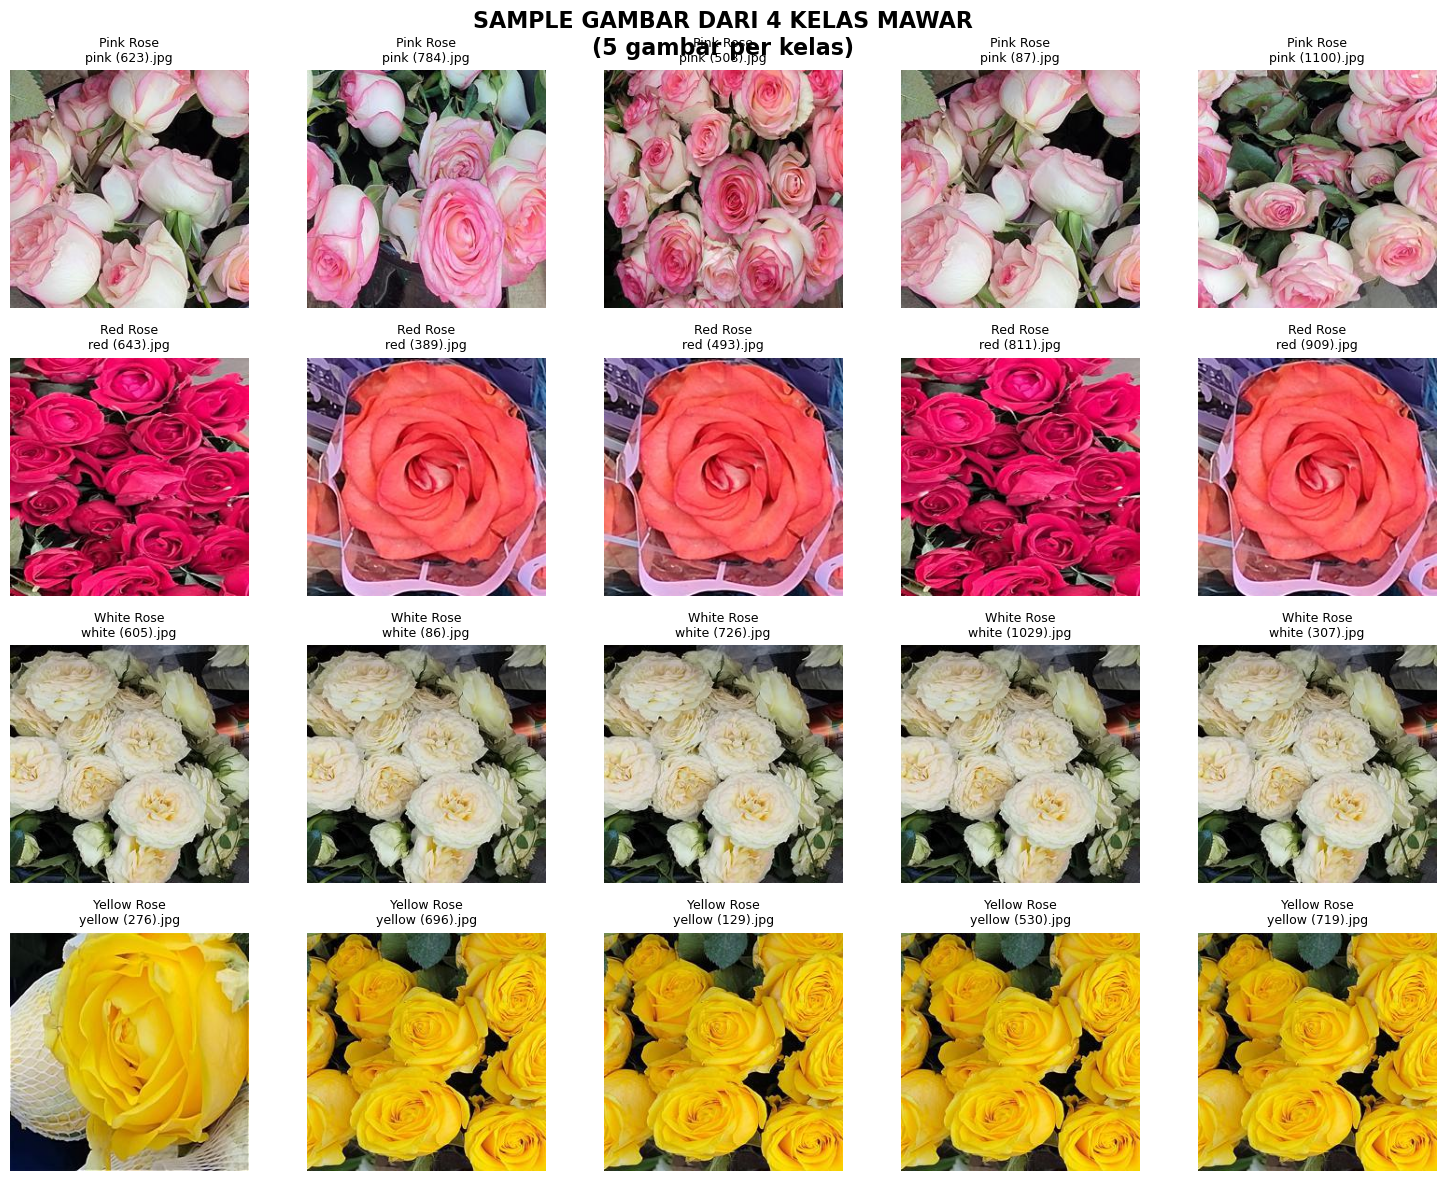


✅ Berhasil menampilkan 5 sampel gambar dari 4 kelas

3. 🔍 PERBANDINGAN GAMBAR ASLI vs RESIZE

PERBANDINGAN GAMBAR ASLI vs RESIZE (16x16)


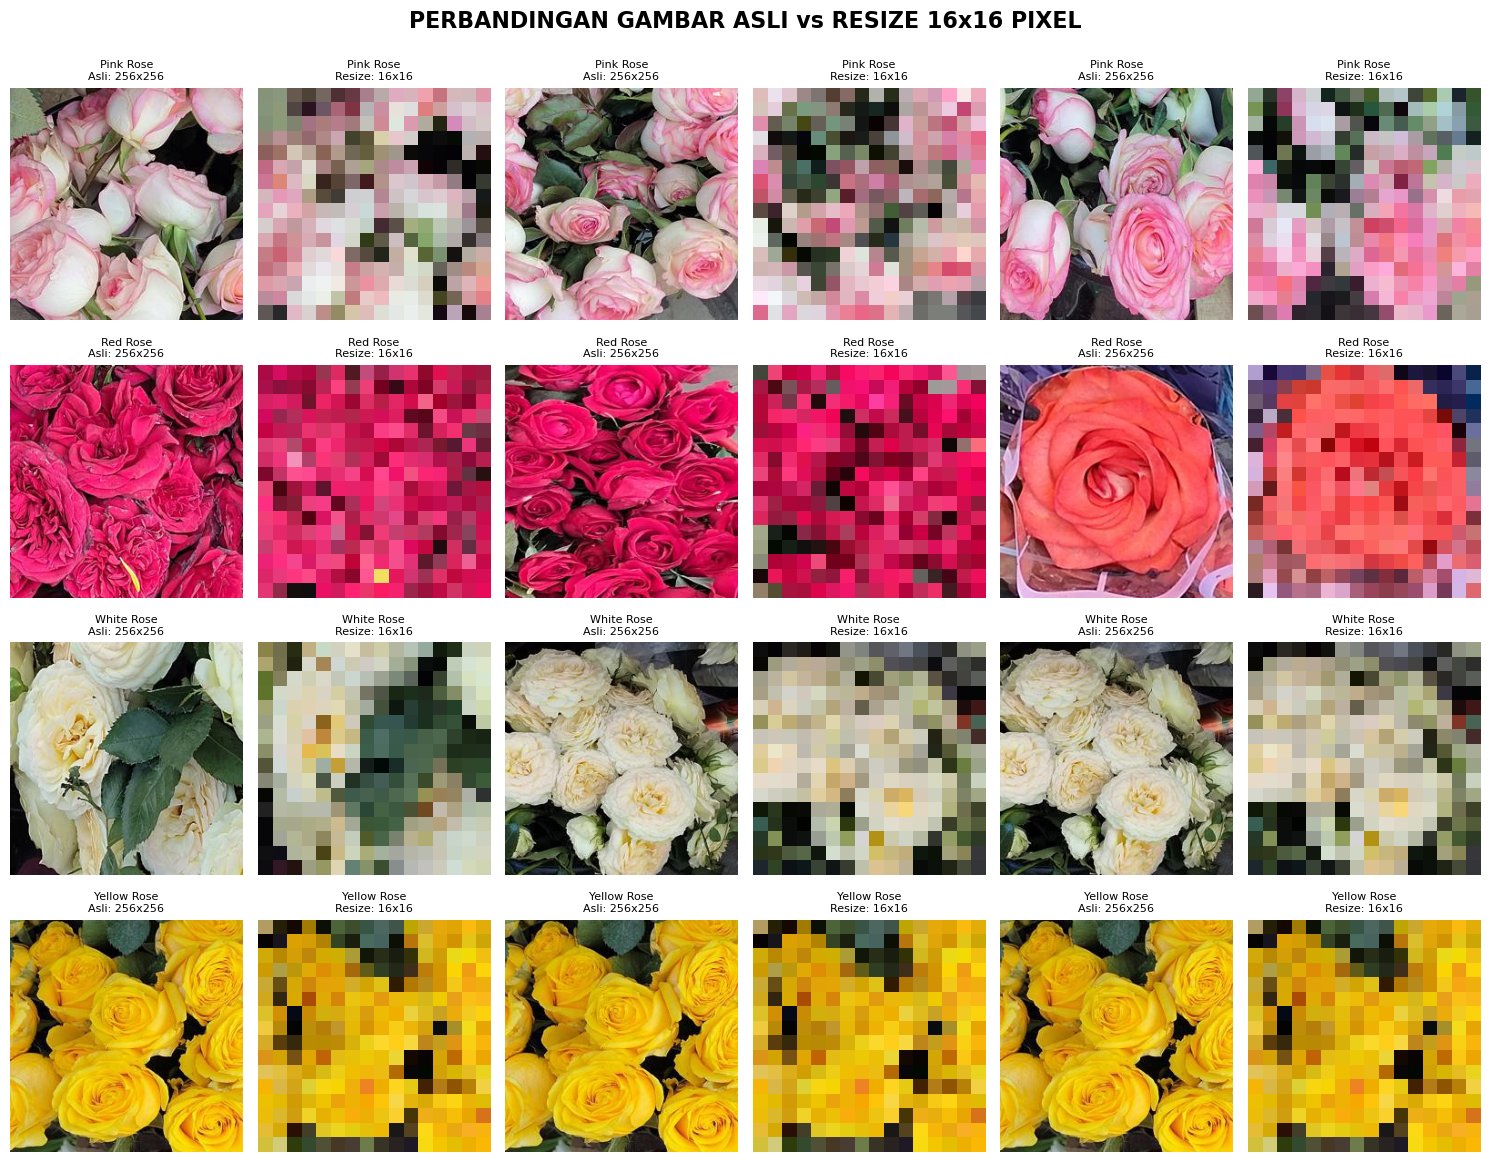


RINGKASAN DATA GAMBAR
📈 Total semua gambar: 4400
   ✅ Pink Rose: 1100 gambar
   ✅ Red Rose: 1100 gambar
   ✅ White Rose: 1100 gambar
   ✅ Yellow Rose: 1100 gambar

🎉 Penampilan gambar selesai!


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =============================================
# KONFIGURASI - 4 FOLDER MAWAR
# =============================================
pink_rose_folder = "C:/Users/Ahsan/Downloads/data/pink_rose"
red_rose_folder = "C:/Users/Ahsan/Downloads/data/red_rose"  
white_rose_folder = "C:/Users/Ahsan/Downloads/data/white_rose"
yellow_rose_folder = "C:/Users/Ahsan/Downloads/data/yellow_rose"

# =============================================
# FUNGSI UNTUK MENAMPILKAN GAMBAR SAMPEL
# =============================================

def display_sample_images_from_folders(folders_dict, num_samples=5):
    """
    Menampilkan sampel gambar dari setiap folder
    
    Parameters:
    - folders_dict: dictionary berisi nama folder dan path
    - num_samples: jumlah gambar sampel yang akan ditampilkan per folder
    """
    
    # Setup plot
    n_folders = len(folders_dict)
    fig, axes = plt.subplots(n_folders, num_samples, figsize=(15, 3*n_folders))
    
    # Jika hanya 1 folder, buat axes menjadi 2D array
    if n_folders == 1:
        axes = np.array([axes])
    
    fig.suptitle(f'SAMPLE GAMBAR DARI {n_folders} KELAS MAWAR\n({num_samples} gambar per kelas)', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    for row_idx, (folder_name, folder_path) in enumerate(folders_dict.items()):
        print(f"📁 Memproses folder: {folder_name} -> {folder_path}")
        
        # Cek apakah folder exists
        if not os.path.exists(folder_path):
            print(f"❌ Folder tidak ditemukan: {folder_path}")
            continue
            
        # Dapatkan list file gambar
        image_files = [f for f in os.listdir(folder_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if not image_files:
            print(f"❌ Tidak ada gambar ditemukan di: {folder_path}")
            continue
            
        print(f"   Ditemukan {len(image_files)} gambar")
        
        # Pilih sampel acak
        if len(image_files) < num_samples:
            samples = image_files
            print(f"   ⚠️  Hanya {len(samples)} gambar yang tersedia")
        else:
            samples = np.random.choice(image_files, num_samples, replace=False)
        
        # Tampilkan setiap sampel
        for col_idx, img_file in enumerate(samples):
            img_path = os.path.join(folder_path, img_file)
            
            # Baca gambar
            img = cv2.imread(img_path)
            if img is None:
                print(f"❌ Tidak bisa membaca gambar: {img_path}")
                continue
                
            # Konversi BGR ke RGB untuk matplotlib
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Tampilkan gambar
            if n_folders > 1:
                ax = axes[row_idx, col_idx]
            else:
                ax = axes[col_idx]
                
            ax.imshow(img_rgb)
            ax.set_title(f"{folder_name}\n{img_file}", fontsize=9)
            ax.axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()
    
    print(f"\n✅ Berhasil menampilkan {num_samples} sampel gambar dari {n_folders} kelas")

def display_image_statistics(folders_dict):
    """
    Menampilkan statistik jumlah gambar di setiap folder
    """
    print("\n" + "="*60)
    print("STATISTIK JUMLAH GAMBAR PER FOLDER")
    print("="*60)
    
    stats_data = []
    
    for folder_name, folder_path in folders_dict.items():
        if not os.path.exists(folder_path):
            print(f"❌ Folder tidak ditemukan: {folder_path}")
            stats_data.append({'Kelas': folder_name, 'Jumlah Gambar': 0, 'Status': 'Folder tidak ditemukan'})
            continue
            
        image_files = [f for f in os.listdir(folder_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        stats_data.append({
            'Kelas': folder_name, 
            'Jumlah Gambar': len(image_files), 
            'Status': 'OK' if image_files else 'Tidak ada gambar'
        })
        
        print(f"📊 {folder_name}: {len(image_files)} gambar")
    
    # Buat DataFrame untuk statistik
    df_stats = pd.DataFrame(stats_data)
    
    # Plot barchart
    plt.figure(figsize=(10, 6))
    bars = plt.bar(df_stats['Kelas'], df_stats['Jumlah Gambar'], 
                   color=['pink', 'red', 'lightgray', 'yellow'])
    
    plt.title('JUMLAH GAMBAR PER KELAS MAWAR', fontsize=16, fontweight='bold')
    plt.xlabel('Kelas Mawar', fontsize=12)
    plt.ylabel('Jumlah Gambar', fontsize=12)
    plt.xticks(rotation=45)
    
    # Tambahkan nilai di atas bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return df_stats

def display_resized_images_comparison(folders_dict, p=16, num_samples=3):
    """
    Menampilkan perbandingan gambar asli dan yang sudah di-resize
    """
    print(f"\n" + "="*60)
    print(f"PERBANDINGAN GAMBAR ASLI vs RESIZE ({p}x{p})")
    print("="*60)
    
    n_folders = len(folders_dict)
    fig, axes = plt.subplots(n_folders, num_samples * 2, figsize=(15, 3*n_folders))
    
    # Jika hanya 1 folder, buat axes menjadi 2D array
    if n_folders == 1:
        axes = np.array([axes])
    
    fig.suptitle(f'PERBANDINGAN GAMBAR ASLI vs RESIZE {p}x{p} PIXEL', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    for row_idx, (folder_name, folder_path) in enumerate(folders_dict.items()):
        if not os.path.exists(folder_path):
            continue
            
        image_files = [f for f in os.listdir(folder_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if not image_files:
            continue
            
        # Pilih sampel acak
        if len(image_files) < num_samples:
            samples = image_files
        else:
            samples = np.random.choice(image_files, num_samples, replace=False)
        
        # Tampilkan setiap sampel
        for col_idx, img_file in enumerate(samples):
            img_path = os.path.join(folder_path, img_file)
            
            # Baca gambar
            img = cv2.imread(img_path)
            if img is None:
                continue
                
            # Gambar asli
            img_original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Gambar resize
            img_resized = cv2.resize(img_original, (p, p))
            
            # Tampilkan gambar asli (kolom ganjil)
            ax_original = axes[row_idx, col_idx * 2]
            ax_original.imshow(img_original)
            ax_original.set_title(f"{folder_name}\nAsli: {img_original.shape[1]}x{img_original.shape[0]}", 
                                fontsize=8)
            ax_original.axis('off')
            
            # Tampilkan gambar resize (kolom genap)
            ax_resized = axes[row_idx, col_idx * 2 + 1]
            ax_resized.imshow(img_resized)
            ax_resized.set_title(f"{folder_name}\nResize: {p}x{p}", fontsize=8)
            ax_resized.axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

# =============================================
# FUNGSI UTAMA UNTUK MENAMPILKAN GAMBAR
# =============================================

def main_display_images():
    """
    Fungsi utama untuk menampilkan gambar dari semua folder
    """
    print("MENAMPILKAN GAMBAR SAMPEL DARI 4 KELAS MAWAR")
    print("=" * 60)
    
    # Dictionary berisi folder-folder yang akan ditampilkan
    folders_dict = {
        'Pink Rose': pink_rose_folder,
        'Red Rose': red_rose_folder,
        'White Rose': white_rose_folder,
        'Yellow Rose': yellow_rose_folder
    }
    
    # 1. Tampilkan statistik jumlah gambar
    print("\n1. 📊 STATISTIK JUMLAH GAMBAR")
    df_stats = display_image_statistics(folders_dict)
    
    # 2. Tampilkan sampel gambar dari setiap folder
    print("\n2. 🖼️ MENAMPILKAN SAMPEL GAMBAR")
    display_sample_images_from_folders(folders_dict, num_samples=5)
    
    # 3. Tampilkan perbandingan gambar asli vs resize
    print("\n3. 🔍 PERBANDINGAN GAMBAR ASLI vs RESIZE")
    display_resized_images_comparison(folders_dict, p=16, num_samples=3)
    
    # 4. Ringkasan
    print("\n" + "="*60)
    print("RINGKASAN DATA GAMBAR")
    print("="*60)
    total_images = df_stats['Jumlah Gambar'].sum()
    print(f"📈 Total semua gambar: {total_images}")
    
    for _, row in df_stats.iterrows():
        status_icon = "✅" if row['Status'] == 'OK' else "❌"
        print(f"   {status_icon} {row['Kelas']}: {row['Jumlah Gambar']} gambar")
    
    print(f"\n🎉 Penampilan gambar selesai!")

# =============================================
# JALANKAN FUNGSI UTAMA
# =============================================

if __name__ == "__main__":
    # Jalankan fungsi untuk menampilkan gambar
    main_display_images()
    
    # Jika ingin menjalankan analisis ECDF juga, bisa di-uncomment:
    # main_ecdf_with_vertical_lines()

PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS INTENSITAS - 4 KELAS MAWAR (7 FITUR)
DENGAN ANALISIS PCA LENGKAP

1. PROSES GAMBAR DARI 4 FOLDER MAWAR

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/pink_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/pink_rose (label: pink)
✅ Berhasil memproses 1100 gambar dengan label: pink

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/red_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/red_rose (label: red)
✅ Berhasil memproses 1100 gambar dengan label: red

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/white_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/white_rose (label: white)
✅ Berhasil memproses 1100 gambar dengan label: white

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/yellow_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/yellow_rose (label: yellow)
✅ Berhasil memproses 1100 gambar dengan label: yellow

📊 Total gambar diproses: 4400
  - Mawar pink: 1100
  - Mawar me

c:\Users\Ahsan\Anaconda3\envs\acan\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Ahsan\Anaconda3\envs\acan\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\Ahsan\Anaconda3\envs\acan\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\Ahsan\Anaconda3\envs\acan\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Ahsan\Anaconda3\envs\acan\lib\subprocess.py", line 1440, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, ar

✅ K-means clustering dengan 4 cluster berhasil!
🔀 Mapping cluster: {0: 'pink', 1: 'red', 2: 'white', 3: 'yellow'}

13. ANALISIS HASIL CLUSTERING

HASIL K-MEANS CLUSTERING - 7 FITUR

🎯 INFORMASI CENTROID:
   Cluster 0: pink
   Cluster 1: red
   Cluster 2: white
   Cluster 3: yellow

📈 AKURASI CLUSTERING: 93.91%
   Benar: 4132/4400

📊 CONFUSION MATRIX:
label_prediksi  pink  red  white  yellow
label_aktual                            
pink            1015   85      0       0
red              138  962      0       0
white              0    0   1100       0
yellow             0    0     45    1055

14. VISUALISASI HASIL CLUSTERING DENGAN ANALISIS PCA LENGKAP

VISUALISASI HASIL CLUSTERING DENGAN ANALISIS PCA - 7 FITUR

ANALISIS PCA DETAIL - 7 KOMPONEN UTAMA

📊 1. ANALISIS VARIANCE EXPLAINED:
   Komponen | Variance Explained | Cumulative Variance
   --------------------------------------------------
   PC 1     | 0.5628 (56.28%)     | 0.5628 (56.28%)
   PC 2     | 0.2765 (27.65%)     | 0.8393 

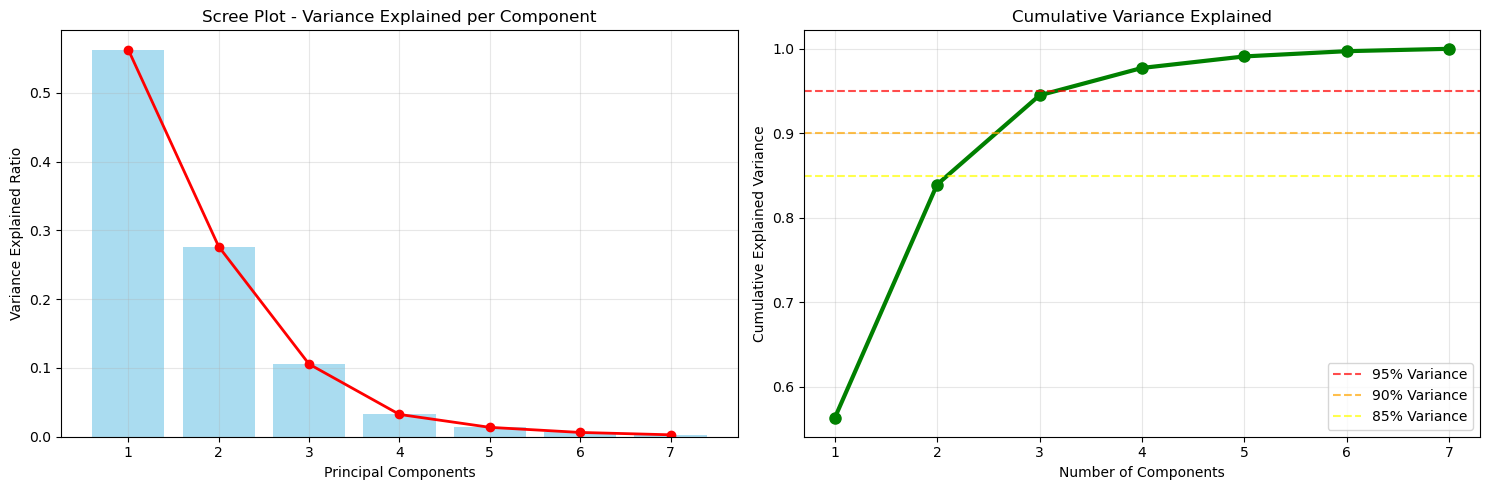


📈 2. LOADING FACTORS UNTUK 7 KOMPONEN UTAMA:

   🔍 PC1 - Top 5 Positive Loadings:
      R_150          :  0.4698
      R_100          :  0.4410
      R_200          :  0.4375
      G_150          : -0.0279
      G_200          : -0.3300
   🔍 PC1 - Top 5 Negative Loadings:
      R_200          :  0.4375
      G_150          : -0.0279
      G_200          : -0.3300
      B_200          : -0.3750
      B_150          : -0.3783

   🔍 PC2 - Top 5 Positive Loadings:
      G_150          :  0.6660
      G_200          :  0.4950
      R_150          :  0.0594
      R_200          :  0.0098
      R_100          : -0.2554
   🔍 PC2 - Top 5 Negative Loadings:
      R_150          :  0.0594
      R_200          :  0.0098
      R_100          : -0.2554
      B_150          : -0.3470
      B_200          : -0.3495

   🔍 PC3 - Top 5 Positive Loadings:
      B_200          :  0.4831
      R_200          :  0.4781
      B_150          :  0.4729
      G_150          :  0.3859
      R_150          :  0.3

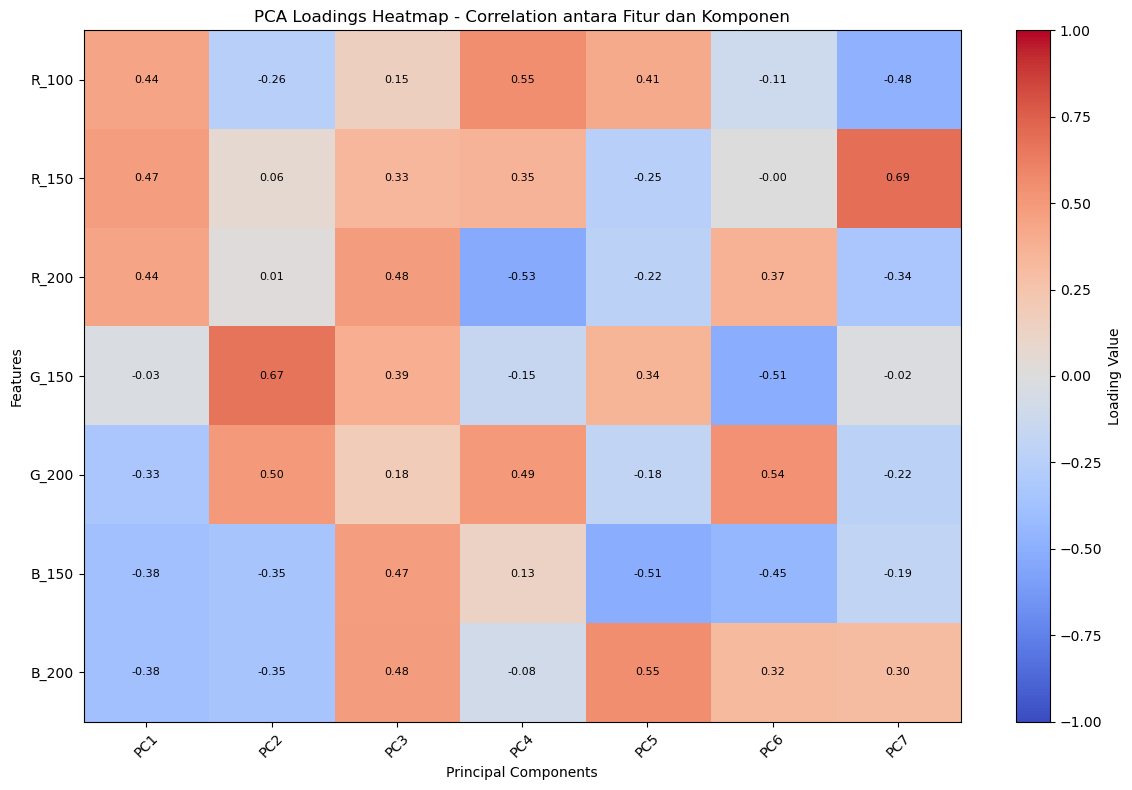

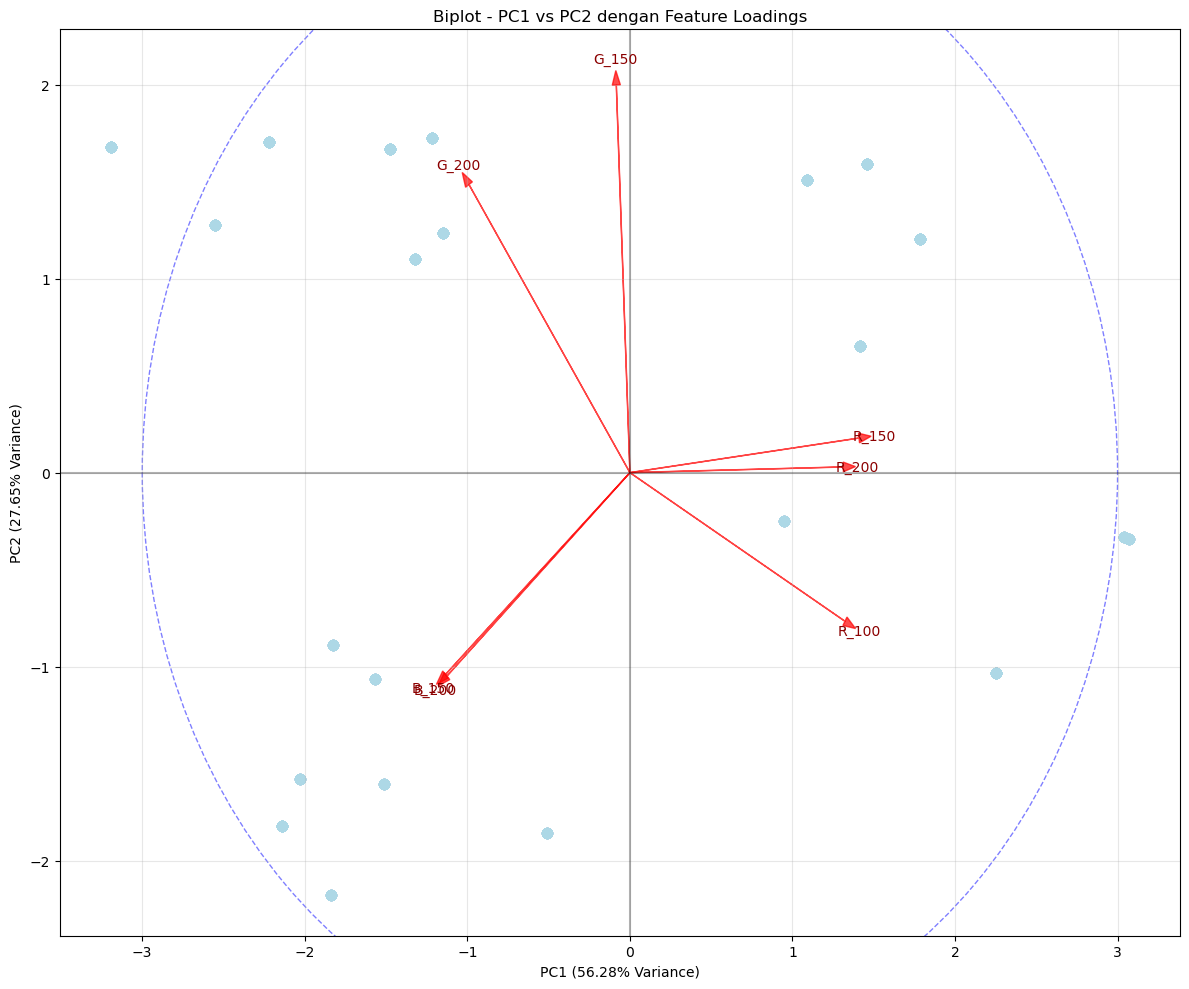

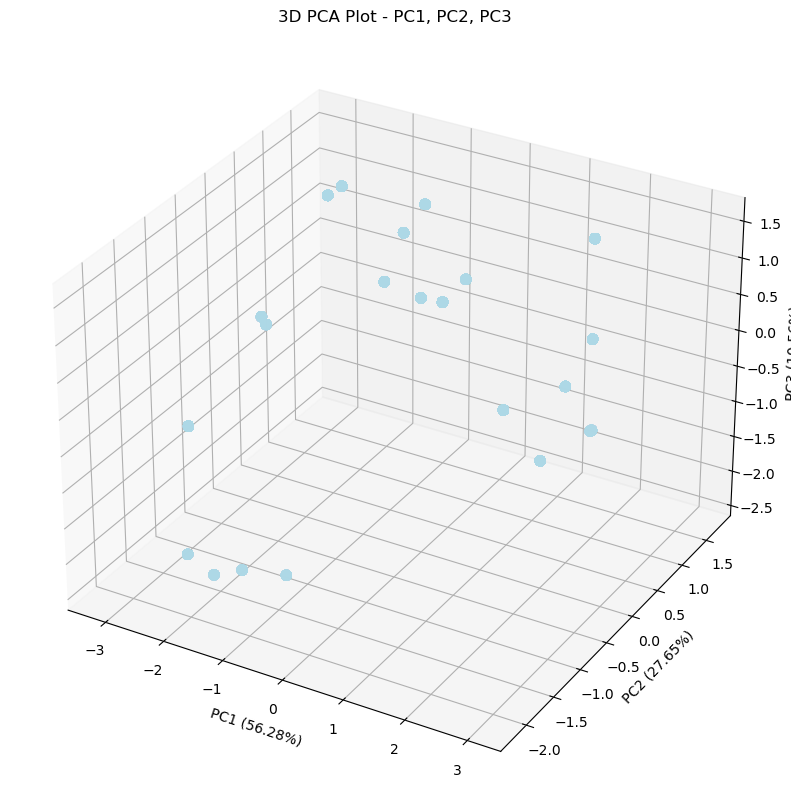


📋 3. RINGKASAN STATISTIK PCA:
   • Total variance explained: 1.0000 (100.00%)
   • Number of components untuk 95% variance: 4
   • Number of components untuk 90% variance: 3
   • Number of components untuk 85% variance: 3

🎯 4. FEATURE IMPORTANCE BERDASARKAN PC1:
   R_150          :  0.4698 ( 19.1%)
   R_100          :  0.4410 ( 17.9%)
   R_200          :  0.4375 ( 17.8%)
   B_150          :  0.3783 ( 15.4%)
   B_200          :  0.3750 ( 15.2%)
   G_200          :  0.3300 ( 13.4%)
   G_150          :  0.0279 (  1.1%)

🔍 DATA UNTUK VISUALISASI CLUSTERING:
   Jumlah total data points: 4400
   Cluster labels unik: ['red' 'pink' 'white' 'yellow']
   Cluster 'red': 1047 points
   Cluster 'pink': 1153 points
   Cluster 'white': 1145 points
   Cluster 'yellow': 1055 points
🎯 MENAMPILKAN 4 CENTROID DI PLOT...
   ✅ Centroid 0: pink di posisi [1.38282115 1.20132734]
   ✅ Centroid 1: red di posisi [-2.00094996  1.46932353]
   ✅ Centroid 2: white di posisi [ 2.26767214 -0.94588802]
   ✅ Centroid 

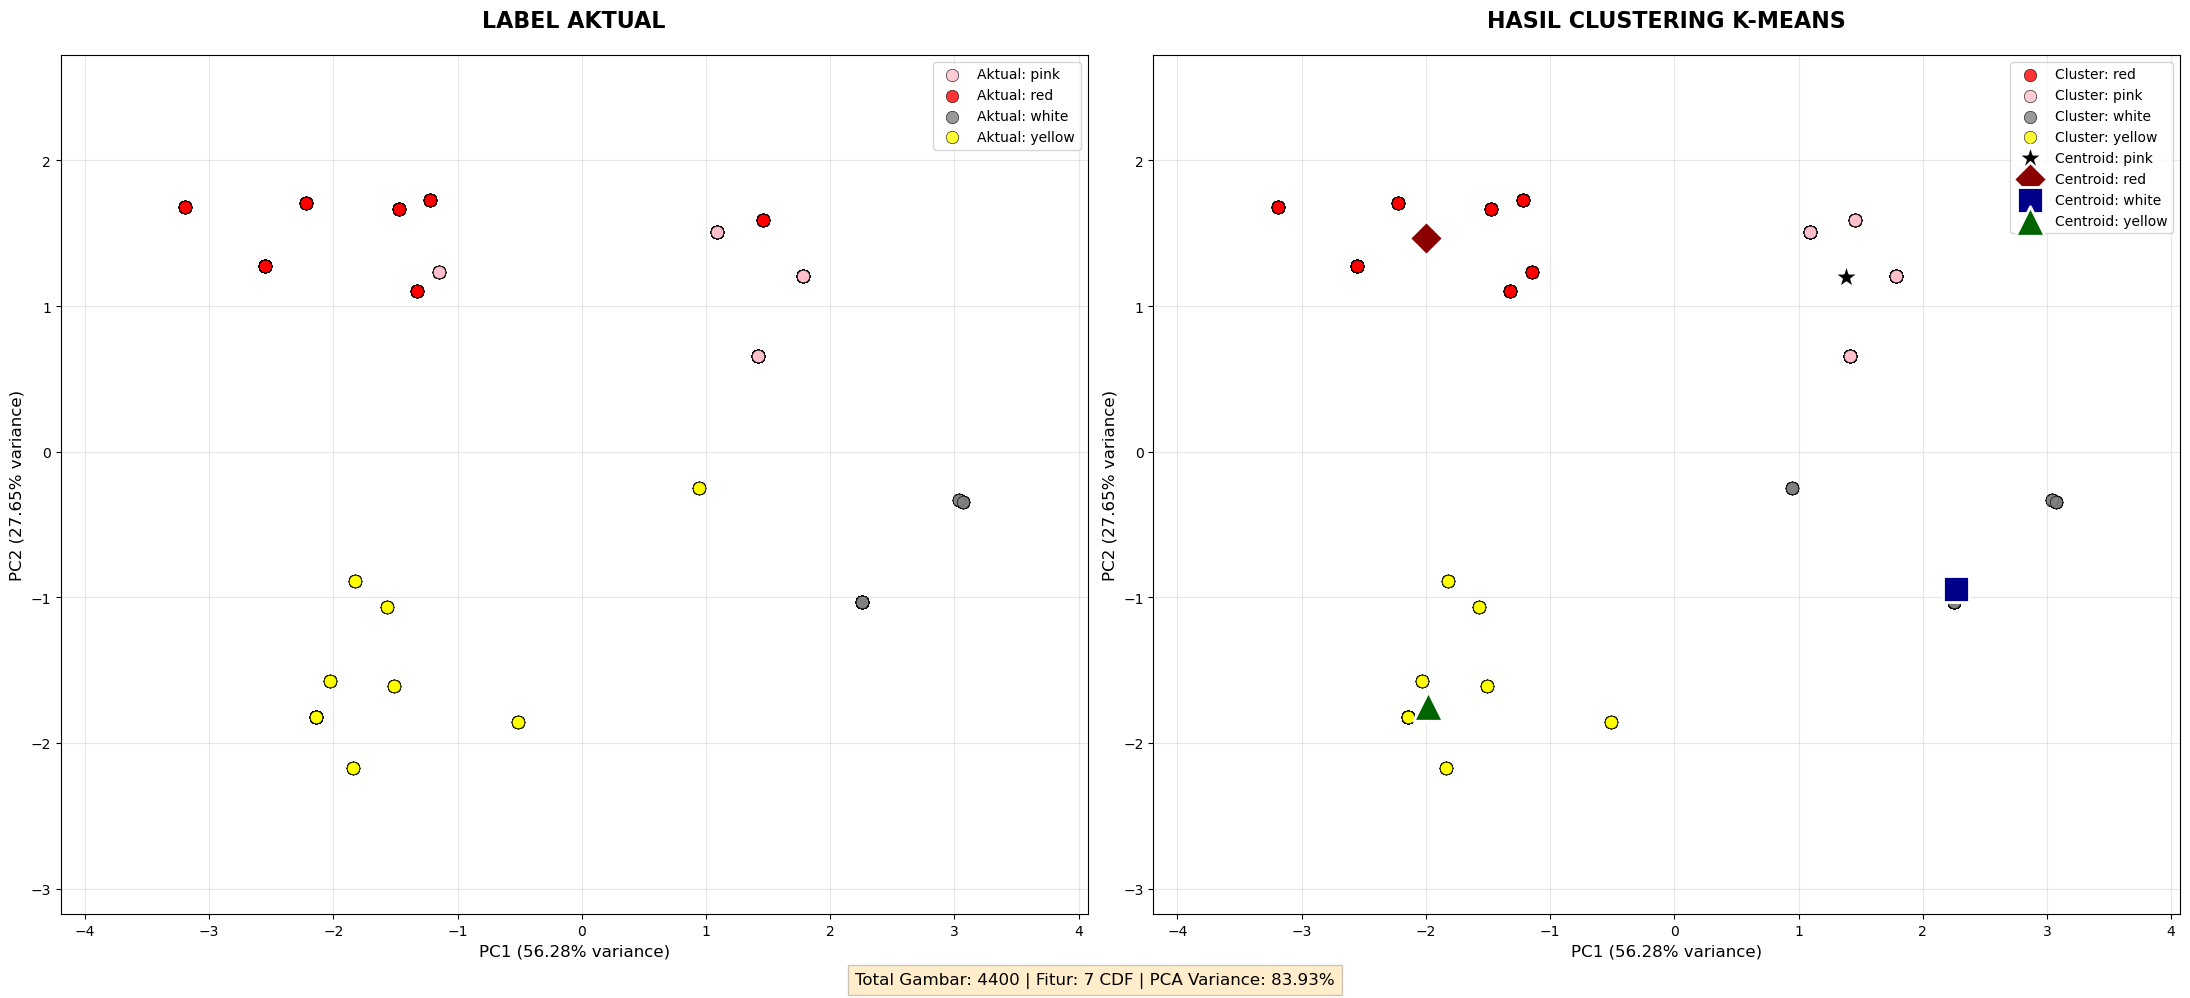


📈 DISTRIBUSI CLUSTER:
   pink: 1153 gambar (26.2%)
   white: 1145 gambar (26.0%)
   yellow: 1055 gambar (24.0%)
   red: 1047 gambar (23.8%)

15. MENYIMPAN HASIL CLUSTERING DAN ANALISIS PCA: C:/Users/Ahsan/Downloads/hasil_clustering_4kelas.xlsx
💾 Hasil clustering dan analisis PCA disimpan ke: C:/Users/Ahsan/Downloads/hasil_clustering_4kelas.xlsx

🎉 PROSES SELESAI UNTUK 4 KELAS MAWAR DENGAN 7 FITUR CDF!
DAN ANALISIS PCA LENGKAP

📊 RINGKASAN HASIL:
   - Total gambar diproses: 4400
   - Jumlah fitur CDF: 7 (R_100, R_150, R_200, G_150, G_200, B_150, B_200)
   - Akurasi clustering: 93.91%
   - Total variance explained oleh 7 komponen PCA: 100.00%
   - Variance explained oleh 2 komponen pertama: 83.93%
   - File output:
     * Data RGB: C:/Users/Ahsan/Downloads/data_ekstraksi_rgb_4kelas.xlsx
     * Data ECDF (CSV): C:/Users/Ahsan/Downloads/data_ecdf_rgb_4kelas.csv
     * Data ECDF Intensitas: C:/Users/Ahsan/Downloads/data_ecdf_intensitas_4kelas.xlsx
     * Data Konversi CDF: C:/Users/Ahsan/D

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =============================================
# KONFIGURASI - 4 FOLDER MAWAR
# =============================================
pink_rose_folder = "C:/Users/Ahsan/Downloads/data/pink_rose"
red_rose_folder = "C:/Users/Ahsan/Downloads/data/red_rose"  
white_rose_folder = "C:/Users/Ahsan/Downloads/data/white_rose"
yellow_rose_folder = "C:/Users/Ahsan/Downloads/data/yellow_rose"

output_excel = "C:/Users/Ahsan/Downloads/data_ekstraksi_rgb_4kelas.xlsx"
ecdf_output_csv = "C:/Users/Ahsan/Downloads/data_ecdf_rgb_4kelas.csv"
ecdf_intensity_output_excel = "C:/Users/Ahsan/Downloads/data_ecdf_intensitas_4kelas.xlsx"
conversion_output_excel = "C:/Users/Ahsan/Downloads/data_ecdf_cdf_konversi_4kelas.xlsx"
clustering_output_excel = "C:/Users/Ahsan/Downloads/hasil_clustering_4kelas.xlsx"

p = 32  # Ukuran resize gambar: p x p

# =============================================
# FUNGSI UTAMA UNTUK MEMPROSES GAMBAR
# =============================================

def process_image(image_path, label, gambar_ke):
    """
    Memproses satu gambar: resize ke p x p, ekstrak RGB, dan simpan ke Excel
    """
    # Baca gambar
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Tidak bisa membaca gambar: {image_path}")
        return None
    
    # Resize gambar menjadi p x p
    img_resized = cv2.resize(img, (p, p))
    
    # Konversi BGR ke RGB
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
    # Ekstrak channel R, G, B
    R = img_rgb[:, :, 0].flatten()
    G = img_rgb[:, :, 1].flatten()
    B = img_rgb[:, :, 2].flatten()
    
    # Hitung statistik
    hasil = {
        'filename': os.path.basename(image_path),
        'gambar_ke': gambar_ke,
        'label': label,
        'p': p,
        'total_pixels': p * p,
        'R_values': R,
        'G_values': G,
        'B_values': B,
        'avg_R': np.mean(R),
        'avg_G': np.mean(G),
        'avg_B': np.mean(B),
        'min_R': np.min(R),
        'max_R': np.max(R),
        'min_G': np.min(G),
        'max_G': np.max(G),
        'min_B': np.min(B),
        'max_B': np.max(B)
    }
    
    return hasil

def process_all_images(folder_path, label):
    """
    Memproses semua gambar dalam folder
    """
    results = []
    
    if not os.path.exists(folder_path):
        print(f"❌ Folder tidak ditemukan: {folder_path}")
        return pd.DataFrame()
    
    image_files = [f for f in os.listdir(folder_path) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not image_files:
        print(f"❌ Tidak ada gambar ditemukan di: {folder_path}")
        return pd.DataFrame()
    
    print(f"📁 Memproses {len(image_files)} gambar dari {folder_path} (label: {label})")
    
    for i, image_file in enumerate(image_files):
        image_path = os.path.join(folder_path, image_file)
        
        result = process_image(image_path, label, i+1)
        if result is not None:
            results.append(result)
    
    # Konversi ke DataFrame
    if results:
        df = pd.DataFrame(results)
        print(f"✅ Berhasil memproses {len(df)} gambar dengan label: {label}")
        return df
    else:
        print(f"❌ Tidak ada hasil yang berhasil diproses dari {folder_path}")
        return pd.DataFrame()

def save_rgb_to_excel(df_rgb, output_path):
    """
    Menyimpan data RGB ke file Excel
    """
    # Buat DataFrame yang lebih sederhana untuk disimpan
    save_data = []
    for _, row in df_rgb.iterrows():
        save_data.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label': row['label'],
            'p': row['p'],
            'total_pixels': row['total_pixels'],
            'R_values': str(row['R_values'].tolist()),
            'G_values': str(row['G_values'].tolist()),
            'B_values': str(row['B_values'].tolist()),
            'avg_R': row['avg_R'],
            'avg_G': row['avg_G'],
            'avg_B': row['avg_B'],
            'min_R': row['min_R'],
            'max_R': row['max_R'],
            'min_G': row['min_G'],
            'max_G': row['max_G'],
            'min_B': row['min_B'],
            'max_B': row['max_B']
        })
    
    df_save = pd.DataFrame(save_data)
    df_save.to_excel(output_path, index=False)
    print(f"💾 Data RGB disimpan ke: {output_path}")

# =============================================
# FUNGSI ECDF - DIPERBAIKI
# =============================================

def calculate_ecdf(values):
    """
    Menghitung ECDF untuk suatu set nilai
    """
    if len(values) == 0:
        return np.array([]), np.array([])
    
    # Urutkan nilai
    sorted_values = np.sort(values)
    
    # Hitung ECDF
    n = len(sorted_values)
    ecdf = np.arange(1, n + 1) / n
    
    return sorted_values, ecdf

def calculate_ecdf_for_image(image_data):
    """
    Menghitung ECDF untuk sebuah gambar
    """
    filename = image_data['filename']
    j = image_data['gambar_ke']
    label = image_data['label']
    p_j = image_data['p']
    
    ecdf_data = {
        'filename': filename,
        'gambar_ke': j,
        'label': label,
        'p_j': p_j,
        'R': {'intensity': [], 'ecdf': []},
        'G': {'intensity': [], 'ecdf': []},
        'B': {'intensity': [], 'ecdf': []}
    }
    
    # Untuk setiap channel R, G, B
    for channel in ['R', 'G', 'B']:
        values = image_data[f'{channel}_values']
        
        if len(values) > 0:
            intensity, ecdf = calculate_ecdf(values)
            ecdf_data[channel]['intensity'] = intensity
            ecdf_data[channel]['ecdf'] = ecdf
    
    return ecdf_data

def calculate_all_ecdf(df_rgb):
    """
    Menghitung ECDF untuk semua gambar
    """
    ecdf_results = {}
    
    for _, row in df_rgb.iterrows():
        ecdf_data = calculate_ecdf_for_image(row)
        ecdf_results[row['filename']] = ecdf_data
    
    return ecdf_results

def save_ecdf_to_csv(ecdf_data, output_path):
    """
    Menyimpan data ECDF ke file CSV (bukan Excel) untuk handle data besar
    """
    save_data = []
    
    for filename, data in ecdf_data.items():
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            if len(channel_data['intensity']) > 0:
                for intensity, ecdf_val in zip(channel_data['intensity'], channel_data['ecdf']):
                    save_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'intensity': intensity,
                        'ecdf': ecdf_val,
                        'p_j': data['p_j']
                    })
    
    df_save = pd.DataFrame(save_data)
    
    # Simpan ke CSV bukan Excel
    df_save.to_csv(output_path, index=False)
    print(f"💾 Data ECDF disimpan ke: {output_path}")
    print(f"📊 Jumlah baris data ECDF: {len(df_save)}")

# =============================================
# FUNGSI EKSTRAKSI ECDF PADA INTENSITAS TERTENTU - DIPERBAIKI
# =============================================

def extract_ecdf_at_intensities(ecdf_data, intensities=[100, 150, 200]):
    """
    Mengekstrak nilai ECDF pada intensitas tertentu untuk setiap gambar dan channel
    """
    ecdf_intensity_data = []
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Untuk setiap intensitas target, cari nilai ECDF-nya
                for intensity in intensities:
                    ecdf_val = 0.0
                    
                    if intensity < intensity_values[0]:
                        ecdf_val = 0.0
                    elif intensity >= intensity_values[-1]:
                        ecdf_val = 1.0
                    else:
                        # Cari di segmen mana intensitas berada
                        for m in range(len(intensity_values) - 1):
                            if intensity_values[m] <= intensity < intensity_values[m + 1]:
                                ecdf_val = ecdf_values[m]
                                break
                        else:
                            # Jika tidak ditemukan dalam loop, gunakan nilai terakhir
                            ecdf_val = ecdf_values[-1] if intensity >= intensity_values[-1] else 0.0
                    
                    ecdf_intensity_data.append({
                        'filename': filename,
                        'gambar_ke': j,
                        'label': label,
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val
                    })
    
    df_ecdf_intensities = pd.DataFrame(ecdf_intensity_data)
    return df_ecdf_intensities

# =============================================
# FUNGSI MODEL MATEMATIS V DENGAN 7 FITUR - DIPERBAIKI
# =============================================

def calculate_cdf_for_all_ecdf_intensities(df_ecdf_intensities):
    """
    Menghitung CDF untuk semua nilai ECDF pada intensitas tertentu
    Menghasilkan 7 fitur: R_100, R_150, R_200, G_150, G_200, B_150, B_200
    """
    cdf_data = []
    
    # Definisikan 7 kombinasi channel dan intensitas yang akan digunakan
    combinations = [
        ('R', 100), ('R', 150), ('R', 200),
        ('G', 150), ('G', 200),
        ('B', 150), ('B', 200)
    ]
    
    for channel, intensity in combinations:
        # Ambil nilai ECDF untuk kombinasi channel dan intensitas tertentu
        ecdf_values = df_ecdf_intensities[
            (df_ecdf_intensities['channel'] == channel) & 
            (df_ecdf_intensities['intensity_target'] == intensity)
        ]['ecdf_value'].values
        
        if len(ecdf_values) > 0:
            # Urutkan nilai ECDF
            sorted_ecdf = np.sort(ecdf_values)
            
            # Hitung CDF
            cdf_values = np.arange(1, len(sorted_ecdf) + 1) / len(sorted_ecdf)
            
            # Simpan data
            for ecdf_val, cdf_val in zip(sorted_ecdf, cdf_values):
                cdf_data.append({
                    'channel': channel,
                    'intensity_target': intensity,
                    'ecdf_value': ecdf_val,
                    'cdf_value': cdf_val
                })
    
    df_cdf = pd.DataFrame(cdf_data)
    return df_cdf

def create_mathematical_model_V_7features(df_cdf):
    """
    Membuat model matematis V dari data CDF intensitas dengan 7 fitur
    """
    model_V = {}
    
    # 7 kombinasi channel dan intensitas
    combinations = [
        ('R', 100), ('R', 150), ('R', 200),
        ('G', 150), ('G', 200),
        ('B', 150), ('B', 200)
    ]
    
    for channel, intensity in combinations:
        model_key = f'{channel}_{intensity}'
        channel_data = df_cdf[(df_cdf['channel'] == channel) & (df_cdf['intensity_target'] == intensity)]
        
        if not channel_data.empty:
            model_V[model_key] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
            print(f"   ✅ Model untuk {model_key}: {len(channel_data)} data points")
        else:
            print(f"   ❌ Tidak ada data untuk {model_key}")
    
    print("✅ Model matematis V dengan 7 fitur berhasil dibuat")
    print(f"🔧 Komponen model V: {list(model_V.keys())}")
    
    return model_V

def convert_ecdf_to_cdf_with_model_V(ecdf_value, model_key, model_V):
    """
    Mengkonversi nilai ECDF ke CDF menggunakan model matematis V
    """
    if model_key not in model_V:
        return None
    
    model_data = model_V[model_key]
    ecdf_values = model_data['ecdf_values']
    cdf_values = model_data['cdf_values']
    
    # Jika ECDF value di luar range model, return None
    if ecdf_value < ecdf_values[0] or ecdf_value > ecdf_values[-1]:
        return None
    
    # Cari posisi ECDF value dalam model
    idx = np.searchsorted(ecdf_values, ecdf_value, side='right') - 1
    
    # Return CDF value yang sesuai
    return cdf_values[idx]

def extract_and_convert_ecdf_data_7features(ecdf_data, model_V):
    """
    Mengekstrak ECDF dari gambar pada 7 intensitas tertentu dan mengkonversinya ke CDF menggunakan model V
    """
    conversion_results = []
    
    # 7 kombinasi channel dan intensitas
    combinations = [
        ('R', 100), ('R', 150), ('R', 200),
        ('G', 150), ('G', 200),
        ('B', 150), ('B', 200)
    ]
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        # Ekstrak ECDF pada 7 intensitas tertentu untuk semua channel
        for channel, intensity in combinations:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Tentukan model_key berdasarkan channel dan intensitas
                model_key = f'{channel}_{intensity}'
                
                # Skip jika model_key tidak ada di model_V
                if model_key not in model_V:
                    continue
                
                # Cari nilai ECDF pada intensitas target
                ecdf_val = 0.0
                for m in range(len(intensity_values)):
                    if intensity < intensity_values[0]:
                        ecdf_val = 0.0
                        break
                    elif intensity >= intensity_values[m]:
                        if m == len(intensity_values) - 1 or intensity < intensity_values[m + 1]:
                            ecdf_val = ecdf_values[m]
                            break
                    elif intensity >= intensity_values[-1]:
                        ecdf_val = 1.0
                        break
                
                # Konversi ECDF ke CDF menggunakan model V
                cdf_val = convert_ecdf_to_cdf_with_model_V(ecdf_val, model_key, model_V)
                
                conversion_results.append({
                    'filename': filename,
                    'gambar_ke': j,
                    'label': label,
                    'channel': channel,
                    'intensity_target': intensity,
                    'ecdf_value': ecdf_val,
                    'cdf_value': cdf_val,
                    'model_key': model_key
                })
    
    df_conversion = pd.DataFrame(conversion_results)
    return df_conversion

def save_conversion_data(ecdf_data, df_conversion, output_path):
    """
    Menyimpan data ECDF gambar dan CDF hasil konversi ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data konversi ECDF ke CDF (data kecil)
        df_conversion.to_excel(writer, sheet_name='Konversi_ECDF_ke_CDF', index=False)
        
        # Sheet 2: Ringkasan ECDF per gambar (data lebih kecil)
        summary_data = []
        for filename, data in ecdf_data.items():
            for channel in ['R', 'G', 'B']:
                channel_data = data[channel]
                if len(channel_data['intensity']) > 0:
                    summary_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'num_points': len(channel_data['intensity']),
                        'min_intensity': min(channel_data['intensity']),
                        'max_intensity': max(channel_data['intensity']),
                        'min_ecdf': min(channel_data['ecdf']),
                        'max_ecdf': max(channel_data['ecdf'])
                    })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Ringkasan_ECDF', index=False)
    
    print(f"💾 Data konversi CDF disimpan ke: {output_path}")

def save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, output_path):
    """
    Menyimpan data ECDF pada intensitas tertentu dan CDF-nya ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data ECDF pada intensitas tertentu
        df_ecdf_intensities.to_excel(writer, sheet_name='ECDF_Intensitas', index=False)
        
        # Sheet 2: Data CDF dari ECDF intensitas
        df_cdf.to_excel(writer, sheet_name='CDF_ECDF_Intensitas', index=False)
    
    print(f"💾 Data ECDF intensitas dan CDF disimpan ke: {output_path}")

# =============================================
# FUNGSI K-MEANS CLUSTERING DENGAN 7 FITUR - DIPERBAIKI
# =============================================

def prepare_features_for_clustering_7features(df_conversion):
    """
    Menyiapkan fitur untuk clustering dari data CDF hasil konversi dengan 7 fitur
    """
    # Group by filename untuk mendapatkan semua fitur CDF per gambar
    features_data = []
    
    for filename in df_conversion['filename'].unique():
        file_data = df_conversion[df_conversion['filename'] == filename]
        
        # Ekstrak semua nilai CDF untuk gambar ini (7 fitur)
        feature_vector = {}
        feature_vector['filename'] = filename
        feature_vector['gambar_ke'] = file_data['gambar_ke'].iloc[0]
        feature_vector['label'] = file_data['label'].iloc[0]
        
        # Untuk setiap kombinasi channel dan intensitas (7 fitur)
        combinations = [
            ('R', 100), ('R', 150), ('R', 200),
            ('G', 150), ('G', 200),
            ('B', 150), ('B', 200)
        ]
        
        for channel, intensity in combinations:
            key = f"{channel}_{intensity}"
            # Cari nilai CDF untuk kombinasi ini
            matching_rows = file_data[
                (file_data['channel'] == channel) & 
                (file_data['intensity_target'] == intensity)
            ]
            
            if not matching_rows.empty:
                feature_vector[key] = matching_rows['cdf_value'].iloc[0]
            else:
                feature_vector[key] = 0.0  # Default value jika tidak ada
        
        features_data.append(feature_vector)
    
    df_features = pd.DataFrame(features_data)
    
    # DEBUG: Tampilkan informasi tentang fitur
    print(f"🔍 Jumlah gambar untuk clustering: {len(df_features)}")
    print(f"🔍 Jumlah fitur per gambar: {len([col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']])}")
    print(f"🔍 Fitur yang digunakan: {[col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']]}")
    
    # Fill NaN values dengan 0
    df_features = df_features.fillna(0)
    
    return df_features

def perform_kmeans_clustering_7features(df_features):
    """
    Melakukan K-means clustering dengan 4 centroid berdasarkan 7 fitur CDF
    """
    print(f"\n🔍 Menyiapkan clustering dengan {len(df_features)} gambar dan 7 fitur")
    
    # Filter hanya kolom fitur (exclude metadata)
    feature_columns = [col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']]
    
    # Pastikan semua fitur columns ada
    if len(feature_columns) == 0:
        print("❌ Tidak ada fitur yang ditemukan untuk clustering!")
        return None, None, None, []
    
    # DEBUG: Print informasi fitur
    print(f"🔍 Jumlah fitur: {len(feature_columns)}")
    print(f"🔍 Fitur: {feature_columns}")
    print(f"🔍 Shape data: {df_features[feature_columns].shape}")
    
    # Ekstrak matriks fitur
    X = df_features[feature_columns].values
    
    # Hitung centroid untuk setiap kelas
    centroids_dict = {}
    
    actual_labels = df_features['label'].unique()
    print(f"🔍 Label unik yang ditemukan: {actual_labels}")
    
    for label in actual_labels:
        class_data = df_features[df_features['label'] == label]
        if len(class_data) > 0:
            # Hitung rata-rata untuk setiap fitur
            centroid_values = class_data[feature_columns].mean(axis=0).values
            centroids_dict[label] = centroid_values
            print(f"✅ Centroid untuk kelas '{label}': {len(class_data)} gambar")
        else:
            print(f"❌ Tidak ada gambar untuk kelas '{label}'")
    
    if len(centroids_dict) < 2:
        print(f"⚠️  Hanya {len(centroids_dict)} kelas yang memiliki centroid! Menggunakan K-means standar...")
        kmeans = KMeans(n_clusters=min(4, len(df_features)), random_state=42)
        labels = kmeans.fit_predict(X)
        centroids = kmeans.cluster_centers_
    else:
        # Siapkan initial centroids dari rata-rata kelas
        initial_centroids = np.array(list(centroids_dict.values()))
        
        print(f"📍 Shape initial centroids: {initial_centroids.shape}")
        print(f"🎯 Kelas yang digunakan: {list(centroids_dict.keys())}")
        
        # Gunakan jumlah cluster yang sesuai dengan data yang ada
        n_clusters = min(4, len(initial_centroids), len(df_features))
        
        try:
            # Lakukan K-means dengan inisialisasi centroid spesifik
            kmeans = KMeans(
                n_clusters=n_clusters,
                init=initial_centroids[:n_clusters],  # Hanya ambil sebanyak n_clusters
                n_init=1,
                max_iter=300,
                random_state=42
            )
            
            labels = kmeans.fit_predict(X)
            centroids = kmeans.cluster_centers_
            print(f"✅ K-means clustering dengan {n_clusters} cluster berhasil!")
            
        except Exception as e:
            print(f"❌ Error dalam K-means: {e}")
            print("🔄 Menggunakan K-means standar...")
            kmeans = KMeans(n_clusters=min(4, len(df_features)), random_state=42)
            labels = kmeans.fit_predict(X)
            centroids = kmeans.cluster_centers_
    
    # Tambahkan hasil clustering ke DataFrame
    df_features = df_features.copy()
    df_features['cluster'] = labels
    
    try:
        df_features['distance_to_centroid'] = kmeans.transform(X).min(axis=1)
    except:
        df_features['distance_to_centroid'] = 0.0
    
    # Mapping cluster ke label berdasarkan centroid terdekat
    cluster_mapping = {}
    
    # Untuk setiap cluster, cari centroid kelas mana yang paling dekat
    for cluster_idx in range(len(np.unique(labels))):
        if cluster_idx < len(centroids):  # Pastikan cluster_idx valid
            cluster_center = centroids[cluster_idx]
            
            # Hitung jarak ke setiap centroid kelas
            distances = {}
            for label, class_centroid in centroids_dict.items():
                distance = np.linalg.norm(cluster_center - class_centroid)
                distances[label] = distance
            
            # Pilih label dengan jarak terdekat
            if distances:  # Pastikan distances tidak kosong
                closest_label = min(distances, key=distances.get)
                cluster_mapping[cluster_idx] = closest_label
            else:
                cluster_mapping[cluster_idx] = f'cluster_{cluster_idx}'
    
    print(f"🔀 Mapping cluster: {cluster_mapping}")
    
    df_features['cluster_label'] = df_features['cluster'].map(cluster_mapping)
    
    # Simpan informasi centroid yang digunakan
    centroid_info = []
    for cluster_idx in range(len(np.unique(labels))):
        if cluster_idx in cluster_mapping:
            label = cluster_mapping[cluster_idx]
            centroid_values = centroids[cluster_idx] if cluster_idx < len(centroids) else None
            centroid_info.append({
                'cluster': cluster_idx,
                'cluster_label': label,
                'centroid_values': centroid_values
            })
    
    return df_features, kmeans, feature_columns, centroid_info

def analyze_clustering_results_4classes(df_features, df_conversion, centroid_info):
    """
    Menganalisis dan menampilkan hasil clustering untuk 4 kelas
    """
    print("\n" + "="*80)
    print("HASIL K-MEANS CLUSTERING - 7 FITUR")
    print("="*80)
    
    # Tampilkan informasi centroid
    print("\n🎯 INFORMASI CENTROID:")
    for i, centroid in enumerate(centroid_info):
        print(f"   Cluster {centroid['cluster']}: {centroid['cluster_label']}")
    
    # Hitung akurasi clustering
    correct_predictions = 0
    total_predictions = len(df_features)
    
    clustering_results = []
    
    for _, row in df_features.iterrows():
        actual_label = row['label']
        predicted_label = row['cluster_label']
        is_correct = (actual_label == predicted_label)
        
        if is_correct:
            correct_predictions += 1
        
        clustering_results.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label_aktual': actual_label,
            'cluster_prediksi': row['cluster'],
            'label_prediksi': predicted_label,
            'benar': is_correct,
            'jarak_ke_centroid': row['distance_to_centroid']
        })
    
    accuracy = correct_predictions / total_predictions * 100 if total_predictions > 0 else 0
    
    print(f"\n📈 AKURASI CLUSTERING: {accuracy:.2f}%")
    print(f"   Benar: {correct_predictions}/{total_predictions}")
    
    # Tampilkan confusion matrix sederhana
    print("\n📊 CONFUSION MATRIX:")
    df_results = pd.DataFrame(clustering_results)
    if not df_results.empty:
        confusion_matrix = pd.crosstab(df_results['label_aktual'], df_results['label_prediksi'])
        print(confusion_matrix)
    
    return df_results, accuracy

def plot_clustering_results_4classes_improved(df_features, feature_columns, centroid_info):
    """
    Membuat visualisasi hasil clustering untuk 4 kelas dengan 7 fitur
    """
    print("\n" + "="*80)
    print("VISUALISASI HASIL CLUSTERING - 7 FITUR")
    print("="*80)
    
    # Standardisasi fitur
    X = df_features[feature_columns].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Reduksi dimensi dengan PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Hitung batas yang sama untuk kedua plot
    x_min = min(X_pca[:, 0]) - 1
    x_max = max(X_pca[:, 0]) + 1
    y_min = min(X_pca[:, 1]) - 1
    y_max = max(X_pca[:, 1]) + 1
    
    # Buat plot dengan ukuran yang lebih besar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    
    # Warna untuk plot
    colors = {'pink': 'pink', 'red': 'red', 'white': 'gray', 'yellow': 'yellow'}
    
    # Plot 1: Label aktual
    actual_labels = df_features['label'].unique()
    for label in actual_labels:
        mask = df_features['label'] == label
        color = colors.get(label, 'blue')
        if mask.any():
            ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Aktual: {label}', s=80, alpha=0.8, 
                       edgecolors='black', linewidth=0.5)
    
    ax1.set_title('LABEL AKTUAL', 
                  fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    
    # Plot 2: Hasil clustering
    cluster_labels = df_features['cluster_label'].unique()
    
    # DEBUG: Print informasi tentang data clustering
    print(f"\n🔍 DEBUG - Data untuk visualisasi clustering:")
    print(f"   Jumlah total data points: {len(X_pca)}")
    print(f"   Cluster labels unik: {cluster_labels}")
    
    for cluster_label in cluster_labels:
        mask = df_features['cluster_label'] == cluster_label
        color = colors.get(cluster_label, 'blue')
        
        # DEBUG: Print jumlah points per cluster
        cluster_count = mask.sum()
        print(f"   Cluster '{cluster_label}': {cluster_count} points")
        
        if mask.any():
            ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Cluster: {cluster_label}', s=80, alpha=0.8, 
                       edgecolors='black', linewidth=0.5)
    
    # Tandai centroid dengan spesial marker
    print(f"🎯 Menampilkan {len(centroid_info)} centroid di plot...")
    centroid_markers = ['*', 'D', 's', '^']
    centroid_sizes = [400, 300, 350, 450]
    centroid_colors = ['black', 'darkred', 'darkblue', 'darkgreen']
    
    # Plot centroid (gunakan PCA transform dari centroid asli)
    for idx, centroid in enumerate(centroid_info):
        if centroid['centroid_values'] is not None:
            try:
                # Transform centroid ke ruang PCA
                centroid_scaled = scaler.transform([centroid['centroid_values']])
                centroid_pca = pca.transform(centroid_scaled)[0]
                
                marker = centroid_markers[idx % len(centroid_markers)]
                size = centroid_sizes[idx % len(centroid_sizes)]
                color = centroid_colors[idx % len(centroid_colors)]
                
                ax2.scatter(centroid_pca[0], centroid_pca[1], 
                           c=color, marker=marker, s=size,
                           label=f"Centroid: {centroid['cluster_label']}",
                           edgecolors='white', linewidth=2, zorder=5)
                
                print(f"   ✅ Centroid {idx}: {centroid['cluster_label']} di posisi {centroid_pca}")
            except Exception as e:
                print(f"   ❌ Error plotting centroid {idx}: {e}")
    
    ax2.set_title('HASIL CLUSTERING K-MEANS', 
                  fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    
    # Tambahkan informasi tambahan
    plt.figtext(0.5, 0.01, 
                f"Total Gambar: {len(df_features)} | Fitur: 7 CDF | PCA Variance: {sum(pca.explained_variance_ratio_):.2%}",
                ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.show()
    
    # Print variance explained oleh PCA
    print(f"\n📊 Variance yang dijelaskan oleh PCA:")
    print(f"   PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]:.2%})")
    print(f"   PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]:.2%})")
    print(f"   Total: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_):.2%})")
    
    # Print distribusi cluster
    print(f"\n📈 DISTRIBUSI CLUSTER:")
    cluster_dist = df_features['cluster_label'].value_counts()
    for cluster, count in cluster_dist.items():
        print(f"   {cluster}: {count} gambar ({count/len(df_features)*100:.1f}%)")

def save_clustering_results(df_features, df_results, accuracy, output_path):
    """
    Menyimpan hasil clustering ke file Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Fitur dan hasil clustering
        df_features.to_excel(writer, sheet_name='Fitur_dan_Clustering', index=False)
        
        # Sheet 2: Ringkasan hasil
        df_results.to_excel(writer, sheet_name='Hasil_Clustering', index=False)
        
        # Sheet 3: Statistik clustering
        accuracy_data = [{
            'total_gambar': len(df_features),
            'benar': len(df_results[df_results['benar'] == True]),
            'salah': len(df_results[df_results['benar'] == False]),
            'akurasi': accuracy
        }]
        df_accuracy = pd.DataFrame(accuracy_data)
        df_accuracy.to_excel(writer, sheet_name='Statistik', index=False)
    
    print(f"💾 Hasil clustering disimpan ke: {output_path}")


def detailed_pca_analysis(X, feature_names, n_components=7):
    """
    Melakukan analisis PCA yang lebih detail dan menyeluruh
    """
    print("\n" + "="*80)
    print("ANALISIS PCA DETAIL - 7 KOMPONEN UTAMA")
    print("="*80)
    
    # Standardisasi data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Lakukan PCA untuk semua komponen
    pca_full = PCA(n_components=n_components)
    X_pca_full = pca_full.fit_transform(X_scaled)
    
    # 1. Variance Explained Analysis
    print("\n📊 1. ANALISIS VARIANCE EXPLAINED:")
    print("   Komponen | Variance Explained | Cumulative Variance")
    print("   " + "-" * 50)
    
    cumulative_variance = 0
    for i, var in enumerate(pca_full.explained_variance_ratio_):
        cumulative_variance += var
        print(f"   PC{i+1:2}     | {var:6.4f} ({var:6.2%})     | {cumulative_variance:6.4f} ({cumulative_variance:6.2%})")
    
    # 2. Scree Plot
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    components = range(1, len(pca_full.explained_variance_ratio_) + 1)
    plt.bar(components, pca_full.explained_variance_ratio_, alpha=0.7, color='skyblue')
    plt.plot(components, pca_full.explained_variance_ratio_, 'ro-', linewidth=2)
    plt.xlabel('Principal Components')
    plt.ylabel('Variance Explained Ratio')
    plt.title('Scree Plot - Variance Explained per Component')
    plt.grid(True, alpha=0.3)
    
    # Cumulative variance plot
    plt.subplot(1, 2, 2)
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
    plt.plot(components, cumulative_variance, 'go-', linewidth=3, markersize=8)
    plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% Variance')
    plt.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% Variance')
    plt.axhline(y=0.85, color='yellow', linestyle='--', alpha=0.7, label='85% Variance')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Cumulative Variance Explained')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Component Loadings Analysis
    print(f"\n📈 2. LOADING FACTORS UNTUK {n_components} KOMPONEN UTAMA:")
    
    # Buat DataFrame untuk loadings
    loadings_df = pd.DataFrame(
        pca_full.components_.T,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=feature_names
    )
    
    # Tampilkan loadings untuk setiap PC
    for i in range(min(3, n_components)):  # Tampilkan 3 PC pertama secara detail
        print(f"\n   🔍 PC{i+1} - Top 5 Positive Loadings:")
        pc_loadings = loadings_df[f'PC{i+1}'].sort_values(ascending=False)
        for feature, loading in pc_loadings.head().items():
            print(f"      {feature:15}: {loading:7.4f}")
        
        print(f"   🔍 PC{i+1} - Top 5 Negative Loadings:")
        for feature, loading in pc_loadings.tail().items():
            print(f"      {feature:15}: {loading:7.4f}")
    
    # 4. Heatmap untuk loadings
    plt.figure(figsize=(12, 8))
    im = plt.imshow(loadings_df.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    plt.colorbar(im, label='Loading Value')
    plt.xticks(range(len(loadings_df.columns)), loadings_df.columns, rotation=45)
    plt.yticks(range(len(loadings_df.index)), loadings_df.index)
    plt.title('PCA Loadings Heatmap - Correlation antara Fitur dan Komponen')
    plt.xlabel('Principal Components')
    plt.ylabel('Features')
    
    # Tambahkan nilai di heatmap
    for i in range(len(loadings_df.index)):
        for j in range(len(loadings_df.columns)):
            plt.text(j, i, f'{loadings_df.iloc[i, j]:.2f}', 
                    ha="center", va="center", color="black", fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Biplot (PC1 vs PC2 dengan loadings)
    plt.figure(figsize=(12, 10))
    
    # Plot data points
    scatter = plt.scatter(X_pca_full[:, 0], X_pca_full[:, 1], alpha=0.6, c='lightblue', s=50)
    
    # Plot loadings sebagai arrows
    for i, feature in enumerate(feature_names):
        plt.arrow(0, 0, 
                 pca_full.components_[0, i] * 3,  # Scale factor untuk visibility
                 pca_full.components_[1, i] * 3,
                 color='red', alpha=0.7, head_width=0.05)
        plt.text(pca_full.components_[0, i] * 3.2, 
                pca_full.components_[1, i] * 3.2, 
                feature, color='darkred', fontsize=10, ha='center', va='center')
    
    plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%} Variance)')
    plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%} Variance)')
    plt.title('Biplot - PC1 vs PC2 dengan Feature Loadings')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    # Add circle
    circle = plt.Circle((0, 0), 3, color='blue', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_artist(circle)
    
    plt.tight_layout()
    plt.show()
    
    # 6. 3D Plot jika memungkinkan
    if n_components >= 3:
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        scatter = ax.scatter(X_pca_full[:, 0], X_pca_full[:, 1], X_pca_full[:, 2], 
                           alpha=0.6, s=50, c='lightblue')
        
        ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%})')
        ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%})')
        ax.set_zlabel(f'PC3 ({pca_full.explained_variance_ratio_[2]:.2%})')
        ax.set_title('3D PCA Plot - PC1, PC2, PC3')
        
        plt.show()
    
    # 7. Summary statistics
    print(f"\n📋 3. RINGKASAN STATISTIK PCA:")
    print(f"   • Total variance explained: {sum(pca_full.explained_variance_ratio_):.4f} ({sum(pca_full.explained_variance_ratio_):.2%})")
    print(f"   • Number of components untuk 95% variance: {np.where(cumulative_variance >= 0.95)[0][0] + 1}")
    print(f"   • Number of components untuk 90% variance: {np.where(cumulative_variance >= 0.90)[0][0] + 1}")
    print(f"   • Number of components untuk 85% variance: {np.where(cumulative_variance >= 0.85)[0][0] + 1}")
    
    # 8. Feature importance berdasarkan PC1 (komponen paling penting)
    print(f"\n🎯 4. FEATURE IMPORTANCE BERDASARKAN PC1:")
    pc1_loadings = loadings_df['PC1'].abs().sort_values(ascending=False)
    for feature, loading in pc1_loadings.items():
        importance = loading / pc1_loadings.sum() * 100
        print(f"   {feature:15}: {loading:7.4f} ({importance:5.1f}%)")
    
    return pca_full, X_pca_full, loadings_df

# =============================================
# FUNGSI VISUALISASI CLUSTERING DENGAN ANALISIS PCA
# =============================================

def plot_clustering_results_with_pca_analysis(df_features, feature_columns, centroid_info):
    """
    Membuat visualisasi hasil clustering dengan analisis PCA yang komprehensif
    """
    print("\n" + "="*80)
    print("VISUALISASI HASIL CLUSTERING DENGAN ANALISIS PCA - 7 FITUR")
    print("="*80)
    
    # Standardisasi fitur
    X = df_features[feature_columns].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Analisis PCA detail
    pca_full, X_pca_full, loadings_df = detailed_pca_analysis(X, feature_columns, n_components=7)
    
    # Untuk visualisasi clustering, gunakan 2 komponen pertama
    X_pca = X_pca_full[:, :2]
    
    # Hitung batas yang sama untuk kedua plot
    x_min = min(X_pca[:, 0]) - 1
    x_max = max(X_pca[:, 0]) + 1
    y_min = min(X_pca[:, 1]) - 1
    y_max = max(X_pca[:, 1]) + 1
    
    # Buat plot dengan ukuran yang lebih besar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    
    # Warna untuk plot
    colors = {'pink': 'pink', 'red': 'red', 'white': 'gray', 'yellow': 'yellow'}
    
    # Plot 1: Label aktual
    actual_labels = df_features['label'].unique()
    for label in actual_labels:
        mask = df_features['label'] == label
        color = colors.get(label, 'blue')
        if mask.any():
            ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Aktual: {label}', s=80, alpha=0.8, 
                       edgecolors='black', linewidth=0.5)
    
    ax1.set_title('LABEL AKTUAL', 
                  fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    ax1.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    
    # Plot 2: Hasil clustering
    cluster_labels = df_features['cluster_label'].unique()
    
    print(f"\n🔍 DATA UNTUK VISUALISASI CLUSTERING:")
    print(f"   Jumlah total data points: {len(X_pca)}")
    print(f"   Cluster labels unik: {cluster_labels}")
    
    for cluster_label in cluster_labels:
        mask = df_features['cluster_label'] == cluster_label
        color = colors.get(cluster_label, 'blue')
        
        cluster_count = mask.sum()
        print(f"   Cluster '{cluster_label}': {cluster_count} points")
        
        if mask.any():
            ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Cluster: {cluster_label}', s=80, alpha=0.8, 
                       edgecolors='black', linewidth=0.5)
    
    # Tandai centroid dengan spesial marker
    print(f"🎯 MENAMPILKAN {len(centroid_info)} CENTROID DI PLOT...")
    centroid_markers = ['*', 'D', 's', '^']
    centroid_sizes = [400, 300, 350, 450]
    centroid_colors = ['black', 'darkred', 'darkblue', 'darkgreen']
    
    # Plot centroid (gunakan PCA transform dari centroid asli)
    for idx, centroid in enumerate(centroid_info):
        if centroid['centroid_values'] is not None:
            try:
                # Transform centroid ke ruang PCA
                centroid_scaled = scaler.transform([centroid['centroid_values']])
                centroid_pca = pca_full.transform(centroid_scaled)[0][:2]  # Hanya 2 komponen pertama
                
                marker = centroid_markers[idx % len(centroid_markers)]
                size = centroid_sizes[idx % len(centroid_sizes)]
                color = centroid_colors[idx % len(centroid_colors)]
                
                ax2.scatter(centroid_pca[0], centroid_pca[1], 
                           c=color, marker=marker, s=size,
                           label=f"Centroid: {centroid['cluster_label']}",
                           edgecolors='white', linewidth=2, zorder=5)
                
                print(f"   ✅ Centroid {idx}: {centroid['cluster_label']} di posisi {centroid_pca}")
            except Exception as e:
                print(f"   ❌ Error plotting centroid {idx}: {e}")
    
    ax2.set_title('HASIL CLUSTERING K-MEANS', 
                  fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    ax2.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    
    # Tambahkan informasi tambahan
    plt.figtext(0.5, 0.01, 
                f"Total Gambar: {len(df_features)} | Fitur: 7 CDF | PCA Variance: {sum(pca_full.explained_variance_ratio_[:2]):.2%}",
                ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.show()
    
    # Print distribusi cluster
    print(f"\n📈 DISTRIBUSI CLUSTER:")
    cluster_dist = df_features['cluster_label'].value_counts()
    for cluster, count in cluster_dist.items():
        print(f"   {cluster}: {count} gambar ({count/len(df_features)*100:.1f}%)")
    
    return pca_full, X_pca_full, loadings_df

# =============================================
# FUNGSI UTAMA UNTUK 4 KELAS DENGAN 7 FITUR
# =============================================

def main_4_classes_7features_with_pca():
    """
    Fungsi utama untuk memproses 4 kelas mawar dengan 7 fitur CDF dan analisis PCA lengkap
    """
    print("PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS INTENSITAS - 4 KELAS MAWAR (7 FITUR)")
    print("DENGAN ANALISIS PCA LENGKAP")
    print("=" * 80)
    
    # 1. Proses gambar dari 4 folder
    print("\n1. PROSES GAMBAR DARI 4 FOLDER MAWAR")
    
    print(f"\n📁 Memproses folder: {pink_rose_folder}")
    df_pink = process_all_images(pink_rose_folder, "pink")
    
    print(f"\n📁 Memproses folder: {red_rose_folder}")
    df_red = process_all_images(red_rose_folder, "red")
    
    print(f"\n📁 Memproses folder: {white_rose_folder}")
    df_white = process_all_images(white_rose_folder, "white")
    
    print(f"\n📁 Memproses folder: {yellow_rose_folder}")
    df_yellow = process_all_images(yellow_rose_folder, "yellow")
    
    # 2. Gabungkan semua hasil
    all_dfs = [df_pink, df_red, df_white, df_yellow]
    all_dfs = [df for df in all_dfs if not df.empty]
    
    if not all_dfs:
        print("❌ Tidak ada data yang diproses. Periksa path folder dan file gambar.")
        return
    
    all_df_rgb = pd.concat(all_dfs, ignore_index=True)
    
    print(f"\n📊 Total gambar diproses: {len(all_df_rgb)}")
    print(f"  - Mawar pink: {len(df_pink)}")
    print(f"  - Mawar merah: {len(df_red)}")
    print(f"  - Mawar putih: {len(df_white)}")
    print(f"  - Mawar kuning: {len(df_yellow)}")
    
    # 3. Simpan data RGB ke Excel
    print(f"\n2. MENYIMPAN DATA RGB KE EXCEL: {output_excel}")
    save_rgb_to_excel(all_df_rgb, output_excel)
    
    # 4. Hitung ECDF untuk semua gambar
    print("\n3. MENGHITUNG ECDF UNTUK SEMUA GAMBAR")
    all_ecdf_results = calculate_all_ecdf(all_df_rgb)
    
    # 5. Simpan data ECDF ke CSV
    print(f"\n4. MENYIMPAN DATA ECDF KE CSV: {ecdf_output_csv}")
    save_ecdf_to_csv(all_ecdf_results, ecdf_output_csv)
    
    # 6. Ekstrak nilai ECDF pada intensitas tertentu
    print("\n5. EKSTRAKSI NILAI ECDF PADA INTENSITAS 100, 150, 200")
    df_ecdf_intensities = extract_ecdf_at_intensities(all_ecdf_results)
    
    # 7. Hitung CDF untuk semua nilai ECDF pada intensitas tertentu (7 FITUR)
    print("\n6. MENGHITUNG CDF UNTUK SEMUA NILAI ECDF PADA INTENSITAS TERTENTU (7 FITUR)")
    df_cdf = calculate_cdf_for_all_ecdf_intensities(df_ecdf_intensities)
    
    # 8. Simpan data ECDF intensitas dan CDF
    print(f"\n7. MENYIMPAN DATA ECDF INTENSITAS DAN CDF: {ecdf_intensity_output_excel}")
    save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, ecdf_intensity_output_excel)
    
    # =============================================
    # BAGIAN MODEL MATEMATIS V DENGAN 7 FITUR
    # =============================================
    
    # 9. Membuat model matematis V dari data CDF dengan 7 fitur
    print("\n8. MEMBUAT MODEL MATEMATIS V DARI DATA CDF INTENSITAS (7 FITUR)")
    model_V = create_mathematical_model_V_7features(df_cdf)
    
    # 10. Ekstrak ECDF dari gambar dan konversi ke CDF menggunakan model V (7 fitur)
    print("\n9. EKSTRAKSI ECDF DARI GAMBAR DAN KONVERSI KE CDF MENGGUNAKAN MODEL V (7 FITUR)")
    df_conversion = extract_and_convert_ecdf_data_7features(all_ecdf_results, model_V)
    
    # 11. Simpan data konversi CDF
    print(f"\n10. MENYIMPAN DATA KONVERSI CDF: {conversion_output_excel}")
    save_conversion_data(all_ecdf_results, df_conversion, conversion_output_excel)
    
    # =============================================
    # BAGIAN K-MEANS CLUSTERING DENGAN 7 FITUR DAN ANALISIS PCA
    # =============================================
    
    # 12. Persiapan fitur untuk clustering dari CDF hasil konversi (7 fitur)
    print("\n11. PERSIAPAN FITUR UNTUK CLUSTERING DARI CDF HASIL KONVERSI (7 FITUR)")
    df_features = prepare_features_for_clustering_7features(df_conversion)
    
    if df_features.empty:
        print("❌ Tidak ada fitur yang dapat dipersiapkan untuk clustering!")
        return
    
    print(f"   Jumlah gambar untuk clustering: {len(df_features)}")
    print(f"   Jumlah fitur per gambar: {len([col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']])}")
    
    # 13. Melakukan K-means clustering dengan centroid (7 fitur)
    print("\n12. MELAKUKAN K-MEANS CLUSTERING DENGAN CENTROID (7 FITUR)")
    df_features, kmeans, feature_columns, centroid_info = perform_kmeans_clustering_7features(df_features)
    
    if df_features is None:
        print("❌ Clustering gagal!")
        return
    
    # 14. Analisis hasil clustering
    print("\n13. ANALISIS HASIL CLUSTERING")
    df_results, accuracy = analyze_clustering_results_4classes(df_features, df_conversion, centroid_info)
    
    # 15. Visualisasi hasil clustering DENGAN ANALISIS PCA LENGKAP
    print("\n14. VISUALISASI HASIL CLUSTERING DENGAN ANALISIS PCA LENGKAP")
    pca_full, X_pca_full, loadings_df = plot_clustering_results_with_pca_analysis(df_features, feature_columns, centroid_info)
    
    # 16. Simpan hasil clustering dan analisis PCA
    print(f"\n15. MENYIMPAN HASIL CLUSTERING DAN ANALISIS PCA: {clustering_output_excel}")
    
    with pd.ExcelWriter(clustering_output_excel) as writer:
        # Sheet 1: Fitur dan hasil clustering
        df_features.to_excel(writer, sheet_name='Fitur_dan_Clustering', index=False)
        
        # Sheet 2: Ringkasan hasil
        df_results.to_excel(writer, sheet_name='Hasil_Clustering', index=False)
        
        # Sheet 3: Statistik clustering
        accuracy_data = [{
            'total_gambar': len(df_features),
            'benar': len(df_results[df_results['benar'] == True]),
            'salah': len(df_results[df_results['benar'] == False]),
            'akurasi': accuracy
        }]
        df_accuracy = pd.DataFrame(accuracy_data)
        df_accuracy.to_excel(writer, sheet_name='Statistik', index=False)
        
        # Sheet 4: Loadings PCA
        loadings_df.to_excel(writer, sheet_name='PCA_Loadings', index=True)
        
        # Sheet 5: Variance explained
        variance_data = {
            'Component': [f'PC{i+1}' for i in range(len(pca_full.explained_variance_ratio_))],
            'Variance_Explained': pca_full.explained_variance_ratio_,
            'Cumulative_Variance': np.cumsum(pca_full.explained_variance_ratio_)
        }
        df_variance = pd.DataFrame(variance_data)
        df_variance.to_excel(writer, sheet_name='PCA_Variance', index=False)
    
    print(f"💾 Hasil clustering dan analisis PCA disimpan ke: {clustering_output_excel}")
    
    print("\n" + "="*80)
    print("🎉 PROSES SELESAI UNTUK 4 KELAS MAWAR DENGAN 7 FITUR CDF!")
    print("DAN ANALISIS PCA LENGKAP")
    print("="*80)
    
    # Ringkasan akhir
    print("\n📊 RINGKASAN HASIL:")
    print(f"   - Total gambar diproses: {len(all_df_rgb)}")
    print(f"   - Jumlah fitur CDF: 7 (R_100, R_150, R_200, G_150, G_200, B_150, B_200)")
    print(f"   - Akurasi clustering: {accuracy:.2f}%")
    print(f"   - Total variance explained oleh 7 komponen PCA: {sum(pca_full.explained_variance_ratio_):.2%}")
    print(f"   - Variance explained oleh 2 komponen pertama: {sum(pca_full.explained_variance_ratio_[:2]):.2%}")
    print(f"   - File output:")
    print(f"     * Data RGB: {output_excel}")
    print(f"     * Data ECDF (CSV): {ecdf_output_csv}")
    print(f"     * Data ECDF Intensitas: {ecdf_intensity_output_excel}")
    print(f"     * Data Konversi CDF: {conversion_output_excel}")
    print(f"     * Hasil Clustering & PCA: {clustering_output_excel}")

# Jalankan fungsi utama dengan analisis PCA
if __name__ == "__main__":
    # Jalankan proses utama untuk 4 kelas dengan 7 fitur dan analisis PCA lengkap
    main_4_classes_7features_with_pca()

✅ SHAP berhasil diimport
PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS PCA & SHAP - 4 KELAS MAWAR (7 FITUR)

1. PROSES GAMBAR DARI 4 FOLDER MAWAR

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/pink_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/pink_rose (label: pink)
✅ Berhasil memproses 1100 gambar dengan label: pink

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/red_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/red_rose (label: red)
✅ Berhasil memproses 1100 gambar dengan label: red

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/white_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/white_rose (label: white)
✅ Berhasil memproses 1100 gambar dengan label: white

📁 Memproses folder: C:/Users/Ahsan/Downloads/data/yellow_rose
📁 Memproses 1100 gambar dari C:/Users/Ahsan/Downloads/data/yellow_rose (label: yellow)
✅ Berhasil memproses 1100 gambar dengan label: yellow

📊 Total gambar diproses: 4400
  - Mawar pink: 1100
  - Mawar merah

  File "c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,



📈 AKURASI CLUSTERING: 93.91%
   Benar: 4132/4400

📊 CONFUSION MATRIX:
label_prediksi  pink  red  white  yellow
label_aktual                            
pink            1015   85      0       0
red              138  962      0       0
white              0    0   1100       0
yellow             0    0     45    1055

14. VISUALISASI HASIL CLUSTERING DENGAN ANALISIS PCA LENGKAP

VISUALISASI HASIL CLUSTERING DENGAN ANALISIS PCA - 7 FITUR

ANALISIS PCA DETAIL - 7 KOMPONEN UTAMA

📊 1. ANALISIS VARIANCE EXPLAINED:
   Komponen | Variance Explained | Cumulative Variance
   --------------------------------------------------
   PC 1     | 0.5628 (56.28%)     | 0.5628 (56.28%)
   PC 2     | 0.2765 (27.65%)     | 0.8393 (83.93%)
   PC 3     | 0.1056 (10.56%)     | 0.9449 (94.49%)
   PC 4     | 0.0324 ( 3.24%)     | 0.9773 (97.73%)
   PC 5     | 0.0136 ( 1.36%)     | 0.9910 (99.10%)
   PC 6     | 0.0062 ( 0.62%)     | 0.9972 (99.72%)
   PC 7     | 0.0028 ( 0.28%)     | 1.0000 (100.00%)


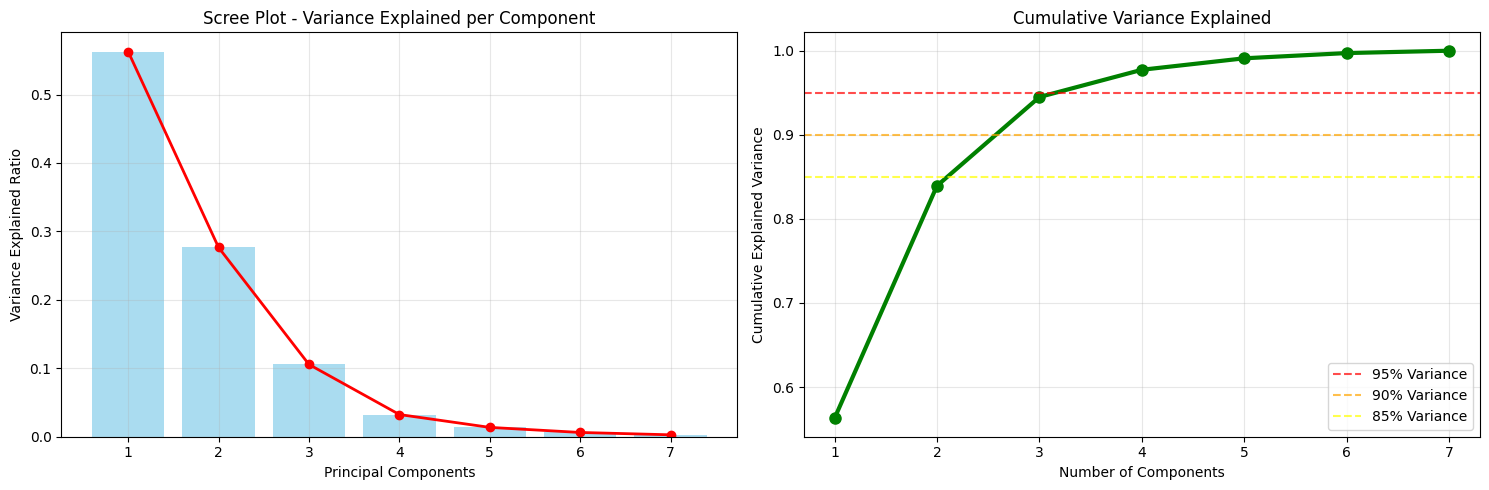


📈 2. LOADING FACTORS UNTUK 7 KOMPONEN UTAMA:

   🔍 PC1 - Top 5 Positive Loadings:
      R_150          :  0.4698
      R_100          :  0.4410
      R_200          :  0.4375
      G_150          : -0.0279
      G_200          : -0.3300
   🔍 PC1 - Top 5 Negative Loadings:
      R_200          :  0.4375
      G_150          : -0.0279
      G_200          : -0.3300
      B_200          : -0.3750
      B_150          : -0.3783

   🔍 PC2 - Top 5 Positive Loadings:
      G_150          :  0.6660
      G_200          :  0.4950
      R_150          :  0.0594
      R_200          :  0.0098
      R_100          : -0.2554
   🔍 PC2 - Top 5 Negative Loadings:
      R_150          :  0.0594
      R_200          :  0.0098
      R_100          : -0.2554
      B_150          : -0.3470
      B_200          : -0.3495

   🔍 PC3 - Top 5 Positive Loadings:
      B_200          :  0.4831
      R_200          :  0.4781
      B_150          :  0.4729
      G_150          :  0.3859
      R_150          :  0.3

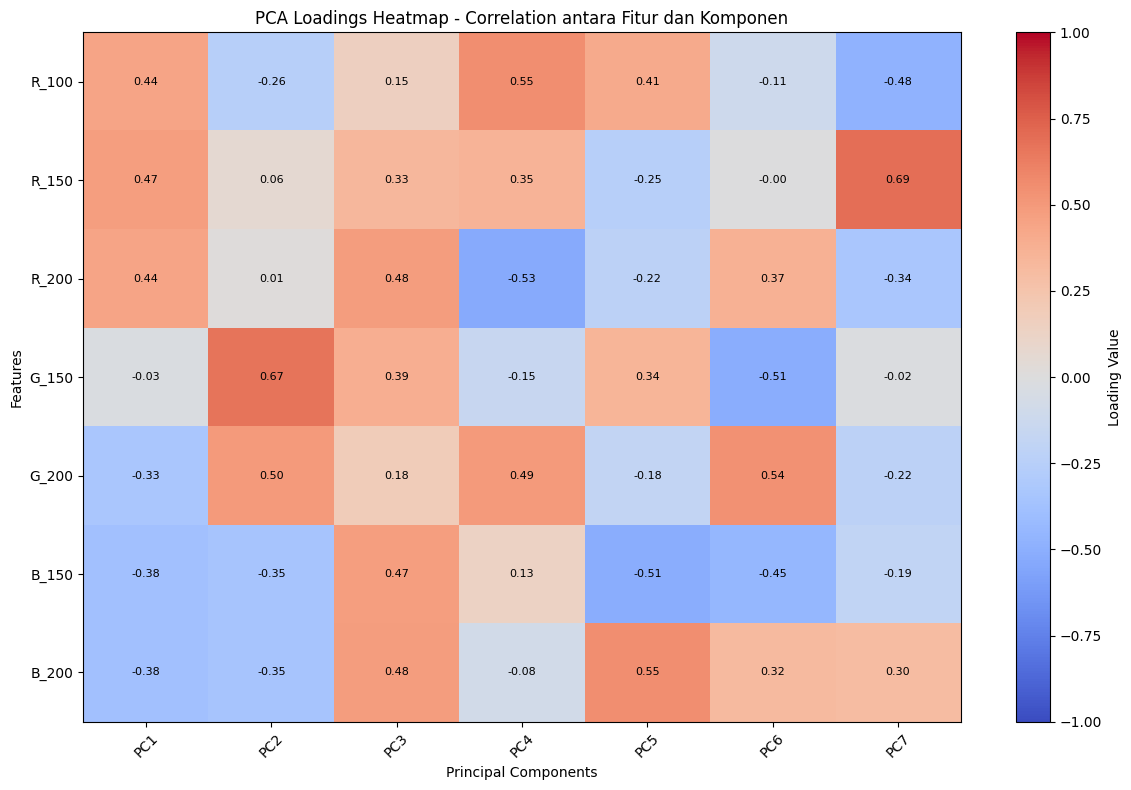

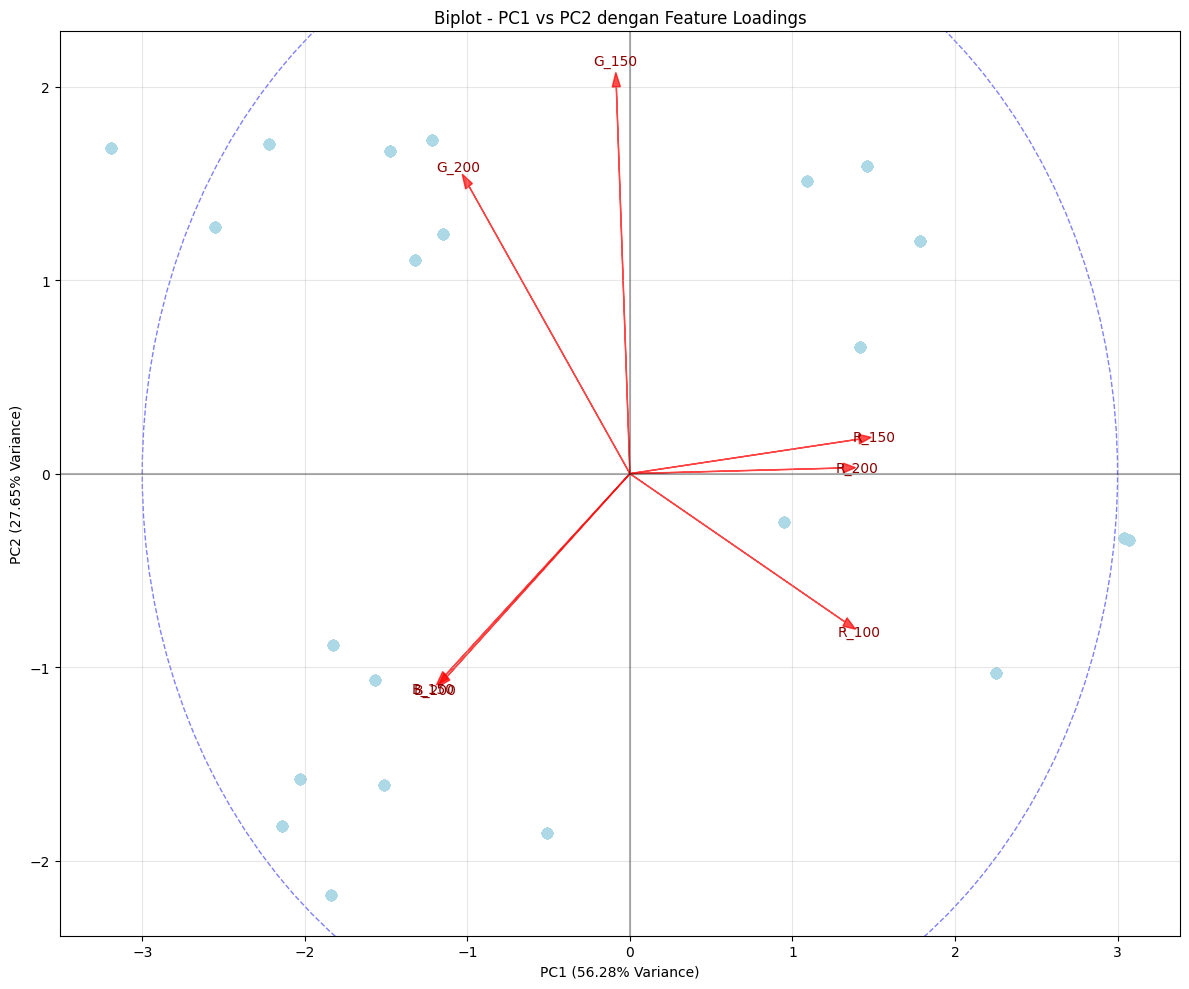

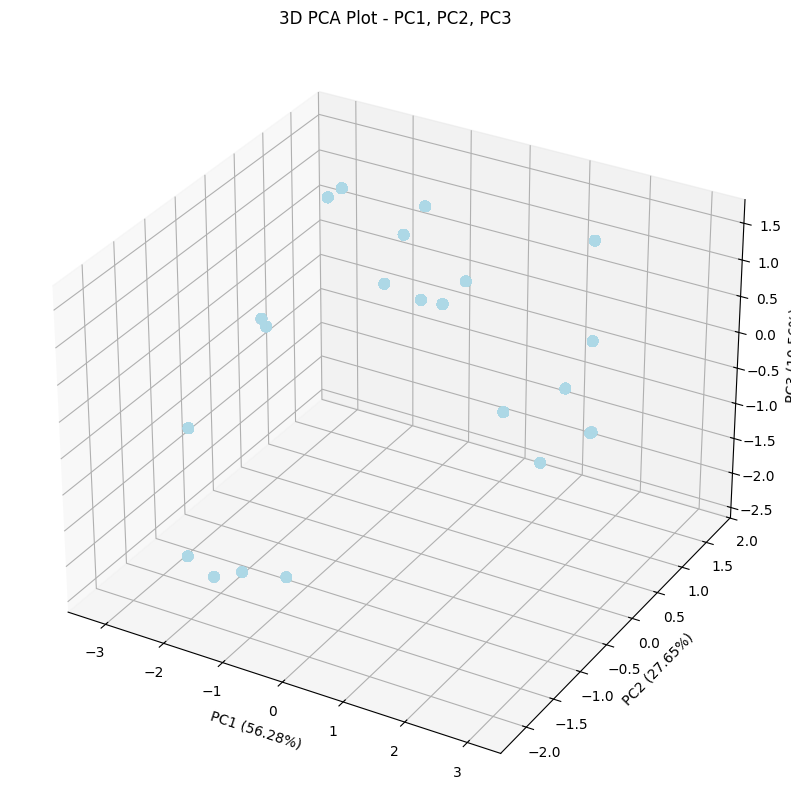


📋 3. RINGKASAN STATISTIK PCA:
   • Total variance explained: 1.0000 (100.00%)
   • Number of components untuk 95% variance: 4
   • Number of components untuk 90% variance: 3
   • Number of components untuk 85% variance: 3

🎯 4. FEATURE IMPORTANCE BERDASARKAN PC1:
   R_150          :  0.4698 ( 19.1%)
   R_100          :  0.4410 ( 17.9%)
   R_200          :  0.4375 ( 17.8%)
   B_150          :  0.3783 ( 15.4%)
   B_200          :  0.3750 ( 15.2%)
   G_200          :  0.3300 ( 13.4%)
   G_150          :  0.0279 (  1.1%)

🔍 DATA UNTUK VISUALISASI CLUSTERING:
   Jumlah total data points: 4400
   Cluster labels unik: ['red' 'pink' 'white' 'yellow']
   Cluster 'red': 1047 points
   Cluster 'pink': 1153 points
   Cluster 'white': 1145 points
   Cluster 'yellow': 1055 points
🎯 MENAMPILKAN 4 CENTROID DI PLOT...
   ✅ Centroid 0: pink di posisi [1.38282115 1.20132734]
   ✅ Centroid 1: red di posisi [-2.00094996  1.46932353]
   ✅ Centroid 2: white di posisi [ 2.26767214 -0.94588802]
   ✅ Centroid 

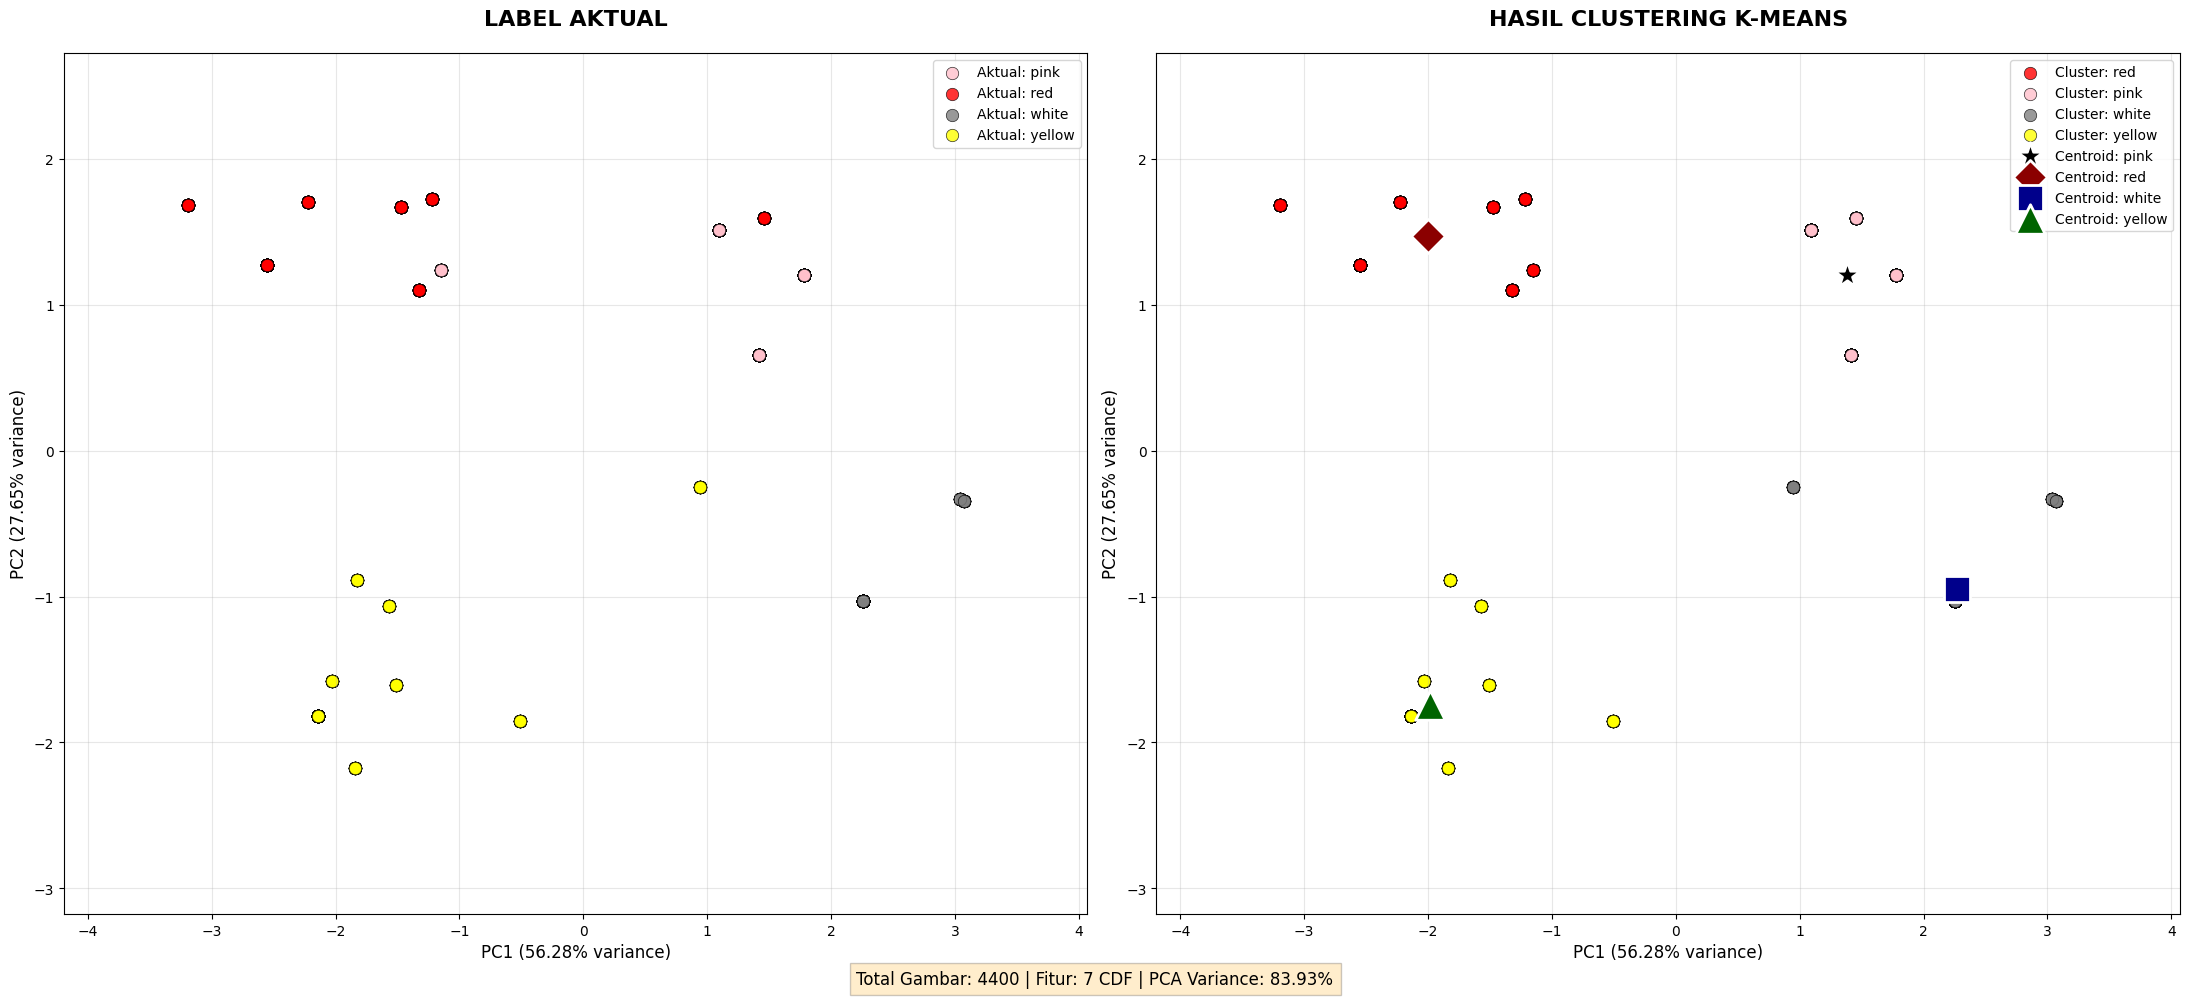


📈 DISTRIBUSI CLUSTER:
   pink: 1153 gambar (26.2%)
   white: 1145 gambar (26.0%)
   yellow: 1055 gambar (24.0%)
   red: 1047 gambar (23.8%)

15. ANALISIS FEATURE IMPORTANCE (ALTERNATIF SHAP)

ANALISIS FEATURE IMPORTANCE (ALTERNATIF SHAP)

🔍 Melatih Random Forest Classifier...

📊 TOP 7 FEATURE IMPORTANCE (Random Forest):
    1. G_200          : 0.220129 (22.0%)
    2. G_150          : 0.211745 (21.2%)
    3. B_150          : 0.209732 (21.0%)
    4. R_100          : 0.114255 (11.4%)
    5. R_200          : 0.099356 (9.9%)
    6. B_200          : 0.088060 (8.8%)
    7. R_150          : 0.056722 (5.7%)

🔍 Menghitung Permutation Importance...

📊 TOP 7 PERMUTATION IMPORTANCE:
    1. G_150          : 0.097023 ± 0.002265
    2. B_150          : 0.024432 ± 0.000987
    3. R_100          : 0.000000 ± 0.000000
    4. R_200          : 0.000000 ± 0.000000
    5. R_150          : 0.000000 ± 0.000000
    6. G_200          : 0.000000 ± 0.000000
    7. B_200          : 0.000000 ± 0.000000


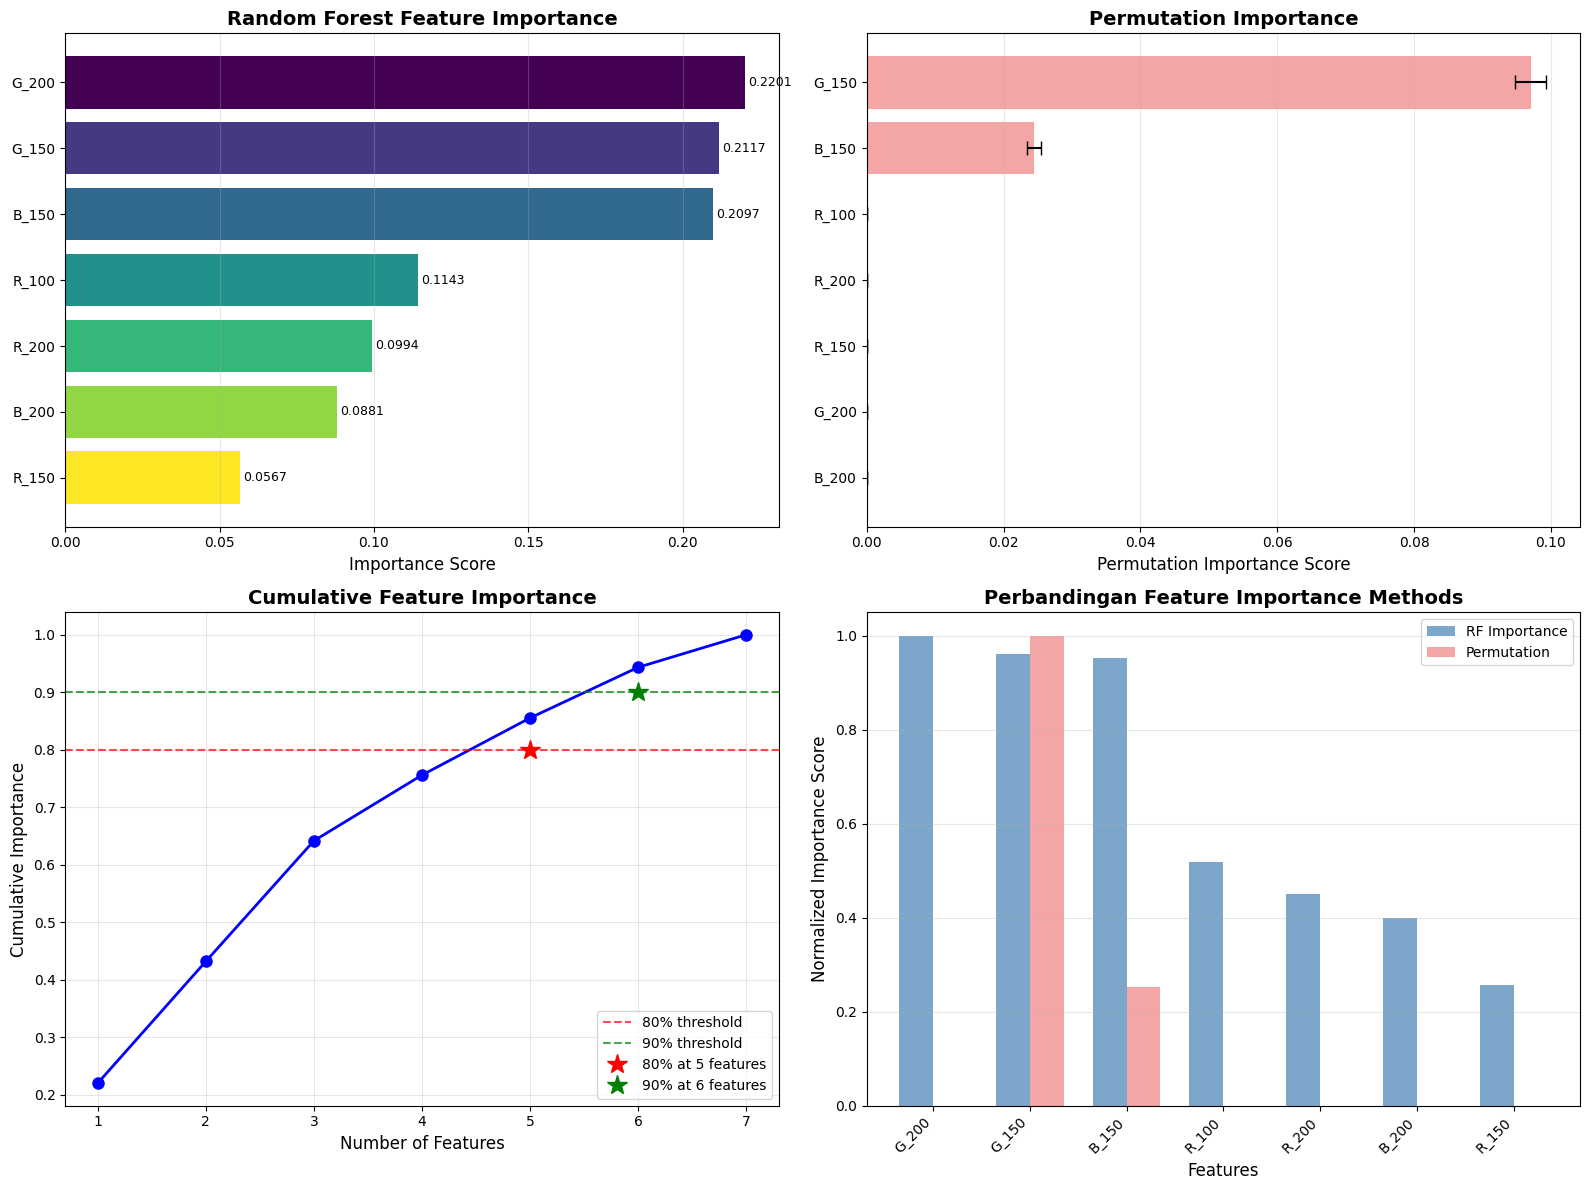


📋 SUMMARY FEATURE IMPORTANCE:
   • Total variance explained: 1.0000
   • Features untuk 80% importance: 5
     ['G_200', 'G_150', 'B_150', 'R_100', 'R_200']
   • Features untuk 90% importance: 6
     ['G_200', 'G_150', 'B_150', 'R_100', 'R_200', 'B_200']

ANALISIS IMPORTANCE BERDASARKAN CHANNEL DAN INTENSITAS

📊 IMPORTANCE PER CHANNEL:
   Channel R: 0.090111 (100.0%)
   Channel G: 0.215937 (70.6%)
   Channel B: 0.148896 (32.7%)

📊 IMPORTANCE PER INTENSITAS:
   Intensity 100: 0.114255 (100.0%)
   Intensity 150: 0.159400 (58.2%)
   Intensity 200: 0.135848 (33.2%)


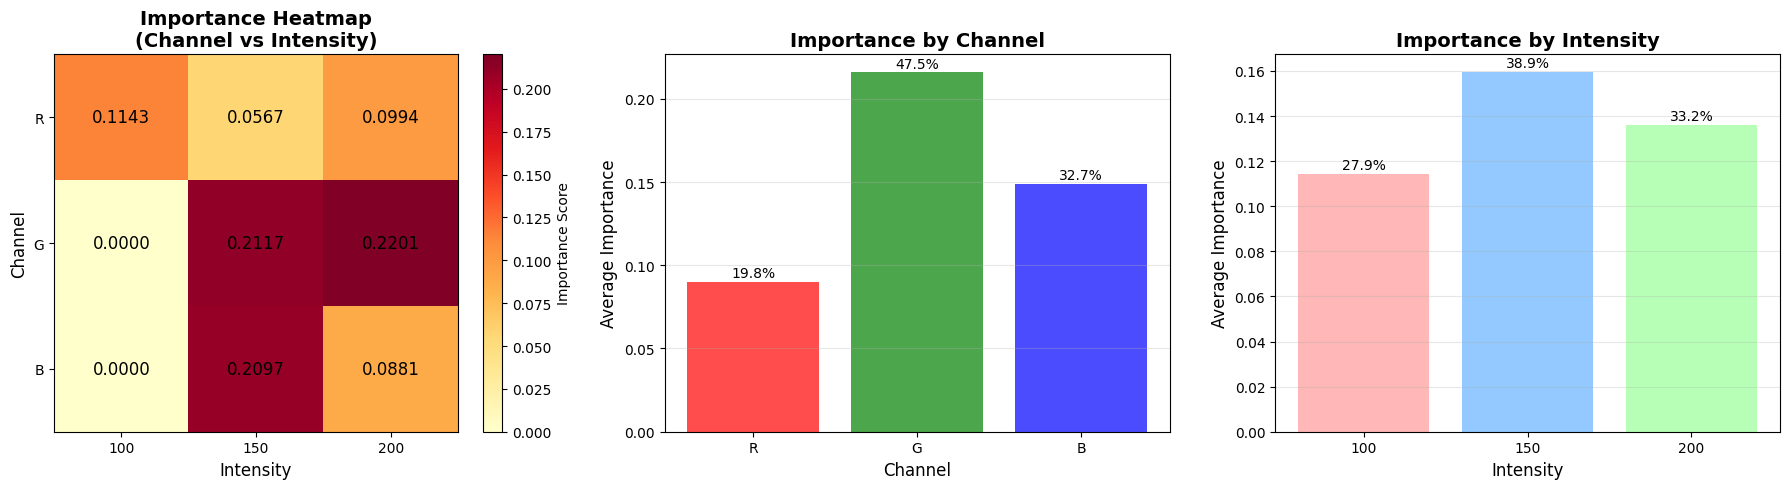


16. MENYIMPAN SEMUA HASIL ANALISIS: C:/Users/Ahsan/Downloads/analisis_pca_shap_4kelas.xlsx
💾 Semua hasil analisis disimpan ke: C:/Users/Ahsan/Downloads/analisis_pca_shap_4kelas.xlsx

17. MENYIMPAN HASIL CLUSTERING: C:/Users/Ahsan/Downloads/hasil_clustering_4kelas.xlsx
💾 Hasil clustering disimpan ke: C:/Users/Ahsan/Downloads/hasil_clustering_4kelas.xlsx

🎉 PROSES SELESAI UNTUK 4 KELAS MAWAR DENGAN 7 FITUR CDF!
DAN ANALISIS PCA & FEATURE IMPORTANCE LENGKAP

📊 RINGKASAN HASIL:
   - Total gambar diproses: 4400
   - Jumlah fitur CDF: 7 (R_100, R_150, R_200, G_150, G_200, B_150, B_200)
   - Akurasi clustering: 93.91%
   - Total variance explained oleh 7 komponen PCA: 100.00%
   - Variance explained oleh 2 komponen pertama: 83.93%
   - Top 3 fitur terpenting:
     1. G_200: 0.2201
     2. G_150: 0.2117
     3. B_150: 0.2097
   - File output:
     * Data RGB: C:/Users/Ahsan/Downloads/data_ekstraksi_rgb_4kelas.xlsx
     * Data ECDF (CSV): C:/Users/Ahsan/Downloads/data_ecdf_rgb_4kelas.csv
     

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Coba import SHAP, jika tidak ada, kita akan buat fungsi alternatif
try:
    import shap
    SHAP_AVAILABLE = True
    print("✅ SHAP berhasil diimport")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP tidak tersedia, menggunakan alternatif")

# =============================================
# KONFIGURASI - 4 FOLDER MAWAR
# =============================================
pink_rose_folder = "C:/Users/Ahsan/Downloads/data/pink_rose"
red_rose_folder = "C:/Users/Ahsan/Downloads/data/red_rose"  
white_rose_folder = "C:/Users/Ahsan/Downloads/data/white_rose"
yellow_rose_folder = "C:/Users/Ahsan/Downloads/data/yellow_rose"

output_excel = "C:/Users/Ahsan/Downloads/data_ekstraksi_rgb_4kelas.xlsx"
ecdf_output_csv = "C:/Users/Ahsan/Downloads/data_ecdf_rgb_4kelas.csv"
ecdf_intensity_output_excel = "C:/Users/Ahsan/Downloads/data_ecdf_intensitas_4kelas.xlsx"
conversion_output_excel = "C:/Users/Ahsan/Downloads/data_ecdf_cdf_konversi_4kelas.xlsx"
clustering_output_excel = "C:/Users/Ahsan/Downloads/hasil_clustering_4kelas.xlsx"
pca_shap_output_excel = "C:/Users/Ahsan/Downloads/analisis_pca_shap_4kelas.xlsx"

p = 32  # Ukuran resize gambar: p x p

# =============================================
# FUNGSI UTAMA UNTUK MEMPROSES GAMBAR
# =============================================

def process_image(image_path, label, gambar_ke):
    """
    Memproses satu gambar: resize ke p x p, ekstrak RGB, dan simpan ke Excel
    """
    # Baca gambar
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Tidak bisa membaca gambar: {image_path}")
        return None
    
    # Resize gambar menjadi p x p
    img_resized = cv2.resize(img, (p, p))
    
    # Konversi BGR ke RGB
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
    # Ekstrak channel R, G, B
    R = img_rgb[:, :, 0].flatten()
    G = img_rgb[:, :, 1].flatten()
    B = img_rgb[:, :, 2].flatten()
    
    # Hitung statistik
    hasil = {
        'filename': os.path.basename(image_path),
        'gambar_ke': gambar_ke,
        'label': label,
        'p': p,
        'total_pixels': p * p,
        'R_values': R,
        'G_values': G,
        'B_values': B,
        'avg_R': np.mean(R),
        'avg_G': np.mean(G),
        'avg_B': np.mean(B),
        'min_R': np.min(R),
        'max_R': np.max(R),
        'min_G': np.min(G),
        'max_G': np.max(G),
        'min_B': np.min(B),
        'max_B': np.max(B)
    }
    
    return hasil

def process_all_images(folder_path, label):
    """
    Memproses semua gambar dalam folder
    """
    results = []
    
    if not os.path.exists(folder_path):
        print(f"❌ Folder tidak ditemukan: {folder_path}")
        return pd.DataFrame()
    
    image_files = [f for f in os.listdir(folder_path) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not image_files:
        print(f"❌ Tidak ada gambar ditemukan di: {folder_path}")
        return pd.DataFrame()
    
    print(f"📁 Memproses {len(image_files)} gambar dari {folder_path} (label: {label})")
    
    for i, image_file in enumerate(image_files):
        image_path = os.path.join(folder_path, image_file)
        
        result = process_image(image_path, label, i+1)
        if result is not None:
            results.append(result)
    
    # Konversi ke DataFrame
    if results:
        df = pd.DataFrame(results)
        print(f"✅ Berhasil memproses {len(df)} gambar dengan label: {label}")
        return df
    else:
        print(f"❌ Tidak ada hasil yang berhasil diproses dari {folder_path}")
        return pd.DataFrame()

def save_rgb_to_excel(df_rgb, output_path):
    """
    Menyimpan data RGB ke file Excel
    """
    # Buat DataFrame yang lebih sederhana untuk disimpan
    save_data = []
    for _, row in df_rgb.iterrows():
        save_data.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label': row['label'],
            'p': row['p'],
            'total_pixels': row['total_pixels'],
            'R_values': str(row['R_values'].tolist()),
            'G_values': str(row['G_values'].tolist()),
            'B_values': str(row['B_values'].tolist()),
            'avg_R': row['avg_R'],
            'avg_G': row['avg_G'],
            'avg_B': row['avg_B'],
            'min_R': row['min_R'],
            'max_R': row['max_R'],
            'min_G': row['min_G'],
            'max_G': row['max_G'],
            'min_B': row['min_B'],
            'max_B': row['max_B']
        })
    
    df_save = pd.DataFrame(save_data)
    df_save.to_excel(output_path, index=False)
    print(f"💾 Data RGB disimpan ke: {output_path}")

# =============================================
# FUNGSI ECDF - DIPERBAIKI
# =============================================

def calculate_ecdf(values):
    """
    Menghitung ECDF untuk suatu set nilai
    """
    if len(values) == 0:
        return np.array([]), np.array([])
    
    # Urutkan nilai
    sorted_values = np.sort(values)
    
    # Hitung ECDF
    n = len(sorted_values)
    ecdf = np.arange(1, n + 1) / n
    
    return sorted_values, ecdf

def calculate_ecdf_for_image(image_data):
    """
    Menghitung ECDF untuk sebuah gambar
    """
    filename = image_data['filename']
    j = image_data['gambar_ke']
    label = image_data['label']
    p_j = image_data['p']
    
    ecdf_data = {
        'filename': filename,
        'gambar_ke': j,
        'label': label,
        'p_j': p_j,
        'R': {'intensity': [], 'ecdf': []},
        'G': {'intensity': [], 'ecdf': []},
        'B': {'intensity': [], 'ecdf': []}
    }
    
    # Untuk setiap channel R, G, B
    for channel in ['R', 'G', 'B']:
        values = image_data[f'{channel}_values']
        
        if len(values) > 0:
            intensity, ecdf = calculate_ecdf(values)
            ecdf_data[channel]['intensity'] = intensity
            ecdf_data[channel]['ecdf'] = ecdf
    
    return ecdf_data

def calculate_all_ecdf(df_rgb):
    """
    Menghitung ECDF untuk semua gambar
    """
    ecdf_results = {}
    
    for _, row in df_rgb.iterrows():
        ecdf_data = calculate_ecdf_for_image(row)
        ecdf_results[row['filename']] = ecdf_data
    
    return ecdf_results

def save_ecdf_to_csv(ecdf_data, output_path):
    """
    Menyimpan data ECDF ke file CSV (bukan Excel) untuk handle data besar
    """
    save_data = []
    
    for filename, data in ecdf_data.items():
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            if len(channel_data['intensity']) > 0:
                for intensity, ecdf_val in zip(channel_data['intensity'], channel_data['ecdf']):
                    save_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'intensity': intensity,
                        'ecdf': ecdf_val,
                        'p_j': data['p_j']
                    })
    
    df_save = pd.DataFrame(save_data)
    
    # Simpan ke CSV bukan Excel
    df_save.to_csv(output_path, index=False)
    print(f"💾 Data ECDF disimpan ke: {output_path}")
    print(f"📊 Jumlah baris data ECDF: {len(df_save)}")

# =============================================
# FUNGSI EKSTRAKSI ECDF PADA INTENSITAS TERTENTU - DIPERBAIKI
# =============================================

def extract_ecdf_at_intensities(ecdf_data, intensities=[100, 150, 200]):
    """
    Mengekstrak nilai ECDF pada intensitas tertentu untuk setiap gambar dan channel
    """
    ecdf_intensity_data = []
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Untuk setiap intensitas target, cari nilai ECDF-nya
                for intensity in intensities:
                    ecdf_val = 0.0
                    
                    if intensity < intensity_values[0]:
                        ecdf_val = 0.0
                    elif intensity >= intensity_values[-1]:
                        ecdf_val = 1.0
                    else:
                        # Cari di segmen mana intensitas berada
                        for m in range(len(intensity_values) - 1):
                            if intensity_values[m] <= intensity < intensity_values[m + 1]:
                                ecdf_val = ecdf_values[m]
                                break
                        else:
                            # Jika tidak ditemukan dalam loop, gunakan nilai terakhir
                            ecdf_val = ecdf_values[-1] if intensity >= intensity_values[-1] else 0.0
                    
                    ecdf_intensity_data.append({
                        'filename': filename,
                        'gambar_ke': j,
                        'label': label,
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val
                    })
    
    df_ecdf_intensities = pd.DataFrame(ecdf_intensity_data)
    return df_ecdf_intensities

# =============================================
# FUNGSI MODEL MATEMATIS V DENGAN 7 FITUR - DIPERBAIKI
# =============================================

def calculate_cdf_for_all_ecdf_intensities(df_ecdf_intensities):
    """
    Menghitung CDF untuk semua nilai ECDF pada intensitas tertentu
    Menghasilkan 7 fitur: R_100, R_150, R_200, G_150, G_200, B_150, B_200
    """
    cdf_data = []
    
    # Definisikan 7 kombinasi channel dan intensitas yang akan digunakan
    combinations = [
        ('R', 100), ('R', 150), ('R', 200),
        ('G', 150), ('G', 200),
        ('B', 150), ('B', 200)
    ]
    
    for channel, intensity in combinations:
        # Ambil nilai ECDF untuk kombinasi channel dan intensitas tertentu
        ecdf_values = df_ecdf_intensities[
            (df_ecdf_intensities['channel'] == channel) & 
            (df_ecdf_intensities['intensity_target'] == intensity)
        ]['ecdf_value'].values
        
        if len(ecdf_values) > 0:
            # Urutkan nilai ECDF
            sorted_ecdf = np.sort(ecdf_values)
            
            # Hitung CDF
            cdf_values = np.arange(1, len(sorted_ecdf) + 1) / len(sorted_ecdf)
            
            # Simpan data
            for ecdf_val, cdf_val in zip(sorted_ecdf, cdf_values):
                cdf_data.append({
                    'channel': channel,
                    'intensity_target': intensity,
                    'ecdf_value': ecdf_val,
                    'cdf_value': cdf_val
                })
    
    df_cdf = pd.DataFrame(cdf_data)
    return df_cdf

def create_mathematical_model_V_7features(df_cdf):
    """
    Membuat model matematis V dari data CDF intensitas dengan 7 fitur
    """
    model_V = {}
    
    # 7 kombinasi channel dan intensitas
    combinations = [
        ('R', 100), ('R', 150), ('R', 200),
        ('G', 150), ('G', 200),
        ('B', 150), ('B', 200)
    ]
    
    for channel, intensity in combinations:
        model_key = f'{channel}_{intensity}'
        channel_data = df_cdf[(df_cdf['channel'] == channel) & (df_cdf['intensity_target'] == intensity)]
        
        if not channel_data.empty:
            model_V[model_key] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
            print(f"   ✅ Model untuk {model_key}: {len(channel_data)} data points")
        else:
            print(f"   ❌ Tidak ada data untuk {model_key}")
    
    print("✅ Model matematis V dengan 7 fitur berhasil dibuat")
    print(f"🔧 Komponen model V: {list(model_V.keys())}")
    
    return model_V

def convert_ecdf_to_cdf_with_model_V(ecdf_value, model_key, model_V):
    """
    Mengkonversi nilai ECDF ke CDF menggunakan model matematis V
    """
    if model_key not in model_V:
        return None
    
    model_data = model_V[model_key]
    ecdf_values = model_data['ecdf_values']
    cdf_values = model_data['cdf_values']
    
    # Jika ECDF value di luar range model, return None
    if ecdf_value < ecdf_values[0] or ecdf_value > ecdf_values[-1]:
        return None
    
    # Cari posisi ECDF value dalam model
    idx = np.searchsorted(ecdf_values, ecdf_value, side='right') - 1
    
    # Return CDF value yang sesuai
    return cdf_values[idx]

def extract_and_convert_ecdf_data_7features(ecdf_data, model_V):
    """
    Mengekstrak ECDF dari gambar pada 7 intensitas tertentu dan mengkonversinya ke CDF menggunakan model V
    """
    conversion_results = []
    
    # 7 kombinasi channel dan intensitas
    combinations = [
        ('R', 100), ('R', 150), ('R', 200),
        ('G', 150), ('G', 200),
        ('B', 150), ('B', 200)
    ]
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        # Ekstrak ECDF pada 7 intensitas tertentu untuk semua channel
        for channel, intensity in combinations:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Tentukan model_key berdasarkan channel dan intensitas
                model_key = f'{channel}_{intensity}'
                
                # Skip jika model_key tidak ada di model_V
                if model_key not in model_V:
                    continue
                
                # Cari nilai ECDF pada intensitas target
                ecdf_val = 0.0
                for m in range(len(intensity_values)):
                    if intensity < intensity_values[0]:
                        ecdf_val = 0.0
                        break
                    elif intensity >= intensity_values[m]:
                        if m == len(intensity_values) - 1 or intensity < intensity_values[m + 1]:
                            ecdf_val = ecdf_values[m]
                            break
                    elif intensity >= intensity_values[-1]:
                        ecdf_val = 1.0
                        break
                
                # Konversi ECDF ke CDF menggunakan model V
                cdf_val = convert_ecdf_to_cdf_with_model_V(ecdf_val, model_key, model_V)
                
                conversion_results.append({
                    'filename': filename,
                    'gambar_ke': j,
                    'label': label,
                    'channel': channel,
                    'intensity_target': intensity,
                    'ecdf_value': ecdf_val,
                    'cdf_value': cdf_val,
                    'model_key': model_key
                })
    
    df_conversion = pd.DataFrame(conversion_results)
    return df_conversion

def save_conversion_data(ecdf_data, df_conversion, output_path):
    """
    Menyimpan data ECDF gambar dan CDF hasil konversi ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data konversi ECDF ke CDF (data kecil)
        df_conversion.to_excel(writer, sheet_name='Konversi_ECDF_ke_CDF', index=False)
        
        # Sheet 2: Ringkasan ECDF per gambar (data lebih kecil)
        summary_data = []
        for filename, data in ecdf_data.items():
            for channel in ['R', 'G', 'B']:
                channel_data = data[channel]
                if len(channel_data['intensity']) > 0:
                    summary_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'num_points': len(channel_data['intensity']),
                        'min_intensity': min(channel_data['intensity']),
                        'max_intensity': max(channel_data['intensity']),
                        'min_ecdf': min(channel_data['ecdf']),
                        'max_ecdf': max(channel_data['ecdf'])
                    })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Ringkasan_ECDF', index=False)
    
    print(f"💾 Data konversi CDF disimpan ke: {output_path}")

def save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, output_path):
    """
    Menyimpan data ECDF pada intensitas tertentu dan CDF-nya ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data ECDF pada intensitas tertentu
        df_ecdf_intensities.to_excel(writer, sheet_name='ECDF_Intensitas', index=False)
        
        # Sheet 2: Data CDF dari ECDF intensitas
        df_cdf.to_excel(writer, sheet_name='CDF_ECDF_Intensitas', index=False)
    
    print(f"💾 Data ECDF intensitas dan CDF disimpan ke: {output_path}")

# =============================================
# FUNGSI K-MEANS CLUSTERING DENGAN 7 FITUR - DIPERBAIKI
# =============================================

def prepare_features_for_clustering_7features(df_conversion):
    """
    Menyiapkan fitur untuk clustering dari data CDF hasil konversi dengan 7 fitur
    """
    # Group by filename untuk mendapatkan semua fitur CDF per gambar
    features_data = []
    
    for filename in df_conversion['filename'].unique():
        file_data = df_conversion[df_conversion['filename'] == filename]
        
        # Ekstrak semua nilai CDF untuk gambar ini (7 fitur)
        feature_vector = {}
        feature_vector['filename'] = filename
        feature_vector['gambar_ke'] = file_data['gambar_ke'].iloc[0]
        feature_vector['label'] = file_data['label'].iloc[0]
        
        # Untuk setiap kombinasi channel dan intensitas (7 fitur)
        combinations = [
            ('R', 100), ('R', 150), ('R', 200),
            ('G', 150), ('G', 200),
            ('B', 150), ('B', 200)
        ]
        
        for channel, intensity in combinations:
            key = f"{channel}_{intensity}"
            # Cari nilai CDF untuk kombinasi ini
            matching_rows = file_data[
                (file_data['channel'] == channel) & 
                (file_data['intensity_target'] == intensity)
            ]
            
            if not matching_rows.empty:
                feature_vector[key] = matching_rows['cdf_value'].iloc[0]
            else:
                feature_vector[key] = 0.0  # Default value jika tidak ada
        
        features_data.append(feature_vector)
    
    df_features = pd.DataFrame(features_data)
    
    # DEBUG: Tampilkan informasi tentang fitur
    print(f"🔍 Jumlah gambar untuk clustering: {len(df_features)}")
    print(f"🔍 Jumlah fitur per gambar: {len([col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']])}")
    print(f"🔍 Fitur yang digunakan: {[col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']]}")
    
    # Fill NaN values dengan 0
    df_features = df_features.fillna(0)
    
    return df_features

def perform_kmeans_clustering_7features(df_features):
    """
    Melakukan K-means clustering dengan 4 centroid berdasarkan 7 fitur CDF
    """
    print(f"\n🔍 Menyiapkan clustering dengan {len(df_features)} gambar dan 7 fitur")
    
    # Filter hanya kolom fitur (exclude metadata)
    feature_columns = [col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']]
    
    # Pastikan semua fitur columns ada
    if len(feature_columns) == 0:
        print("❌ Tidak ada fitur yang ditemukan untuk clustering!")
        return None, None, None, []
    
    # DEBUG: Print informasi fitur
    print(f"🔍 Jumlah fitur: {len(feature_columns)}")
    print(f"🔍 Fitur: {feature_columns}")
    print(f"🔍 Shape data: {df_features[feature_columns].shape}")
    
    # Ekstrak matriks fitur
    X = df_features[feature_columns].values
    
    # Hitung centroid untuk setiap kelas
    centroids_dict = {}
    
    actual_labels = df_features['label'].unique()
    print(f"🔍 Label unik yang ditemukan: {actual_labels}")
    
    for label in actual_labels:
        class_data = df_features[df_features['label'] == label]
        if len(class_data) > 0:
            # Hitung rata-rata untuk setiap fitur
            centroid_values = class_data[feature_columns].mean(axis=0).values
            centroids_dict[label] = centroid_values
            print(f"✅ Centroid untuk kelas '{label}': {len(class_data)} gambar")
        else:
            print(f"❌ Tidak ada gambar untuk kelas '{label}'")
    
    if len(centroids_dict) < 2:
        print(f"⚠️  Hanya {len(centroids_dict)} kelas yang memiliki centroid! Menggunakan K-means standar...")
        kmeans = KMeans(n_clusters=min(4, len(df_features)), random_state=42)
        labels = kmeans.fit_predict(X)
        centroids = kmeans.cluster_centers_
    else:
        # Siapkan initial centroids dari rata-rata kelas
        initial_centroids = np.array(list(centroids_dict.values()))
        
        print(f"📍 Shape initial centroids: {initial_centroids.shape}")
        print(f"🎯 Kelas yang digunakan: {list(centroids_dict.keys())}")
        
        # Gunakan jumlah cluster yang sesuai dengan data yang ada
        n_clusters = min(4, len(initial_centroids), len(df_features))
        
        try:
            # Lakukan K-means dengan inisialisasi centroid spesifik
            kmeans = KMeans(
                n_clusters=n_clusters,
                init=initial_centroids[:n_clusters],  # Hanya ambil sebanyak n_clusters
                n_init=1,
                max_iter=300,
                random_state=42
            )
            
            labels = kmeans.fit_predict(X)
            centroids = kmeans.cluster_centers_
            print(f"✅ K-means clustering dengan {n_clusters} cluster berhasil!")
            
        except Exception as e:
            print(f"❌ Error dalam K-means: {e}")
            print("🔄 Menggunakan K-means standar...")
            kmeans = KMeans(n_clusters=min(4, len(df_features)), random_state=42)
            labels = kmeans.fit_predict(X)
            centroids = kmeans.cluster_centers_
    
    # Tambahkan hasil clustering ke DataFrame
    df_features = df_features.copy()
    df_features['cluster'] = labels
    
    try:
        df_features['distance_to_centroid'] = kmeans.transform(X).min(axis=1)
    except:
        df_features['distance_to_centroid'] = 0.0
    
    # Mapping cluster ke label berdasarkan centroid terdekat
    cluster_mapping = {}
    
    # Untuk setiap cluster, cari centroid kelas mana yang paling dekat
    for cluster_idx in range(len(np.unique(labels))):
        if cluster_idx < len(centroids):  # Pastikan cluster_idx valid
            cluster_center = centroids[cluster_idx]
            
            # Hitung jarak ke setiap centroid kelas
            distances = {}
            for label, class_centroid in centroids_dict.items():
                distance = np.linalg.norm(cluster_center - class_centroid)
                distances[label] = distance
            
            # Pilih label dengan jarak terdekat
            if distances:  # Pastikan distances tidak kosong
                closest_label = min(distances, key=distances.get)
                cluster_mapping[cluster_idx] = closest_label
            else:
                cluster_mapping[cluster_idx] = f'cluster_{cluster_idx}'
    
    print(f"🔀 Mapping cluster: {cluster_mapping}")
    
    df_features['cluster_label'] = df_features['cluster'].map(cluster_mapping)
    
    # Simpan informasi centroid yang digunakan
    centroid_info = []
    for cluster_idx in range(len(np.unique(labels))):
        if cluster_idx in cluster_mapping:
            label = cluster_mapping[cluster_idx]
            centroid_values = centroids[cluster_idx] if cluster_idx < len(centroids) else None
            centroid_info.append({
                'cluster': cluster_idx,
                'cluster_label': label,
                'centroid_values': centroid_values
            })
    
    return df_features, kmeans, feature_columns, centroid_info

def analyze_clustering_results_4classes(df_features, df_conversion, centroid_info):
    """
    Menganalisis dan menampilkan hasil clustering untuk 4 kelas
    """
    print("\n" + "="*80)
    print("HASIL K-MEANS CLUSTERING - 7 FITUR")
    print("="*80)
    
    # Tampilkan informasi centroid
    print("\n🎯 INFORMASI CENTROID:")
    for i, centroid in enumerate(centroid_info):
        print(f"   Cluster {centroid['cluster']}: {centroid['cluster_label']}")
    
    # Hitung akurasi clustering
    correct_predictions = 0
    total_predictions = len(df_features)
    
    clustering_results = []
    
    for _, row in df_features.iterrows():
        actual_label = row['label']
        predicted_label = row['cluster_label']
        is_correct = (actual_label == predicted_label)
        
        if is_correct:
            correct_predictions += 1
        
        clustering_results.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label_aktual': actual_label,
            'cluster_prediksi': row['cluster'],
            'label_prediksi': predicted_label,
            'benar': is_correct,
            'jarak_ke_centroid': row['distance_to_centroid']
        })
    
    accuracy = correct_predictions / total_predictions * 100 if total_predictions > 0 else 0
    
    print(f"\n📈 AKURASI CLUSTERING: {accuracy:.2f}%")
    print(f"   Benar: {correct_predictions}/{total_predictions}")
    
    # Tampilkan confusion matrix sederhana
    print("\n📊 CONFUSION MATRIX:")
    df_results = pd.DataFrame(clustering_results)
    if not df_results.empty:
        confusion_matrix = pd.crosstab(df_results['label_aktual'], df_results['label_prediksi'])
        print(confusion_matrix)
    
    return df_results, accuracy

# =============================================
# FUNGSI ANALISIS PCA
# =============================================

def detailed_pca_analysis(X, feature_names, n_components=7):
    """
    Melakukan analisis PCA yang lebih detail dan menyeluruh
    """
    print("\n" + "="*80)
    print("ANALISIS PCA DETAIL - 7 KOMPONEN UTAMA")
    print("="*80)
    
    # Standardisasi data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Lakukan PCA untuk semua komponen
    pca_full = PCA(n_components=n_components)
    X_pca_full = pca_full.fit_transform(X_scaled)
    
    # 1. Variance Explained Analysis
    print("\n📊 1. ANALISIS VARIANCE EXPLAINED:")
    print("   Komponen | Variance Explained | Cumulative Variance")
    print("   " + "-" * 50)
    
    cumulative_variance = 0
    for i, var in enumerate(pca_full.explained_variance_ratio_):
        cumulative_variance += var
        print(f"   PC{i+1:2}     | {var:6.4f} ({var:6.2%})     | {cumulative_variance:6.4f} ({cumulative_variance:6.2%})")
    
    # 2. Scree Plot
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    components = range(1, len(pca_full.explained_variance_ratio_) + 1)
    plt.bar(components, pca_full.explained_variance_ratio_, alpha=0.7, color='skyblue')
    plt.plot(components, pca_full.explained_variance_ratio_, 'ro-', linewidth=2)
    plt.xlabel('Principal Components')
    plt.ylabel('Variance Explained Ratio')
    plt.title('Scree Plot - Variance Explained per Component')
    plt.grid(True, alpha=0.3)
    
    # Cumulative variance plot
    plt.subplot(1, 2, 2)
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
    plt.plot(components, cumulative_variance, 'go-', linewidth=3, markersize=8)
    plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% Variance')
    plt.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% Variance')
    plt.axhline(y=0.85, color='yellow', linestyle='--', alpha=0.7, label='85% Variance')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Cumulative Variance Explained')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Component Loadings Analysis
    print(f"\n📈 2. LOADING FACTORS UNTUK {n_components} KOMPONEN UTAMA:")
    
    # Buat DataFrame untuk loadings
    loadings_df = pd.DataFrame(
        pca_full.components_.T,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=feature_names
    )
    
    # Tampilkan loadings untuk setiap PC
    for i in range(min(3, n_components)):  # Tampilkan 3 PC pertama secara detail
        print(f"\n   🔍 PC{i+1} - Top 5 Positive Loadings:")
        pc_loadings = loadings_df[f'PC{i+1}'].sort_values(ascending=False)
        for feature, loading in pc_loadings.head().items():
            print(f"      {feature:15}: {loading:7.4f}")
        
        print(f"   🔍 PC{i+1} - Top 5 Negative Loadings:")
        for feature, loading in pc_loadings.tail().items():
            print(f"      {feature:15}: {loading:7.4f}")
    
    # 4. Heatmap untuk loadings
    plt.figure(figsize=(12, 8))
    im = plt.imshow(loadings_df.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    plt.colorbar(im, label='Loading Value')
    plt.xticks(range(len(loadings_df.columns)), loadings_df.columns, rotation=45)
    plt.yticks(range(len(loadings_df.index)), loadings_df.index)
    plt.title('PCA Loadings Heatmap - Correlation antara Fitur dan Komponen')
    plt.xlabel('Principal Components')
    plt.ylabel('Features')
    
    # Tambahkan nilai di heatmap
    for i in range(len(loadings_df.index)):
        for j in range(len(loadings_df.columns)):
            plt.text(j, i, f'{loadings_df.iloc[i, j]:.2f}', 
                    ha="center", va="center", color="black", fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Biplot (PC1 vs PC2 dengan loadings)
    plt.figure(figsize=(12, 10))
    
    # Plot data points
    scatter = plt.scatter(X_pca_full[:, 0], X_pca_full[:, 1], alpha=0.6, c='lightblue', s=50)
    
    # Plot loadings sebagai arrows
    for i, feature in enumerate(feature_names):
        plt.arrow(0, 0, 
                 pca_full.components_[0, i] * 3,  # Scale factor untuk visibility
                 pca_full.components_[1, i] * 3,
                 color='red', alpha=0.7, head_width=0.05)
        plt.text(pca_full.components_[0, i] * 3.2, 
                pca_full.components_[1, i] * 3.2, 
                feature, color='darkred', fontsize=10, ha='center', va='center')
    
    plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%} Variance)')
    plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%} Variance)')
    plt.title('Biplot - PC1 vs PC2 dengan Feature Loadings')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    # Add circle
    circle = plt.Circle((0, 0), 3, color='blue', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_artist(circle)
    
    plt.tight_layout()
    plt.show()
    
    # 6. 3D Plot jika memungkinkan
    if n_components >= 3:
        from mpl_toolkits.mplot3d import Axes3D
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        scatter = ax.scatter(X_pca_full[:, 0], X_pca_full[:, 1], X_pca_full[:, 2], 
                           alpha=0.6, s=50, c='lightblue')
        
        ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%})')
        ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%})')
        ax.set_zlabel(f'PC3 ({pca_full.explained_variance_ratio_[2]:.2%})')
        ax.set_title('3D PCA Plot - PC1, PC2, PC3')
        
        plt.show()
    
    # 7. Summary statistics
    print(f"\n📋 3. RINGKASAN STATISTIK PCA:")
    print(f"   • Total variance explained: {sum(pca_full.explained_variance_ratio_):.4f} ({sum(pca_full.explained_variance_ratio_):.2%})")
    print(f"   • Number of components untuk 95% variance: {np.where(cumulative_variance >= 0.95)[0][0] + 1 if len(np.where(cumulative_variance >= 0.95)[0]) > 0 else 'N/A'}")
    print(f"   • Number of components untuk 90% variance: {np.where(cumulative_variance >= 0.90)[0][0] + 1 if len(np.where(cumulative_variance >= 0.90)[0]) > 0 else 'N/A'}")
    print(f"   • Number of components untuk 85% variance: {np.where(cumulative_variance >= 0.85)[0][0] + 1 if len(np.where(cumulative_variance >= 0.85)[0]) > 0 else 'N/A'}")
    
    # 8. Feature importance berdasarkan PC1 (komponen paling penting)
    print(f"\n🎯 4. FEATURE IMPORTANCE BERDASARKAN PC1:")
    pc1_loadings = loadings_df['PC1'].abs().sort_values(ascending=False)
    for feature, loading in pc1_loadings.items():
        importance = loading / pc1_loadings.sum() * 100
        print(f"   {feature:15}: {loading:7.4f} ({importance:5.1f}%)")
    
    return pca_full, X_pca_full, loadings_df

# =============================================
# FUNGSI ANALISIS SHAP
# =============================================

def perform_shap_analysis_alternative(X, y, feature_names):
    """
    Alternatif analisis SHAP tanpa library SHAP
    Menggunakan RandomForest feature importance dan permutation importance
    """
    print("\n" + "="*80)
    print("ANALISIS FEATURE IMPORTANCE (ALTERNATIF SHAP)")
    print("="*80)
    
    # Latih Random Forest Classifier
    print("\n🔍 Melatih Random Forest Classifier...")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X, y)
    
    # 1. Feature Importance dari Random Forest
    rf_importance = rf_model.feature_importances_
    
    # Buat DataFrame untuk feature importance
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_importance
    }).sort_values('importance', ascending=False)
    
    print("\n📊 TOP 7 FEATURE IMPORTANCE (Random Forest):")
    for i, (_, row) in enumerate(importance_df.iterrows()):
        print(f"   {i+1:2}. {row['feature']:15}: {row['importance']:.6f} ({row['importance']/importance_df['importance'].sum()*100:.1f}%)")
    
    # 2. Permutation Importance
    print("\n🔍 Menghitung Permutation Importance...")
    perm_result = permutation_importance(
        rf_model, X, y, 
        n_repeats=10, 
        random_state=42,
        n_jobs=-1
    )
    
    perm_df = pd.DataFrame({
        'feature': feature_names,
        'perm_importance_mean': perm_result.importances_mean,
        'perm_importance_std': perm_result.importances_std
    }).sort_values('perm_importance_mean', ascending=False)
    
    print("\n📊 TOP 7 PERMUTATION IMPORTANCE:")
    for i, (_, row) in enumerate(perm_df.iterrows()):
        print(f"   {i+1:2}. {row['feature']:15}: {row['perm_importance_mean']:.6f} ± {row['perm_importance_std']:.6f}")
    
    # 3. Visualisasi Feature Importance
    visualize_feature_importance_alternative(importance_df, perm_df, feature_names)
    
    # 4. Analisis Channel Intensity
    analyze_channel_intensity_importance(importance_df, feature_names)
    
    return importance_df, perm_df

def visualize_feature_importance_alternative(importance_df, perm_df, feature_names):
    """
    Visualisasi alternatif untuk feature importance
    """
    # 1. Bar Plot untuk Feature Importance
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Random Forest Feature Importance
    ax1 = axes[0, 0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
    bars1 = ax1.barh(range(len(importance_df)), importance_df['importance'], color=colors)
    ax1.set_yticks(range(len(importance_df)))
    ax1.set_yticklabels(importance_df['feature'])
    ax1.invert_yaxis()
    ax1.set_xlabel('Importance Score', fontsize=12)
    ax1.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Tambahkan nilai pada bar
    for i, (bar, importance) in enumerate(zip(bars1, importance_df['importance'])):
        ax1.text(importance + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{importance:.4f}', ha='left', va='center', fontsize=9)
    
    # Plot 2: Permutation Importance
    ax2 = axes[0, 1]
    x_pos = np.arange(len(perm_df))
    bars2 = ax2.barh(x_pos, perm_df['perm_importance_mean'], 
                     xerr=perm_df['perm_importance_std'],
                     color='lightcoral', alpha=0.7, capsize=5)
    ax2.set_yticks(x_pos)
    ax2.set_yticklabels(perm_df['feature'])
    ax2.invert_yaxis()
    ax2.set_xlabel('Permutation Importance Score', fontsize=12)
    ax2.set_title('Permutation Importance', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Plot 3: Cumulative Importance
    ax3 = axes[1, 0]
    cumulative_importance = importance_df['importance'].cumsum()
    ax3.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 
             'b-o', linewidth=2, markersize=8)
    ax3.axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='80% threshold')
    ax3.axhline(y=0.9, color='g', linestyle='--', alpha=0.7, label='90% threshold')
    
    # Tandai titik threshold
    idx_80 = np.where(cumulative_importance >= 0.8)[0]
    idx_90 = np.where(cumulative_importance >= 0.9)[0]
    
    if len(idx_80) > 0:
        n_80 = idx_80[0] + 1
        ax3.plot(n_80, 0.8, 'r*', markersize=15, label=f'80% at {n_80} features')
    
    if len(idx_90) > 0:
        n_90 = idx_90[0] + 1
        ax3.plot(n_90, 0.9, 'g*', markersize=15, label=f'90% at {n_90} features')
    
    ax3.set_xlabel('Number of Features', fontsize=12)
    ax3.set_ylabel('Cumulative Importance', fontsize=12)
    ax3.set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
    ax3.set_xticks(range(1, len(cumulative_importance) + 1))
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Plot 4: Perbandingan kedua metode
    ax4 = axes[1, 1]
    x = np.arange(len(importance_df))
    width = 0.35
    
    # Normalisasi skor untuk perbandingan
    rf_norm = importance_df['importance'] / importance_df['importance'].max()
    perm_norm = perm_df.set_index('feature').loc[importance_df['feature']]['perm_importance_mean']
    perm_norm = perm_norm / perm_norm.max()
    
    ax4.bar(x - width/2, rf_norm, width, label='RF Importance', color='steelblue', alpha=0.7)
    ax4.bar(x + width/2, perm_norm, width, label='Permutation', color='lightcoral', alpha=0.7)
    
    ax4.set_xlabel('Features', fontsize=12)
    ax4.set_ylabel('Normalized Importance Score', fontsize=12)
    ax4.set_title('Perbandingan Feature Importance Methods', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(importance_df['feature'], rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Summary informasi
    print(f"\n📋 SUMMARY FEATURE IMPORTANCE:")
    print(f"   • Total variance explained: {importance_df['importance'].sum():.4f}")
    
    if len(idx_80) > 0:
        n_features_80 = idx_80[0] + 1
        features_80 = importance_df['feature'].iloc[:n_features_80].tolist()
        print(f"   • Features untuk 80% importance: {n_features_80}")
        print(f"     {features_80}")
    
    if len(idx_90) > 0:
        n_features_90 = idx_90[0] + 1
        features_90 = importance_df['feature'].iloc[:n_features_90].tolist()
        print(f"   • Features untuk 90% importance: {n_features_90}")
        print(f"     {features_90}")

def analyze_channel_intensity_importance(importance_df, feature_names):
    """
    Analisis importance berdasarkan channel dan intensitas
    """
    print("\n" + "="*80)
    print("ANALISIS IMPORTANCE BERDASARKAN CHANNEL DAN INTENSITAS")
    print("="*80)
    
    # Ekstrak informasi channel dan intensitas
    channel_stats = {'R': [], 'G': [], 'B': []}
    intensity_stats = {'100': [], '150': [], '200': []}
    channel_intensity_matrix = np.zeros((3, 3))  # 3 channels x 3 intensities
    
    # Mapping channel dan intensitas ke indeks
    channel_idx = {'R': 0, 'G': 1, 'B': 2}
    intensity_idx = {'100': 0, '150': 1, '200': 2}
    
    for _, row in importance_df.iterrows():
        feature = row['feature']
        importance = row['importance']
        
        # Parse feature name: format "R_100"
        if '_' in feature:
            parts = feature.split('_')
            if len(parts) == 2:
                channel = parts[0]
                intensity = parts[1]
                
                if channel in channel_stats:
                    channel_stats[channel].append(importance)
                
                if intensity in intensity_stats:
                    intensity_stats[intensity].append(importance)
                
                # Update matrix
                if channel in channel_idx and intensity in intensity_idx:
                    channel_intensity_matrix[channel_idx[channel], intensity_idx[intensity]] = importance
    
    # Hitung rata-rata per channel
    print("\n📊 IMPORTANCE PER CHANNEL:")
    channel_means = {}
    for channel, values in channel_stats.items():
        if values:
            mean_val = np.mean(values)
            channel_means[channel] = mean_val
            print(f"   Channel {channel}: {mean_val:.6f} ({mean_val/sum(channel_means.values())*100:.1f}%)")
    
    # Hitung rata-rata per intensitas
    print("\n📊 IMPORTANCE PER INTENSITAS:")
    intensity_means = {}
    for intensity, values in intensity_stats.items():
        if values:
            mean_val = np.mean(values)
            intensity_means[intensity] = mean_val
            print(f"   Intensity {intensity}: {mean_val:.6f} ({mean_val/sum(intensity_means.values())*100:.1f}%)")
    
    # Visualisasi Heatmap
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Heatmap 1: Channel vs Intensity
    ax1 = axes[0]
    im1 = ax1.imshow(channel_intensity_matrix, cmap='YlOrRd', aspect='auto')
    
    # Set ticks and labels
    ax1.set_xticks(np.arange(len(intensity_idx)))
    ax1.set_yticks(np.arange(len(channel_idx)))
    ax1.set_xticklabels(list(intensity_idx.keys()))
    ax1.set_yticklabels(list(channel_idx.keys()))
    
    # Add text annotations
    for i in range(len(channel_idx)):
        for j in range(len(intensity_idx)):
            text = ax1.text(j, i, f'{channel_intensity_matrix[i, j]:.4f}',
                           ha="center", va="center", color="black", fontsize=12)
    
    ax1.set_title('Importance Heatmap\n(Channel vs Intensity)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Intensity', fontsize=12)
    ax1.set_ylabel('Channel', fontsize=12)
    plt.colorbar(im1, ax=ax1, label='Importance Score')
    
    # Bar plot 2: Per Channel
    ax2 = axes[1]
    channels = list(channel_means.keys())
    channel_values = [channel_means[ch] for ch in channels]
    colors = ['red', 'green', 'blue']
    
    bars2 = ax2.bar(channels, channel_values, color=colors, alpha=0.7)
    ax2.set_xlabel('Channel', fontsize=12)
    ax2.set_ylabel('Average Importance', fontsize=12)
    ax2.set_title('Importance by Channel', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    total_channel = sum(channel_values)
    for bar, value in zip(bars2, channel_values):
        height = bar.get_height()
        percentage = (value / total_channel) * 100
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10)
    
    # Bar plot 3: Per Intensity
    ax3 = axes[2]
    intensities = list(intensity_means.keys())
    intensity_values = [intensity_means[intensity] for intensity in intensities]
    colors_intensity = ['#FF9999', '#66B2FF', '#99FF99']
    
    bars3 = ax3.bar(intensities, intensity_values, color=colors_intensity, alpha=0.7)
    ax3.set_xlabel('Intensity', fontsize=12)
    ax3.set_ylabel('Average Importance', fontsize=12)
    ax3.set_title('Importance by Intensity', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    total_intensity = sum(intensity_values)
    for bar, value in zip(bars3, intensity_values):
        height = bar.get_height()
        percentage = (value / total_intensity) * 100
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return channel_intensity_matrix, channel_means, intensity_means

# =============================================
# FUNGSI VISUALISASI CLUSTERING DENGAN ANALISIS PCA
# =============================================

def plot_clustering_results_with_pca_analysis(df_features, feature_columns, centroid_info):
    """
    Membuat visualisasi hasil clustering dengan analisis PCA yang komprehensif
    """
    print("\n" + "="*80)
    print("VISUALISASI HASIL CLUSTERING DENGAN ANALISIS PCA - 7 FITUR")
    print("="*80)
    
    # Standardisasi fitur
    X = df_features[feature_columns].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Analisis PCA detail
    pca_full, X_pca_full, loadings_df = detailed_pca_analysis(X, feature_columns, n_components=7)
    
    # Untuk visualisasi clustering, gunakan 2 komponen pertama
    X_pca = X_pca_full[:, :2]
    
    # Hitung batas yang sama untuk kedua plot
    x_min = min(X_pca[:, 0]) - 1
    x_max = max(X_pca[:, 0]) + 1
    y_min = min(X_pca[:, 1]) - 1
    y_max = max(X_pca[:, 1]) + 1
    
    # Buat plot dengan ukuran yang lebih besar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    
    # Warna untuk plot
    colors = {'pink': 'pink', 'red': 'red', 'white': 'gray', 'yellow': 'yellow'}
    
    # Plot 1: Label aktual
    actual_labels = df_features['label'].unique()
    for label in actual_labels:
        mask = df_features['label'] == label
        color = colors.get(label, 'blue')
        if mask.any():
            ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Aktual: {label}', s=80, alpha=0.8, 
                       edgecolors='black', linewidth=0.5)
    
    ax1.set_title('LABEL AKTUAL', 
                  fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    ax1.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    
    # Plot 2: Hasil clustering
    cluster_labels = df_features['cluster_label'].unique()
    
    print(f"\n🔍 DATA UNTUK VISUALISASI CLUSTERING:")
    print(f"   Jumlah total data points: {len(X_pca)}")
    print(f"   Cluster labels unik: {cluster_labels}")
    
    for cluster_label in cluster_labels:
        mask = df_features['cluster_label'] == cluster_label
        color = colors.get(cluster_label, 'blue')
        
        cluster_count = mask.sum()
        print(f"   Cluster '{cluster_label}': {cluster_count} points")
        
        if mask.any():
            ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Cluster: {cluster_label}', s=80, alpha=0.8, 
                       edgecolors='black', linewidth=0.5)
    
    # Tandai centroid dengan spesial marker
    print(f"🎯 MENAMPILKAN {len(centroid_info)} CENTROID DI PLOT...")
    centroid_markers = ['*', 'D', 's', '^']
    centroid_sizes = [400, 300, 350, 450]
    centroid_colors = ['black', 'darkred', 'darkblue', 'darkgreen']
    
    # Plot centroid (gunakan PCA transform dari centroid asli)
    for idx, centroid in enumerate(centroid_info):
        if centroid['centroid_values'] is not None:
            try:
                # Transform centroid ke ruang PCA
                centroid_scaled = scaler.transform([centroid['centroid_values']])
                centroid_pca = pca_full.transform(centroid_scaled)[0][:2]  # Hanya 2 komponen pertama
                
                marker = centroid_markers[idx % len(centroid_markers)]
                size = centroid_sizes[idx % len(centroid_sizes)]
                color = centroid_colors[idx % len(centroid_colors)]
                
                ax2.scatter(centroid_pca[0], centroid_pca[1], 
                           c=color, marker=marker, s=size,
                           label=f"Centroid: {centroid['cluster_label']}",
                           edgecolors='white', linewidth=2, zorder=5)
                
                print(f"   ✅ Centroid {idx}: {centroid['cluster_label']} di posisi {centroid_pca}")
            except Exception as e:
                print(f"   ❌ Error plotting centroid {idx}: {e}")
    
    ax2.set_title('HASIL CLUSTERING K-MEANS', 
                  fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    ax2.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    
    # Tambahkan informasi tambahan
    plt.figtext(0.5, 0.01, 
                f"Total Gambar: {len(df_features)} | Fitur: 7 CDF | PCA Variance: {sum(pca_full.explained_variance_ratio_[:2]):.2%}",
                ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.show()
    
    # Print distribusi cluster
    print(f"\n📈 DISTRIBUSI CLUSTER:")
    cluster_dist = df_features['cluster_label'].value_counts()
    for cluster, count in cluster_dist.items():
        print(f"   {cluster}: {count} gambar ({count/len(df_features)*100:.1f}%)")
    
    return pca_full, X_pca_full, loadings_df

# =============================================
# FUNGSI UTAMA UNTUK 4 KELAS DENGAN 7 FITUR
# =============================================

def main_4_classes_7features_with_pca_shap():
    """
    Fungsi utama untuk memproses 4 kelas mawar dengan 7 fitur CDF dan analisis PCA & SHAP
    """
    print("PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS PCA & SHAP - 4 KELAS MAWAR (7 FITUR)")
    print("=" * 80)
    
    # 1. Proses gambar dari 4 folder
    print("\n1. PROSES GAMBAR DARI 4 FOLDER MAWAR")
    
    print(f"\n📁 Memproses folder: {pink_rose_folder}")
    df_pink = process_all_images(pink_rose_folder, "pink")
    
    print(f"\n📁 Memproses folder: {red_rose_folder}")
    df_red = process_all_images(red_rose_folder, "red")
    
    print(f"\n📁 Memproses folder: {white_rose_folder}")
    df_white = process_all_images(white_rose_folder, "white")
    
    print(f"\n📁 Memproses folder: {yellow_rose_folder}")
    df_yellow = process_all_images(yellow_rose_folder, "yellow")
    
    # 2. Gabungkan semua hasil
    all_dfs = [df_pink, df_red, df_white, df_yellow]
    all_dfs = [df for df in all_dfs if not df.empty]
    
    if not all_dfs:
        print("❌ Tidak ada data yang diproses. Periksa path folder dan file gambar.")
        return
    
    all_df_rgb = pd.concat(all_dfs, ignore_index=True)
    
    print(f"\n📊 Total gambar diproses: {len(all_df_rgb)}")
    print(f"  - Mawar pink: {len(df_pink)}")
    print(f"  - Mawar merah: {len(df_red)}")
    print(f"  - Mawar putih: {len(df_white)}")
    print(f"  - Mawar kuning: {len(df_yellow)}")
    
    # 3. Simpan data RGB ke Excel
    print(f"\n2. MENYIMPAN DATA RGB KE EXCEL: {output_excel}")
    save_rgb_to_excel(all_df_rgb, output_excel)
    
    # 4. Hitung ECDF untuk semua gambar
    print("\n3. MENGHITUNG ECDF UNTUK SEMUA GAMBAR")
    all_ecdf_results = calculate_all_ecdf(all_df_rgb)
    
    # 5. Simpan data ECDF ke CSV
    print(f"\n4. MENYIMPAN DATA ECDF KE CSV: {ecdf_output_csv}")
    save_ecdf_to_csv(all_ecdf_results, ecdf_output_csv)
    
    # 6. Ekstrak nilai ECDF pada intensitas tertentu
    print("\n5. EKSTRAKSI NILAI ECDF PADA INTENSITAS 100, 150, 200")
    df_ecdf_intensities = extract_ecdf_at_intensities(all_ecdf_results)
    
    # 7. Hitung CDF untuk semua nilai ECDF pada intensitas tertentu (7 FITUR)
    print("\n6. MENGHITUNG CDF UNTUK SEMUA NILAI ECDF PADA INTENSITAS TERTENTU (7 FITUR)")
    df_cdf = calculate_cdf_for_all_ecdf_intensities(df_ecdf_intensities)
    
    # 8. Simpan data ECDF intensitas dan CDF
    print(f"\n7. MENYIMPAN DATA ECDF INTENSITAS DAN CDF: {ecdf_intensity_output_excel}")
    save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, ecdf_intensity_output_excel)
    
    # =============================================
    # BAGIAN MODEL MATEMATIS V DENGAN 7 FITUR
    # =============================================
    
    # 9. Membuat model matematis V dari data CDF dengan 7 fitur
    print("\n8. MEMBUAT MODEL MATEMATIS V DARI DATA CDF INTENSITAS (7 FITUR)")
    model_V = create_mathematical_model_V_7features(df_cdf)
    
    # 10. Ekstrak ECDF dari gambar dan konversi ke CDF menggunakan model V (7 fitur)
    print("\n9. EKSTRAKSI ECDF DARI GAMBAR DAN KONVERSI KE CDF MENGGUNAKAN MODEL V (7 FITUR)")
    df_conversion = extract_and_convert_ecdf_data_7features(all_ecdf_results, model_V)
    
    # 11. Simpan data konversi CDF
    print(f"\n10. MENYIMPAN DATA KONVERSI CDF: {conversion_output_excel}")
    save_conversion_data(all_ecdf_results, df_conversion, conversion_output_excel)
    
    # =============================================
    # BAGIAN K-MEANS CLUSTERING DENGAN 7 FITUR DAN ANALISIS PCA
    # =============================================
    
    # 12. Persiapan fitur untuk clustering dari CDF hasil konversi (7 fitur)
    print("\n11. PERSIAPAN FITUR UNTUK CLUSTERING DARI CDF HASIL KONVERSI (7 FITUR)")
    df_features = prepare_features_for_clustering_7features(df_conversion)
    
    if df_features.empty:
        print("❌ Tidak ada fitur yang dapat dipersiapkan untuk clustering!")
        return
    
    print(f"   Jumlah gambar untuk clustering: {len(df_features)}")
    print(f"   Jumlah fitur per gambar: {len([col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']])}")
    
    # 13. Melakukan K-means clustering dengan centroid (7 fitur)
    print("\n12. MELAKUKAN K-MEANS CLUSTERING DENGAN CENTROID (7 FITUR)")
    df_features, kmeans, feature_columns, centroid_info = perform_kmeans_clustering_7features(df_features)
    
    if df_features is None:
        print("❌ Clustering gagal!")
        return
    
    # 14. Analisis hasil clustering
    print("\n13. ANALISIS HASIL CLUSTERING")
    df_results, accuracy = analyze_clustering_results_4classes(df_features, df_conversion, centroid_info)
    
    # 15. Visualisasi hasil clustering DENGAN ANALISIS PCA LENGKAP
    print("\n14. VISUALISASI HASIL CLUSTERING DENGAN ANALISIS PCA LENGKAP")
    pca_full, X_pca_full, loadings_df = plot_clustering_results_with_pca_analysis(df_features, feature_columns, centroid_info)
    
    # =============================================
    # BAGIAN ANALISIS SHAP / FEATURE IMPORTANCE
    # =============================================
    
    # 16. Analisis Feature Importance (Alternatif SHAP)
    print("\n15. ANALISIS FEATURE IMPORTANCE (ALTERNATIF SHAP)")
    
    # Siapkan data untuk feature importance analysis
    X = df_features[feature_columns].values
    y = df_features['label'].values  # Gunakan label asli
    
    # Lakukan analisis feature importance
    importance_df, perm_df = perform_shap_analysis_alternative(X, y, feature_columns)
    
    # =============================================
    # SIMPAN SEMUA HASIL ANALISIS
    # =============================================
    
    # 17. Simpan semua hasil analisis
    print(f"\n16. MENYIMPAN SEMUA HASIL ANALISIS: {pca_shap_output_excel}")
    
    with pd.ExcelWriter(pca_shap_output_excel) as writer:
        # Sheet 1: Data fitur dengan PCA
        df_features.to_excel(writer, sheet_name='Fitur_dan_Clustering', index=False)
        
        # Sheet 2: Ringkasan hasil clustering
        df_results.to_excel(writer, sheet_name='Hasil_Clustering', index=False)
        
        # Sheet 3: Statistik clustering
        accuracy_data = [{
            'total_gambar': len(df_features),
            'benar': len(df_results[df_results['benar'] == True]),
            'salah': len(df_results[df_results['benar'] == False]),
            'akurasi': accuracy
        }]
        df_accuracy = pd.DataFrame(accuracy_data)
        df_accuracy.to_excel(writer, sheet_name='Statistik_Clustering', index=False)
        
        # Sheet 4: Loadings PCA
        loadings_df.to_excel(writer, sheet_name='PCA_Loadings', index=True)
        
        # Sheet 5: Variance explained PCA
        variance_data = {
            'Component': [f'PC{i+1}' for i in range(len(pca_full.explained_variance_ratio_))],
            'Variance_Explained': pca_full.explained_variance_ratio_,
            'Cumulative_Variance': np.cumsum(pca_full.explained_variance_ratio_)
        }
        df_variance = pd.DataFrame(variance_data)
        df_variance.to_excel(writer, sheet_name='PCA_Variance', index=False)
        
        # Sheet 6: Feature Importance
        importance_df.to_excel(writer, sheet_name='Feature_Importance', index=False)
        
        # Sheet 7: Permutation Importance
        perm_df.to_excel(writer, sheet_name='Permutation_Importance', index=False)
        
        # Sheet 8: PCA Transformed Data
        pca_data = pd.DataFrame(X_pca_full, columns=[f'PC{i+1}' for i in range(X_pca_full.shape[1])])
        pca_data['filename'] = df_features['filename'].values
        pca_data['label'] = df_features['label'].values
        pca_data['cluster_label'] = df_features['cluster_label'].values
        pca_data.to_excel(writer, sheet_name='PCA_Transformed_Data', index=False)
    
    print(f"💾 Semua hasil analisis disimpan ke: {pca_shap_output_excel}")
    
    # 18. Simpan hasil clustering terpisah
    print(f"\n17. MENYIMPAN HASIL CLUSTERING: {clustering_output_excel}")
    save_clustering_results(df_features, df_results, accuracy, clustering_output_excel)
    
    print("\n" + "="*80)
    print("🎉 PROSES SELESAI UNTUK 4 KELAS MAWAR DENGAN 7 FITUR CDF!")
    print("DAN ANALISIS PCA & FEATURE IMPORTANCE LENGKAP")
    print("="*80)
    
    # Ringkasan akhir
    print("\n📊 RINGKASAN HASIL:")
    print(f"   - Total gambar diproses: {len(all_df_rgb)}")
    print(f"   - Jumlah fitur CDF: 7 (R_100, R_150, R_200, G_150, G_200, B_150, B_200)")
    print(f"   - Akurasi clustering: {accuracy:.2f}%")
    print(f"   - Total variance explained oleh 7 komponen PCA: {sum(pca_full.explained_variance_ratio_):.2%}")
    print(f"   - Variance explained oleh 2 komponen pertama: {sum(pca_full.explained_variance_ratio_[:2]):.2%}")
    print(f"   - Top 3 fitur terpenting:")
    top_features = importance_df.head(3)
    for i, (_, row) in enumerate(top_features.iterrows()):
        print(f"     {i+1}. {row['feature']}: {row['importance']:.4f}")
    
    print(f"   - File output:")
    print(f"     * Data RGB: {output_excel}")
    print(f"     * Data ECDF (CSV): {ecdf_output_csv}")
    print(f"     * Data ECDF Intensitas: {ecdf_intensity_output_excel}")
    print(f"     * Data Konversi CDF: {conversion_output_excel}")
    print(f"     * Hasil Clustering: {clustering_output_excel}")
    print(f"     * Analisis PCA & Feature Importance: {pca_shap_output_excel}")

def save_clustering_results(df_features, df_results, accuracy, output_path):
    """
    Menyimpan hasil clustering ke file Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Fitur dan hasil clustering
        df_features.to_excel(writer, sheet_name='Fitur_dan_Clustering', index=False)
        
        # Sheet 2: Ringkasan hasil
        df_results.to_excel(writer, sheet_name='Hasil_Clustering', index=False)
        
        # Sheet 3: Statistik clustering
        accuracy_data = [{
            'total_gambar': len(df_features),
            'benar': len(df_results[df_results['benar'] == True]),
            'salah': len(df_results[df_results['benar'] == False]),
            'akurasi': accuracy
        }]
        df_accuracy = pd.DataFrame(accuracy_data)
        df_accuracy.to_excel(writer, sheet_name='Statistik', index=False)
    
    print(f"💾 Hasil clustering disimpan ke: {output_path}")

# =============================================
# JALANKAN PROGRAM UTAMA
# =============================================

if __name__ == "__main__":
    # Jalankan proses utama untuk 4 kelas dengan 7 fitur dan analisis PCA & SHAP
    main_4_classes_7features_with_pca_shap()